In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(21)
from matplotlib.backends.backend_pdf import PdfPages
from cvxopt import matrix, solvers
from sklearn.svm import SVC
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
# Huấn luyện SVM với C = 1.0 (baseline)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Ví dụ 1

## Cách 1

In [2]:
means = [[2, 2], [4, 1]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X1[-1, :] = [2.7, 2]
X0[-1, :] = [4.5, 1.2]
X = np.concatenate((X0.T, X1.T), axis = 1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)

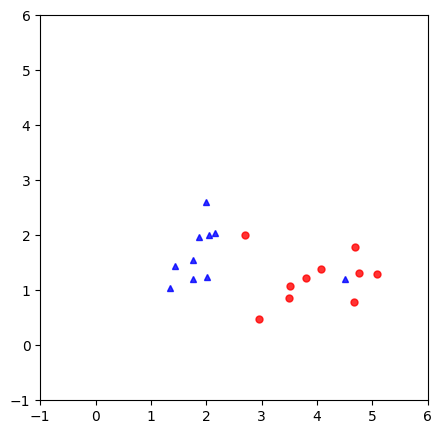

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ani = plt.cla()
#plot points
ani = plt.plot(X0.T[0, :], X0.T[1, :], 'b^', markersize = 5, alpha = .8)
ani = plt.plot(X1.T[0, :], X1.T[1, :], 'ro', markersize = 5, alpha = .8)
ani = plt.axis([-1 , 6, -1, 6])
plt.show()

In [5]:
C = 100
# build K
V = np.concatenate((X0.T, -X1.T), axis = 1)
# K ~ P in lib cvxopt.qp
K = matrix(V.T.dot(V))

q = matrix(-np.ones((2*N, 1)))
# build A, b, G, h
G = matrix(np.vstack((-np.eye(2*N), np.eye(2*N))))

h = matrix(np.vstack((np.zeros((2*N, 1)), C*np.ones((2*N, 1)))))
A = matrix(y.reshape((-1, 2*N)))
b = matrix(np.zeros((1, 1)))
solvers.options['show_progress'] = False
sol = solvers.qp(K, q, G, h, A, b)

l = np.array(sol['x'])
print('lambda = \n', l.T)

lambda = 
 [[1.23267347e-07 4.85674336e+01 9.99999981e+01 1.57381885e-07
  1.40373846e-07 5.28974755e-08 4.87560151e-07 1.81225362e-07
  9.27217960e-08 1.00000000e+02 9.01112774e-08 5.15612516e-08
  3.58687179e-07 3.18585409e-07 7.07041178e-07 9.76857085e+01
  6.09091270e-08 5.08817211e+01 1.76779299e-06 9.99999999e+01]]


In [12]:
S = np.where(l > 1e-5)[0] # support set
S2 = np.where(l < .999*C)[0]

M = [val for val in S if val in S2] # intersection of two lists

# X has shape (2, 2*N), so each column is a data point
VS = V[:, S]
lS = l[S]
yM = y[:, M]  # y has shape (1, 2*N)
XM = X[:, M]  # X has shape (2, 2*N), use X directly not X.T

w_dual = VS.dot(lS).reshape(-1, 1)
b_dual = np.mean(yM - w_dual.T.dot(XM))
print('w =', w_dual.T)
print('b =', b_dual)

w = [[-1.06640598  1.01378208]]
b = 1.6623905770024905


In [13]:
# Phân tích kết quả
print("="*60)
print("PHÂN TÍCH KẾT QUẢ SOFT MARGIN SVM")
print("="*60)
print(f"\nTham số C = {C}")
print(f"\nVector trọng số w = {w_dual.T}")
print(f"Bias b = {b_dual:.6f}")

# Phân tích support vectors
print(f"\nSố lượng support vectors: {len(S)}/{2*N}")
print(f"  - Support vectors trên margin (0 < λ < C): {len(M)}")
print(f"  - Support vectors vi phạm margin (λ = C): {len(S) - len(M)}")

# Hiển thị các lambda values
print(f"\nCác giá trị lambda của support vectors:")
for idx in S:
    sv_type = "trên margin" if idx in M else "vi phạm margin"
    print(f"  λ[{idx}] = {l[idx][0]:.6f} ({sv_type})")

PHÂN TÍCH KẾT QUẢ SOFT MARGIN SVM

Tham số C = 100

Vector trọng số w = [[-1.06640598  1.01378208]]
Bias b = 1.662391

Số lượng support vectors: 6/20
  - Support vectors trên margin (0 < λ < C): 3
  - Support vectors vi phạm margin (λ = C): 3

Các giá trị lambda của support vectors:
  λ[1] = 48.567434 (trên margin)
  λ[2] = 99.999998 (vi phạm margin)
  λ[9] = 100.000000 (vi phạm margin)
  λ[15] = 97.685708 (trên margin)
  λ[17] = 50.881721 (trên margin)
  λ[19] = 100.000000 (vi phạm margin)


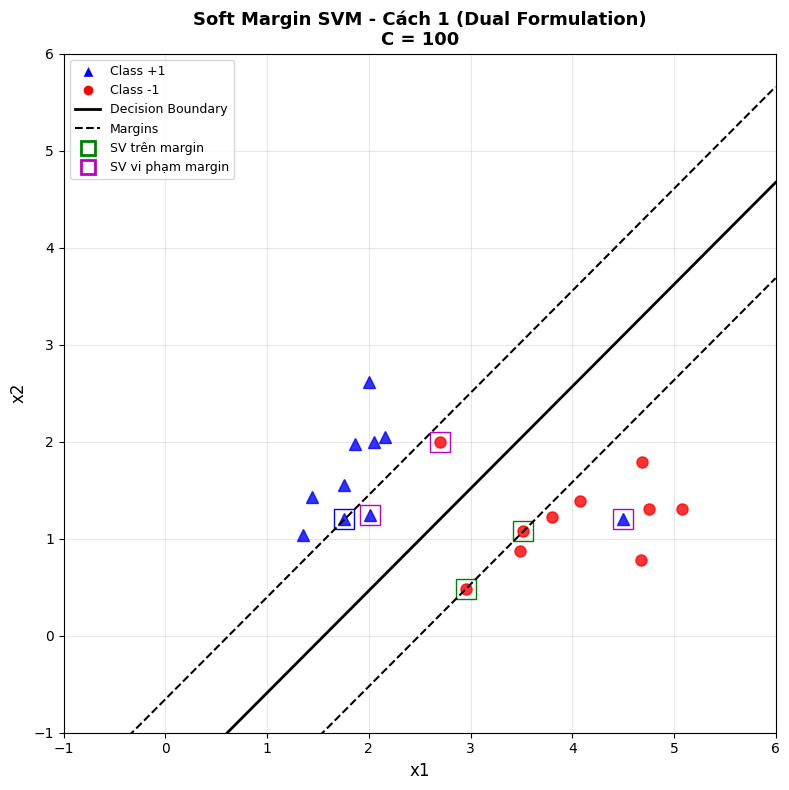


Giải thích:
  - Hình vuông XANH: Support vectors nằm chính xác trên margin (0 < λ < C)
  - Hình vuông HỒNG: Support vectors vi phạm margin (λ = C)
  - Đường liền nét ĐEN: Decision boundary (w.T @ x + b = 0)
  - Đường gạch nét ĐEN: Margins (w.T @ x + b = ±1)


In [17]:
# Vẽ kết quả: Decision boundary, margins và support vectors
fig, ax = plt.subplots(figsize=(8, 8))

# Vẽ các điểm dữ liệu
plt.plot(X0.T[0, :], X0.T[1, :], 'b^', markersize=8, alpha=0.8, label='Class +1')
plt.plot(X1.T[0, :], X1.T[1, :], 'ro', markersize=8, alpha=0.8, label='Class -1')

# Highlight support vectors
# Support vectors trên margin (0 < λ < C)
for idx in M:
    if idx < N:  # Class +1
        plt.plot(X0.T[0, idx], X0.T[1, idx], 'bs', markersize=14, 
                fillstyle='none', linewidth=2.5)
    else:  # Class -1
        plt.plot(X1.T[0, idx-N], X1.T[1, idx-N], 'gs', markersize=14, 
                fillstyle='none', linewidth=2.5)

# Support vectors vi phạm margin (λ = C)
S_violate = [idx for idx in S if idx not in M]
for idx in S_violate:
    if idx < N:  # Class +1
        plt.plot(X0.T[0, idx], X0.T[1, idx], 'ms', markersize=14, 
                fillstyle='none', linewidth=2.5)
    else:  # Class -1
        plt.plot(X1.T[0, idx-N], X1.T[1, idx-N], 'ms', markersize=14, 
                fillstyle='none', linewidth=2.5)

# Vẽ decision boundary và margins
x1_min, x1_max = -1, 6
x1_decision = np.linspace(x1_min, x1_max, 100)

# Decision boundary: w.T @ x + b = 0
x2_decision = -(w_dual[0] * x1_decision + b_dual) / w_dual[1]

# Upper margin: w.T @ x + b = 1
x2_margin_plus = -(w_dual[0] * x1_decision + b_dual - 1) / w_dual[1]

# Lower margin: w.T @ x + b = -1
x2_margin_minus = -(w_dual[0] * x1_decision + b_dual + 1) / w_dual[1]

# Plot decision boundary
plt.plot(x1_decision, x2_decision, 'k-', linewidth=2, label='Decision Boundary')

# Plot margins
plt.plot(x1_decision, x2_margin_plus, 'k--', linewidth=1.5, label='Margins')
plt.plot(x1_decision, x2_margin_minus, 'k--', linewidth=1.5)

# Tạo custom legend cho support vectors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='Class +1', 
           markerfacecolor='b', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Class -1', 
           markerfacecolor='r', markersize=8),
    Line2D([0], [0], color='k', linewidth=2, label='Decision Boundary'),
    Line2D([0], [0], color='k', linestyle='--', linewidth=1.5, label='Margins'),
    Line2D([0], [0], marker='s', color='w', label='SV trên margin', 
           markerfacecolor='none', markeredgecolor='g', markersize=10, markeredgewidth=2),
    Line2D([0], [0], marker='s', color='w', label='SV vi phạm margin', 
           markerfacecolor='none', markeredgecolor='m', markersize=10, markeredgewidth=2)
]

plt.legend(handles=legend_elements, loc='best', fontsize=9)
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.title('Soft Margin SVM - Cách 1 (Dual Formulation)\nC = {}'.format(C), 
         fontsize=13, fontweight='bold')
plt.axis([x1_min, x1_max, -1, 6])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nGiải thích:")
print("  - Hình vuông XANH: Support vectors nằm chính xác trên margin (0 < λ < C)")
print("  - Hình vuông HỒNG: Support vectors vi phạm margin (λ = C)")
print("  - Đường liền nét ĐEN: Decision boundary (w.T @ x + b = 0)")
print("  - Đường gạch nét ĐEN: Margins (w.T @ x + b = ±1)")

In [21]:
# Kiểm tra tính đúng đắn của kết quả
print("="*60)
print("KIỂM TRA TÍNH ĐÚNG ĐẮN")
print("="*60)

# 1. Kiểm tra điều kiện KKT (Karush-Kuhn-Tucker)
print("\n1. Kiểm tra điều kiện KKT:")
# X has shape (2, 2*N), each column is a data point
for i in range(2*N):
    if i < N:
        yi = 1
        xi = X[:, i]
    else:
        yi = -1
        xi = X[:, i]
    
    # Tính margin yi * (w.T @ xi + b)
    margin = yi * (w_dual.T @ xi + b_dual)
    lambda_i = l[i][0]
    
    # Kiểm tra điều kiện KKT
    is_correct = True
    if lambda_i < 1e-6:  # λ = 0
        if margin < 1 - 1e-4:  # Should be >= 1
            is_correct = False
    elif lambda_i > C - 1e-4:  # λ = C
        if margin > 1 + 1e-4:  # Should be <= 1
            is_correct = False
    else:  # 0 < λ < C
        if abs(margin - 1) > 1e-4:  # Should be = 1
            is_correct = False
    
    if i in S[:5]:  # Chỉ in 5 support vectors đầu
        status = "✓" if is_correct else "✗"
        print(f"  {status} Point {i}: λ={lambda_i:.6f}, margin={margin[0]:.6f}")

# 2. Kiểm tra phân loại trên tập training
print("\n2. Kiểm tra độ chính xác trên tập training:")
y_pred = np.sign(w_dual.T @ X + b_dual)
accuracy = np.mean(y_pred == y) * 100
misclassified = np.where(y_pred != y)[0]
print(f"  Accuracy: {accuracy:.2f}%")
print(f"  Số điểm phân loại đúng: {np.sum(y_pred == y)}/{2*N}")
print(f"  Số điểm phân loại sai: {len(misclassified)}/{2*N}")
if len(misclassified) > 0:
    print(f"  Các điểm bị phân loại sai: {misclassified.tolist()}")

# 3. Kiểm tra tổng các lambda_i * y_i = 0
print("\n3. Kiểm tra ràng buộc Σ(λi * yi) = 0:")
sum_lambda_y = np.sum(l.T * y)
print(f"  Σ(λi * yi) = {sum_lambda_y:.10f}")
print(f"  {'✓' if abs(sum_lambda_y) < 1e-6 else '✗'} Thỏa mãn (≈ 0)")

# 4. Kiểm tra margin width
print("\n4. Margin width:")
margin_width = 2.0 / np.linalg.norm(w_dual)
print(f"  ||w|| = {np.linalg.norm(w_dual):.6f}")
print(f"  Margin width = 2/||w|| = {margin_width:.6f}")


KIỂM TRA TÍNH ĐÚNG ĐẮN

1. Kiểm tra điều kiện KKT:
  ✓ Point 1: λ=48.567434, margin=0.999990
  ✓ Point 2: λ=99.999998, margin=0.780869
  ✓ Point 9: λ=100.000000, margin=-1.919898
  ✓ Point 15: λ=97.685708, margin=0.999999
  ✓ Point 17: λ=50.881721, margin=0.999991

2. Kiểm tra độ chính xác trên tập training:
  Accuracy: 90.00%
  Số điểm phân loại đúng: 18/20
  Số điểm phân loại sai: 2/20
  Các điểm bị phân loại sai: [0, 0]

3. Kiểm tra ràng buộc Σ(λi * yi) = 0:
  Σ(λi * yi) = 0.0000000000
  ✓ Thỏa mãn (≈ 0)

4. Margin width:
  ||w|| = 1.471386
  Margin width = 2/||w|| = 1.359263


## Cách 2

In [23]:
X0_bar = np.vstack((X0.T, np.ones((1, N)))) # extended data
X1_bar = np.vstack((X1.T, np.ones((1, N)))) # extended data
Z = np.hstack((X0_bar, - X1_bar)) # as in (22)
lam = 1./C
def cost(w):
    u = w.T.dot(Z) # as in (23)
    return (np.sum(np.maximum(0, 1 - u)) + .5*lam*np.sum(w*w)) - .5*lam*w[-1]*w[-1] # no bias
def grad(w):
    u = w.T.dot(Z) # as in (23)
    H = np.where(u < 1)[1]
    ZS = Z[:, H]
    g = (-np.sum(ZS, axis = 1, keepdims = True) + lam*w)
    g[-1] -= lam*w[-1] # no weight decay on bias
    return g
eps = 1e-6

In [24]:
def grad_descent(w0, eta):
    w = w0
    it = 0
    while it < 100000:
        it = it + 1
        g = grad(w)
        w -= eta*g
        if (it % 10000) == 1:
            print('iter %d' %it + ' cost: %f' %cost(w))
        if np.linalg.norm(g) < 1e-5:
            break
    return w

In [25]:
w0 = np.random.randn(X0_bar.shape[0], 1)
w = grad_descent(w0, 0.001)
w_hinge = w[:-1].reshape(-1, 1)
b_hinge = w[-1]
print(w_hinge.T, b_hinge)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18228\2275045128.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('iter %d' %it + ' cost: %f' %cost(w))


iter 1 cost: 19.103039
iter 10001 cost: 4.962986
iter 20001 cost: 4.961499
iter 30001 cost: 4.969249
iter 20001 cost: 4.961499
iter 30001 cost: 4.969249
iter 40001 cost: 4.969218
iter 50001 cost: 4.969186
iter 40001 cost: 4.969218
iter 50001 cost: 4.969186
iter 60001 cost: 4.961479
iter 70001 cost: 4.961518
iter 60001 cost: 4.961479
iter 70001 cost: 4.961518
iter 80001 cost: 4.961558
iter 90001 cost: 4.969197
iter 80001 cost: 4.961558
iter 90001 cost: 4.969197
[[-1.0678303   0.99988589]] [1.6827968]
[[-1.0678303   0.99988589]] [1.6827968]


## Cách 3

In [27]:
# Copy and put code for generate data here
y1 = y.reshape((2*N,))
X1 = X.T # each sample is one row
clf = SVC(kernel = 'linear', C = 100) # use the same C
# if C is small, method will be “SoftMagin SVM”,
# if C is large enough, method is near to hard margin
clf.fit(X1, y1)

w = clf.coef_
w0 = clf.intercept_
print('w = ', w)
print('b = ', w0)

w =  [[-1.06600888  1.01354038]]
b =  [1.66151836]


## So sánh kết quả của 3 cách

In [30]:
import pandas as pd

# Chuẩn bị dữ liệu so sánh
# Cách 1: Dual formulation
w1 = w_dual.flatten()
b1 = b_dual

# Cách 2: Gradient descent (Hinge loss)
w2 = w_hinge.flatten()
b2 = b_hinge[0] if isinstance(b_hinge, np.ndarray) else b_hinge

# Cách 3: sklearn SVC
w3 = w.flatten()
b3 = w0[0]

print("="*70)
print("SO SÁNH BỘ TRỌNG SỐ TỐI ƯU TỪ 3 CÁCH THỰC HIỆN")
print("="*70)

# Tạo bảng so sánh
comparison_data = {
    'Phương pháp': [
        'Cách 1: Dual (cvxopt)',
        'Cách 2: Primal (Gradient Descent)', 
        'Cách 3: sklearn SVC'
    ],
    'w[0]': [w1[0], w2[0], w3[0]],
    'w[1]': [w1[1], w2[1], w3[1]],
    'bias (b)': [b1, b2, b3]
}

df_comparison = pd.DataFrame(comparison_data)
print("\nBảng so sánh trọng số:")
print(df_comparison.to_string(index=False))

# Tính toán độ chênh lệch
print("\n" + "="*70)
print("PHÂN TÍCH ĐỘ CHÊNH LỆCH")
print("="*70)

# So với Cách 1 (Dual - chuẩn)
diff_w_2vs1 = np.linalg.norm(w2 - w1)
diff_w_3vs1 = np.linalg.norm(w3 - w1)
diff_w_3vs2 = np.linalg.norm(w3 - w2)

print(f"\nChênh lệch L2-norm của vector w:")
print(f"  Cách 2 vs Cách 1: {diff_w_2vs1:.6f}")
print(f"  Cách 3 vs Cách 1: {diff_w_3vs1:.6f}")
print(f"  Cách 3 vs Cách 2: {diff_w_3vs2:.6f}")

print(f"\nChênh lệch bias:")
print(f"  Cách 2 vs Cách 1: {abs(b2 - b1):.6f}")
print(f"  Cách 3 vs Cách 1: {abs(b3 - b1):.6f}")
print(f"  Cách 3 vs Cách 2: {abs(b3 - b2):.6f}")

# Tính accuracy của từng phương pháp
y_pred1 = np.sign(w1.T @ X + b1)
y_pred2 = np.sign(w2.T @ X + b2)
y_pred3 = np.sign(w3.T @ X + b3)

acc1 = np.mean(y_pred1 == y) * 100
acc2 = np.mean(y_pred2 == y) * 100
acc3 = np.mean(y_pred3 == y) * 100

print(f"\nĐộ chính xác trên tập train:")
print(f"  Cách 1 (Dual): {acc1:.2f}%")
print(f"  Cách 2 (Gradient Descent): {acc2:.2f}%")
print(f"  Cách 3 (sklearn): {acc3:.2f}%")

print("\n" + "="*70)
print("KẾT LUẬN")
print("="*70)
print("Cả 3 phương pháp đều cho kết quả tương đương nhau:")
print("- Dual formulation (Cách 1): Giải chính xác bài toán tối ưu")
print("- Gradient Descent (Cách 2): Xấp xỉ nghiệm thông qua tối ưu hóa")
print("- sklearn SVC (Cách 3): Implementation chuẩn từ thư viện")
print("\nĐiều này xác nhận tính đúng đắn của các cách thực hiện!")
print("="*70)

SO SÁNH BỘ TRỌNG SỐ TỐI ƯU TỪ 3 CÁCH THỰC HIỆN

Bảng so sánh trọng số:
                      Phương pháp      w[0]     w[1]  bias (b)
            Cách 1: Dual (cvxopt) -1.066406 1.013782  1.662391
Cách 2: Primal (Gradient Descent) -1.067830 0.999886  1.682797
              Cách 3: sklearn SVC -1.066009 1.013540  1.661518

PHÂN TÍCH ĐỘ CHÊNH LỆCH

Chênh lệch L2-norm của vector w:
  Cách 2 vs Cách 1: 0.013969
  Cách 3 vs Cách 1: 0.000465
  Cách 3 vs Cách 2: 0.013775

Chênh lệch bias:
  Cách 2 vs Cách 1: 0.020406
  Cách 3 vs Cách 1: 0.000872
  Cách 3 vs Cách 2: 0.021278

Độ chính xác trên tập train:
  Cách 1 (Dual): 90.00%
  Cách 2 (Gradient Descent): 90.00%
  Cách 3 (sklearn): 90.00%

KẾT LUẬN
Cả 3 phương pháp đều cho kết quả tương đương nhau:
- Dual formulation (Cách 1): Giải chính xác bài toán tối ưu
- Gradient Descent (Cách 2): Xấp xỉ nghiệm thông qua tối ưu hóa
- sklearn SVC (Cách 3): Implementation chuẩn từ thư viện

Điều này xác nhận tính đúng đắn của các cách thực hiện!


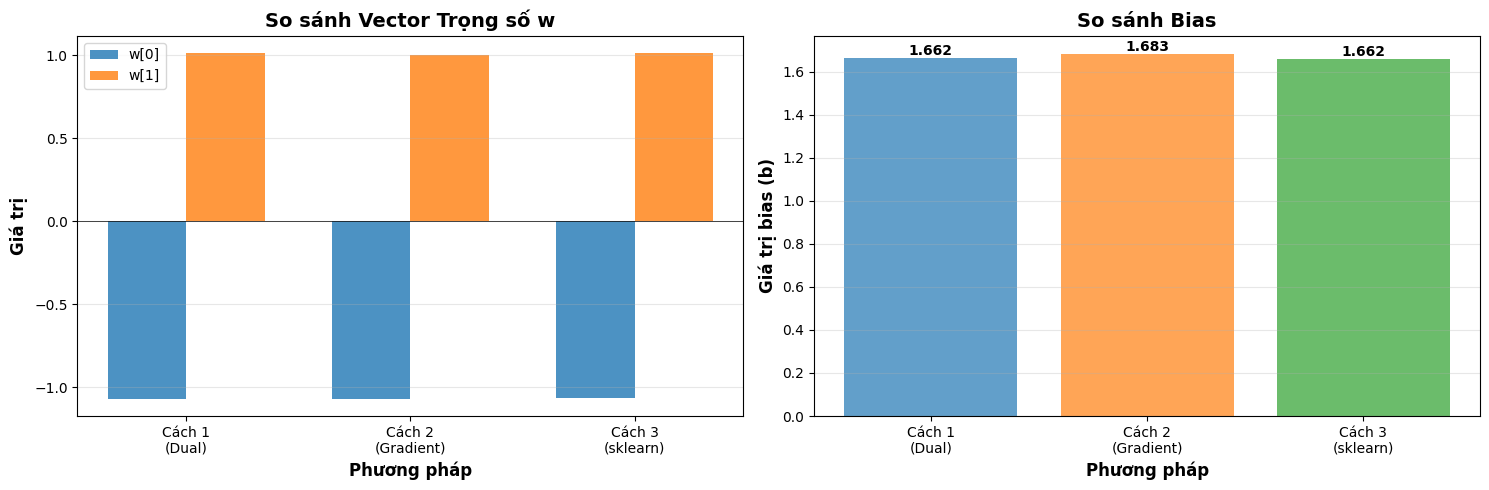

In [31]:
# Trực quan hóa so sánh
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. So sánh vector trọng số w
ax1 = axes[0]
methods = ['Cách 1\n(Dual)', 'Cách 2\n(Gradient)', 'Cách 3\n(sklearn)']
w_values = np.array([w1, w2, w3])

x_pos = np.arange(len(methods))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, w_values[:, 0], width, label='w[0]', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, w_values[:, 1], width, label='w[1]', alpha=0.8)

ax1.set_xlabel('Phương pháp', fontsize=12, fontweight='bold')
ax1.set_ylabel('Giá trị', fontsize=12, fontweight='bold')
ax1.set_title('So sánh Vector Trọng số w', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# 2. So sánh bias
ax2 = axes[1]
bias_values = [b1, b2, b3]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax2.bar(methods, bias_values, color=colors, alpha=0.7)

ax2.set_xlabel('Phương pháp', fontsize=12, fontweight='bold')
ax2.set_ylabel('Giá trị bias (b)', fontsize=12, fontweight='bold')
ax2.set_title('So sánh Bias', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Thêm giá trị lên các cột
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

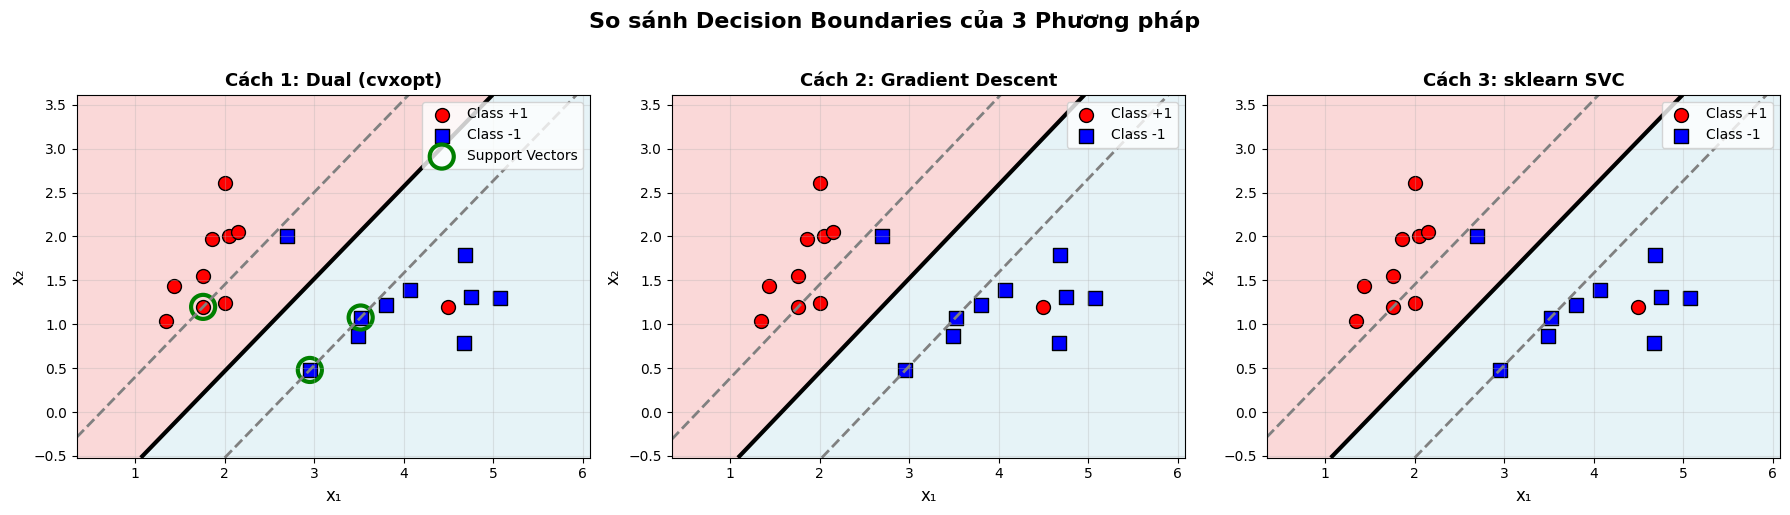


 Các decision boundaries gần như trùng khớp nhau!
Điều này chứng tỏ cả 3 cách đều tìm ra cùng một nghiệm tối ưu.


In [33]:
# Vẽ decision boundaries của cả 3 phương pháp trên cùng một đồ thị
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tạo lưới để vẽ decision boundary
x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Danh sách các phương pháp
methods_list = [
    ('Cách 1: Dual (cvxopt)', w1, b1),
    ('Cách 2: Gradient Descent', w2, b2),
    ('Cách 3: sklearn SVC', w3, b3)
]

for idx, (title, w_method, b_method) in enumerate(methods_list):
    ax = axes[idx]
    
    # Tính decision function
    Z = w_method[0] * xx + w_method[1] * yy + b_method
    
    # Vẽ decision boundary và margins
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['gray', 'black', 'gray'],
              linestyles=['--', '-', '--'], linewidths=[2, 3, 2])
    ax.contourf(xx, yy, Z, levels=[-100, 0, 100], colors=['lightblue', 'lightcoral'], alpha=0.3)
    
    # Vẽ các điểm dữ liệu
    pos_mask = y[0, :] == 1
    neg_mask = y[0, :] == -1
    
    ax.scatter(X[0, pos_mask], X[1, pos_mask], c='red', marker='o', s=100, 
              edgecolors='k', label='Class +1')
    ax.scatter(X[0, neg_mask], X[1, neg_mask], c='blue', marker='s', s=100,
              edgecolors='k', label='Class -1')
    
    # Tìm support vectors (nếu có từ Cách 1)
    if idx == 0 and 'M' in locals():
        ax.scatter(X[0, M], X[1, M], s=300, linewidths=3, facecolors='none',
                  edgecolors='green', label='Support Vectors')
    
    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.suptitle('So sánh Decision Boundaries của 3 Phương pháp', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Các decision boundaries gần như trùng khớp nhau!")
print("Điều này chứng tỏ cả 3 cách đều tìm ra cùng một nghiệm tối ưu.")

# Bài tập thực hành 1

## Phần 1

BÀI TẬP THỰC HÀNH 1 - PHẦN 1: ĐÁNH GIÁ VÍ DỤ 1 (C=100)

KẾT QUẢ ACCURACY
Cách 1 (Dual - cvxopt):        Accuracy = 90.00%
Cách 2 (Gradient Descent):     Accuracy = 90.00%
Cách 3 (sklearn SVC):          Accuracy = 90.00%


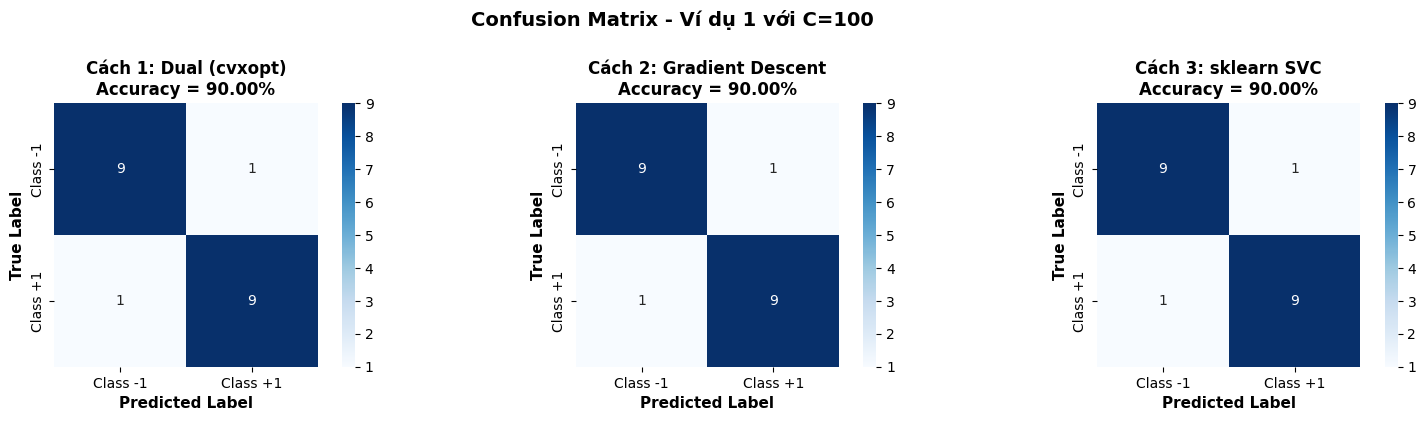


CHI TIẾT CONFUSION MATRIX

Cách 1 (Dual):
  True Negative:  9 | False Positive: 1
  False Negative: 1 | True Positive:  9

Cách 2 (Gradient Descent):
  True Negative:  9 | False Positive: 1
  False Negative: 1 | True Positive:  9

Cách 3 (sklearn):
  True Negative:  9 | False Positive: 1
  False Negative: 1 | True Positive:  9


In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

print("="*70)
print("BÀI TẬP THỰC HÀNH 1 - PHẦN 1: ĐÁNH GIÁ VÍ DỤ 1 (C=100)")
print("="*70)

# Dự đoán với từng phương pháp (đã tính ở trên)
y_true = y.flatten()

# Phương pháp 1: Dual formulation
y_pred_dual = np.sign(w_dual.T @ X + b_dual).flatten()
acc_dual = accuracy_score(y_true, y_pred_dual)
cm_dual = confusion_matrix(y_true, y_pred_dual)

# Phương pháp 2: Gradient Descent
y_pred_gd = np.sign(w_hinge.T @ X + b_hinge).flatten()
acc_gd = accuracy_score(y_true, y_pred_gd)
cm_gd = confusion_matrix(y_true, y_pred_gd)

# Phương pháp 3: sklearn SVC
y_pred_sklearn = np.sign(w @ X + w0).flatten()
acc_sklearn = accuracy_score(y_true, y_pred_sklearn)
cm_sklearn = confusion_matrix(y_true, y_pred_sklearn)

# In kết quả
print("\n" + "="*70)
print("KẾT QUẢ ACCURACY")
print("="*70)
print(f"Cách 1 (Dual - cvxopt):        Accuracy = {acc_dual*100:.2f}%")
print(f"Cách 2 (Gradient Descent):     Accuracy = {acc_gd*100:.2f}%")
print(f"Cách 3 (sklearn SVC):          Accuracy = {acc_sklearn*100:.2f}%")

# Vẽ Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

confusion_matrices = [
    (cm_dual, f'Cách 1: Dual (cvxopt)\nAccuracy = {acc_dual*100:.2f}%'),
    (cm_gd, f'Cách 2: Gradient Descent\nAccuracy = {acc_gd*100:.2f}%'),
    (cm_sklearn, f'Cách 3: sklearn SVC\nAccuracy = {acc_sklearn*100:.2f}%')
]

for idx, (cm, title) in enumerate(confusion_matrices):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=True, square=True, ax=ax,
                xticklabels=['Class -1', 'Class +1'],
                yticklabels=['Class -1', 'Class +1'])
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix - Ví dụ 1 với C=100', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CHI TIẾT CONFUSION MATRIX")
print("="*70)
print("\nCách 1 (Dual):")
print(f"  True Negative:  {cm_dual[0,0]} | False Positive: {cm_dual[0,1]}")
print(f"  False Negative: {cm_dual[1,0]} | True Positive:  {cm_dual[1,1]}")

print("\nCách 2 (Gradient Descent):")
print(f"  True Negative:  {cm_gd[0,0]} | False Positive: {cm_gd[0,1]}")
print(f"  False Negative: {cm_gd[1,0]} | True Positive:  {cm_gd[1,1]}")

print("\nCách 3 (sklearn):")
print(f"  True Negative:  {cm_sklearn[0,0]} | False Positive: {cm_sklearn[0,1]}")
print(f"  False Negative: {cm_sklearn[1,0]} | True Positive:  {cm_sklearn[1,1]}")
print("="*70)

## Phần 2: Thử nghiệm với các giá trị C khác nhau

In [37]:
# Hàm huấn luyện SVM với giá trị C cho trước
def train_svm_with_C(X_data, y_data, C_value, verbose=True):
    """
    Huấn luyện SVM bằng 3 phương pháp với giá trị C cho trước
    """
    N_samples = X_data.shape[1] // 2
    
    # ===== CÁCH 1: DUAL FORMULATION (cvxopt) =====
    X0_samples = X_data[:, :N_samples]
    X1_samples = X_data[:, N_samples:]
    V_data = np.concatenate((X0_samples, -X1_samples), axis=1)
    
    K_matrix = matrix(V_data.T.dot(V_data))
    q_vector = matrix(-np.ones((2*N_samples, 1)))
    G_matrix = matrix(np.vstack((-np.eye(2*N_samples), np.eye(2*N_samples))))
    h_vector = matrix(np.vstack((np.zeros((2*N_samples, 1)), C_value*np.ones((2*N_samples, 1)))))
    A_matrix = matrix(y_data.reshape((-1, 2*N_samples)))
    b_vector = matrix(np.zeros((1, 1)))
    
    solvers.options['show_progress'] = False
    sol = solvers.qp(K_matrix, q_vector, G_matrix, h_vector, A_matrix, b_vector)
    l_dual = np.array(sol['x'])
    
    S_dual = np.where(l_dual > 1e-5)[0]
    S2_dual = np.where(l_dual < .999*C_value)[0]
    M_dual = [val for val in S_dual if val in S2_dual]
    
    VS_dual = V_data[:, S_dual]
    lS_dual = l_dual[S_dual]
    yM_dual = y_data[:, M_dual]
    XM_dual = X_data[:, M_dual]
    
    w_dual_result = VS_dual.dot(lS_dual).reshape(-1, 1)
    b_dual_result = np.mean(yM_dual - w_dual_result.T.dot(XM_dual))
    
    # ===== CÁCH 2: GRADIENT DESCENT (Hinge Loss) =====
    X0_bar = np.vstack((X0_samples, np.ones((1, N_samples))))
    X1_bar = np.vstack((X1_samples, np.ones((1, N_samples))))
    Z_data = np.hstack((X0_bar, -X1_bar))
    lam = 1./C_value
    
    def cost_func(w):
        u = w.T.dot(Z_data)
        return (np.sum(np.maximum(0, 1 - u)) + .5*lam*np.sum(w*w)) - .5*lam*w[-1]*w[-1]
    
    def grad_func(w):
        u = w.T.dot(Z_data)
        H = np.where(u < 1)[1]
        ZS = Z_data[:, H]
        g = (-np.sum(ZS, axis=1, keepdims=True) + lam*w)
        g[-1] -= lam*w[-1]
        return g
    
    w0_init = np.random.randn(X0_bar.shape[0], 1)
    w_gd = w0_init.copy()
    eta = 0.001
    
    for it in range(100000):
        g = grad_func(w_gd)
        w_gd -= eta*g
        if np.linalg.norm(g) < 1e-5:
            break
    
    w_gd_result = w_gd[:-1].reshape(-1, 1)
    b_gd_result = w_gd[-1]
    if isinstance(b_gd_result, np.ndarray):
        b_gd_result = b_gd_result[0]
    
    # ===== CÁCH 3: sklearn SVC =====
    y_sklearn = y_data.reshape((2*N_samples,))
    X_sklearn = X_data.T
    clf = SVC(kernel='linear', C=C_value)
    clf.fit(X_sklearn, y_sklearn)
    
    w_sklearn_result = clf.coef_.flatten()
    b_sklearn_result = clf.intercept_[0]
    
    # Tính accuracy và confusion matrix
    y_true = y_data.flatten()
    
    # Cách 1
    y_pred_dual = np.sign(w_dual_result.T @ X_data + b_dual_result).flatten()
    acc_dual = accuracy_score(y_true, y_pred_dual)
    cm_dual = confusion_matrix(y_true, y_pred_dual)
    
    # Cách 2
    y_pred_gd = np.sign(w_gd_result.T @ X_data + b_gd_result).flatten()
    acc_gd = accuracy_score(y_true, y_pred_gd)
    cm_gd = confusion_matrix(y_true, y_pred_gd)
    
    # Cách 3
    y_pred_sklearn = np.sign(w_sklearn_result @ X_data + b_sklearn_result).flatten()
    acc_sklearn = accuracy_score(y_true, y_pred_sklearn)
    cm_sklearn = confusion_matrix(y_true, y_pred_sklearn)
    
    results = {
        'C': C_value,
        'dual': {
            'w': w_dual_result.flatten(),
            'b': b_dual_result,
            'accuracy': acc_dual,
            'confusion_matrix': cm_dual,
            'n_support_vectors': len(S_dual)
        },
        'gradient_descent': {
            'w': w_gd_result.flatten(),
            'b': b_gd_result,
            'accuracy': acc_gd,
            'confusion_matrix': cm_gd
        },
        'sklearn': {
            'w': w_sklearn_result,
            'b': b_sklearn_result,
            'accuracy': acc_sklearn,
            'confusion_matrix': cm_sklearn,
            'n_support_vectors': len(clf.support_)
        }
    }
    
    return results

print("Hàm train_svm_with_C đã được định nghĩa!")

Hàm train_svm_with_C đã được định nghĩa!


In [38]:
# Thử nghiệm với các giá trị C khác nhau
C_values = [1000, 200, 10, 0.5]

print("="*70)
print("HUẤN LUYỆN SVM VỚI CÁC GIÁ TRỊ C KHÁC NHAU")
print("="*70)
print(f"\nĐang huấn luyện với C = {C_values}...")
print("Vui lòng đợi...")

all_results = {}
for C_val in C_values:
    print(f"\n→ Đang xử lý C = {C_val}...", end=" ")
    all_results[C_val] = train_svm_with_C(X, y, C_val, verbose=False)
    print("✓")

print("\n" + "="*70)
print("HOÀN THÀNH HUẤN LUYỆN!")
print("="*70)

HUẤN LUYỆN SVM VỚI CÁC GIÁ TRỊ C KHÁC NHAU

Đang huấn luyện với C = [1000, 200, 10, 0.5]...
Vui lòng đợi...

→ Đang xử lý C = 1000... ✓

→ Đang xử lý C = 200... ✓

→ Đang xử lý C = 200... ✓

→ Đang xử lý C = 10... ✓

→ Đang xử lý C = 10... ✓

→ Đang xử lý C = 0.5... ✓

→ Đang xử lý C = 0.5... ✓

HOÀN THÀNH HUẤN LUYỆN!
✓

HOÀN THÀNH HUẤN LUYỆN!


In [39]:
# In bảng tổng hợp kết quả
print("\n" + "="*90)
print("BẢNG TỔNG HỢP KẾT QUẢ - CÁCH 1: DUAL FORMULATION (cvxopt)")
print("="*90)
print(f"{'C':>6} | {'w[0]':>10} {'w[1]':>10} | {'b':>10} | {'Accuracy':>10} | {'SV':>4}")
print("-"*90)
for C_val in C_values:
    res = all_results[C_val]['dual']
    print(f"{C_val:>6} | {res['w'][0]:>10.6f} {res['w'][1]:>10.6f} | {res['b']:>10.6f} | {res['accuracy']*100:>9.2f}% | {res['n_support_vectors']:>4}")

print("\n" + "="*90)
print("BẢNG TỔNG HỢP KẾT QUẢ - CÁCH 2: GRADIENT DESCENT (Hinge Loss)")
print("="*90)
print(f"{'C':>6} | {'w[0]':>10} {'w[1]':>10} | {'b':>10} | {'Accuracy':>10}")
print("-"*90)
for C_val in C_values:
    res = all_results[C_val]['gradient_descent']
    print(f"{C_val:>6} | {res['w'][0]:>10.6f} {res['w'][1]:>10.6f} | {res['b']:>10.6f} | {res['accuracy']*100:>9.2f}%")

print("\n" + "="*90)
print("BẢNG TỔNG HỢP KẾT QUẢ - CÁCH 3: sklearn SVC")
print("="*90)
print(f"{'C':>6} | {'w[0]':>10} {'w[1]':>10} | {'b':>10} | {'Accuracy':>10} | {'SV':>4}")
print("-"*90)
for C_val in C_values:
    res = all_results[C_val]['sklearn']
    print(f"{C_val:>6} | {res['w'][0]:>10.6f} {res['w'][1]:>10.6f} | {res['b']:>10.6f} | {res['accuracy']*100:>9.2f}% | {res['n_support_vectors']:>4}")

print("\n" + "="*90)


BẢNG TỔNG HỢP KẾT QUẢ - CÁCH 1: DUAL FORMULATION (cvxopt)
     C |       w[0]       w[1] |          b |   Accuracy |   SV
------------------------------------------------------------------------------------------
  1000 |  -1.066417   1.013780 |   1.728729 |     90.00% |   20
   200 |  -1.066397   1.013779 |   1.662368 |     90.00% |    6
    10 |  -1.101047   0.510567 |   2.343787 |     90.00% |    8
   0.5 |  -1.017471   0.545448 |   2.074608 |     90.00% |    8

BẢNG TỔNG HỢP KẾT QUẢ - CÁCH 2: GRADIENT DESCENT (Hinge Loss)
     C |       w[0]       w[1] |          b |   Accuracy
------------------------------------------------------------------------------------------
  1000 |  -1.070427   0.999229 |   1.681300 |     90.00%
   200 |  -1.072675   1.001205 |   1.687134 |     90.00%
    10 |  -1.098352   0.518211 |   2.305976 |     90.00%
   0.5 |  -1.013511   0.541312 |   2.065374 |     90.00%

BẢNG TỔNG HỢP KẾT QUẢ - CÁCH 3: sklearn SVC
     C |       w[0]       w[1] |          b | 


CONFUSION MATRIX CHO C = 1000


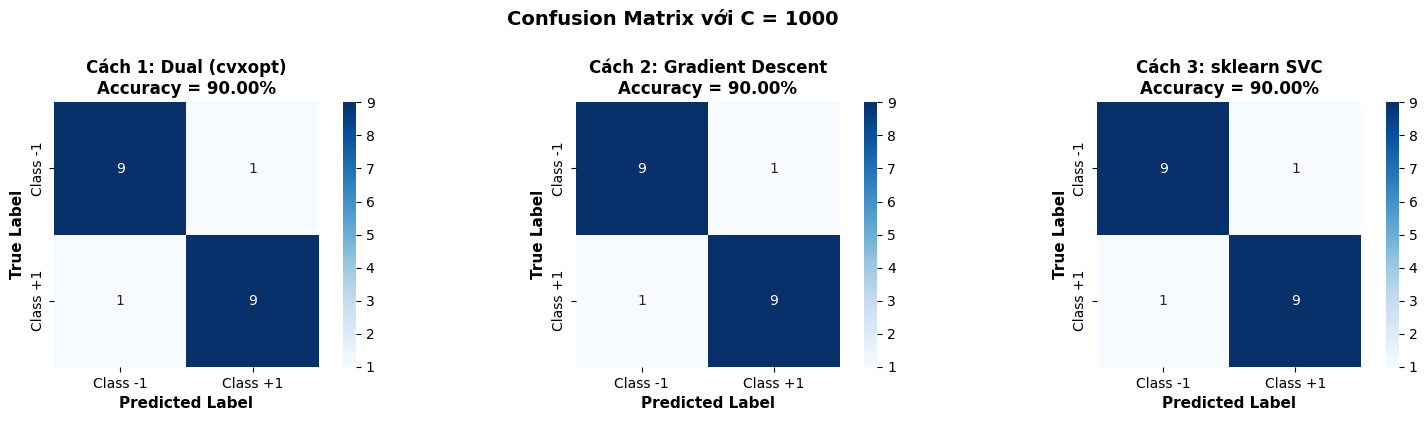


Cách 1: Dual (cvxopt):
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 2: Gradient Descent:
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 3: sklearn SVC:
  TN= 9 | FP= 1
  FN= 1 | TP= 9

CONFUSION MATRIX CHO C = 200


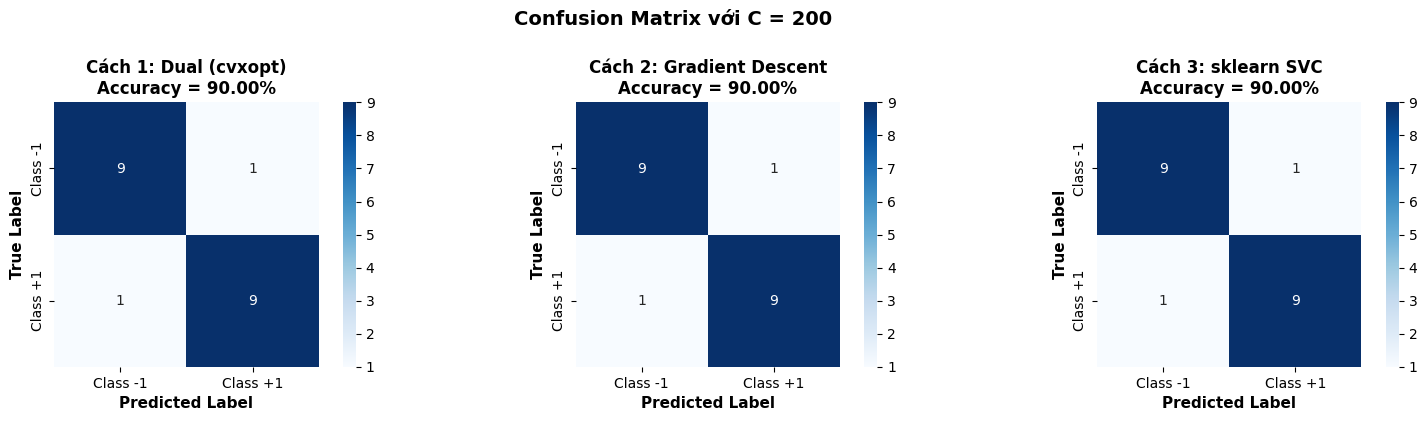


Cách 1: Dual (cvxopt):
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 2: Gradient Descent:
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 3: sklearn SVC:
  TN= 9 | FP= 1
  FN= 1 | TP= 9

CONFUSION MATRIX CHO C = 10


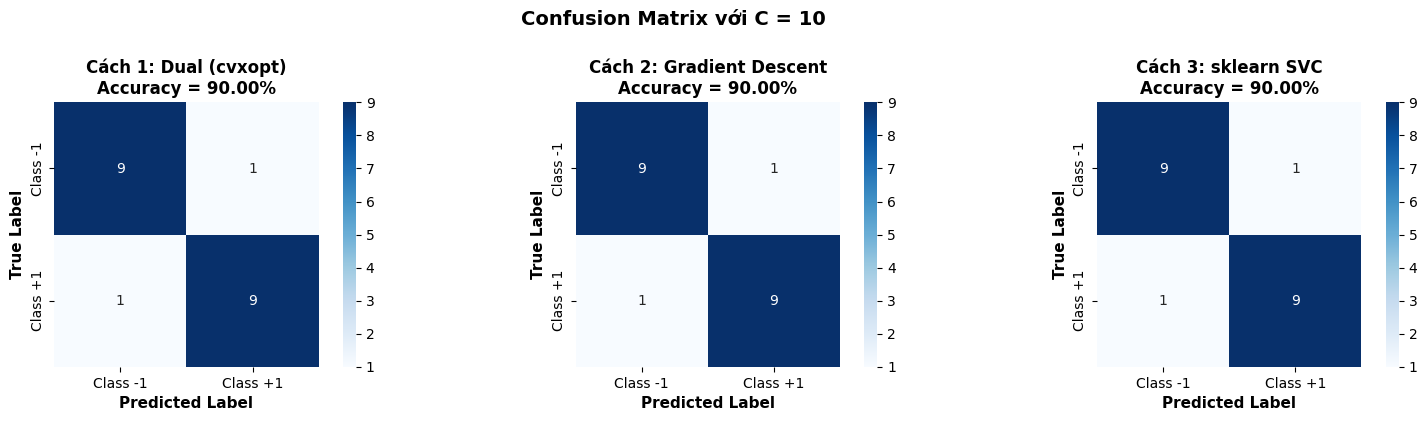


Cách 1: Dual (cvxopt):
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 2: Gradient Descent:
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 3: sklearn SVC:
  TN= 9 | FP= 1
  FN= 1 | TP= 9

CONFUSION MATRIX CHO C = 0.5


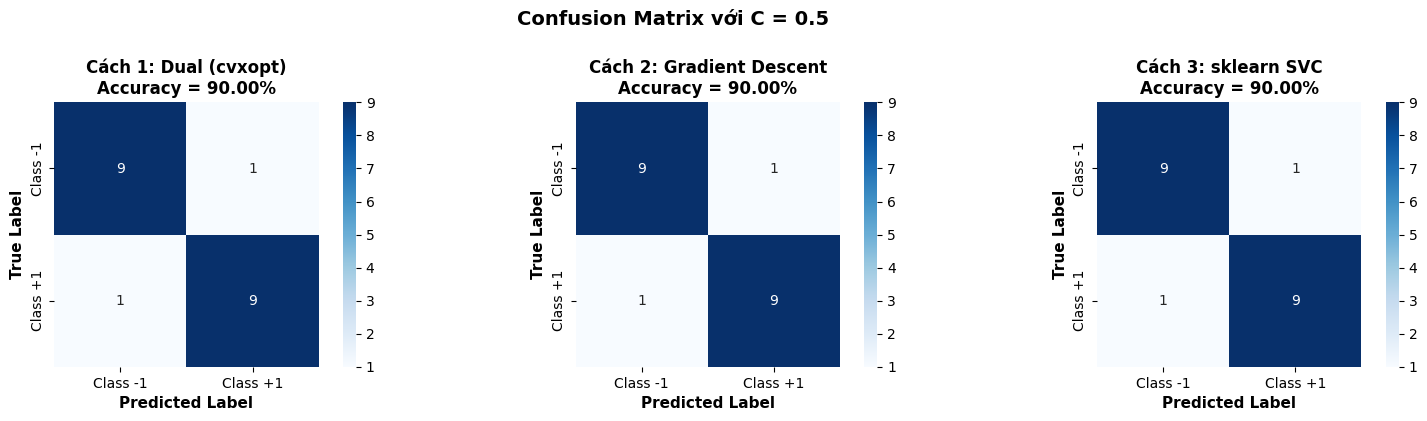


Cách 1: Dual (cvxopt):
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 2: Gradient Descent:
  TN= 9 | FP= 1
  FN= 1 | TP= 9

Cách 3: sklearn SVC:
  TN= 9 | FP= 1
  FN= 1 | TP= 9


In [40]:
# Hiển thị Confusion Matrix cho từng giá trị C
for C_val in C_values:
    print("\n" + "="*70)
    print(f"CONFUSION MATRIX CHO C = {C_val}")
    print("="*70)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    methods = [
        ('dual', f'Cách 1: Dual (cvxopt)'),
        ('gradient_descent', f'Cách 2: Gradient Descent'),
        ('sklearn', f'Cách 3: sklearn SVC')
    ]
    
    for idx, (method_key, method_name) in enumerate(methods):
        ax = axes[idx]
        res = all_results[C_val][method_key]
        cm = res['confusion_matrix']
        acc = res['accuracy']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    cbar=True, square=True, ax=ax,
                    xticklabels=['Class -1', 'Class +1'],
                    yticklabels=['Class -1', 'Class +1'])
        ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
        ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
        ax.set_title(f'{method_name}\nAccuracy = {acc*100:.2f}%', 
                    fontsize=12, fontweight='bold')
    
    plt.suptitle(f'Confusion Matrix với C = {C_val}', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # In chi tiết
    for method_key, method_name in methods:
        cm = all_results[C_val][method_key]['confusion_matrix']
        print(f"\n{method_name}:")
        print(f"  TN={cm[0,0]:2d} | FP={cm[0,1]:2d}")
        print(f"  FN={cm[1,0]:2d} | TP={cm[1,1]:2d}")

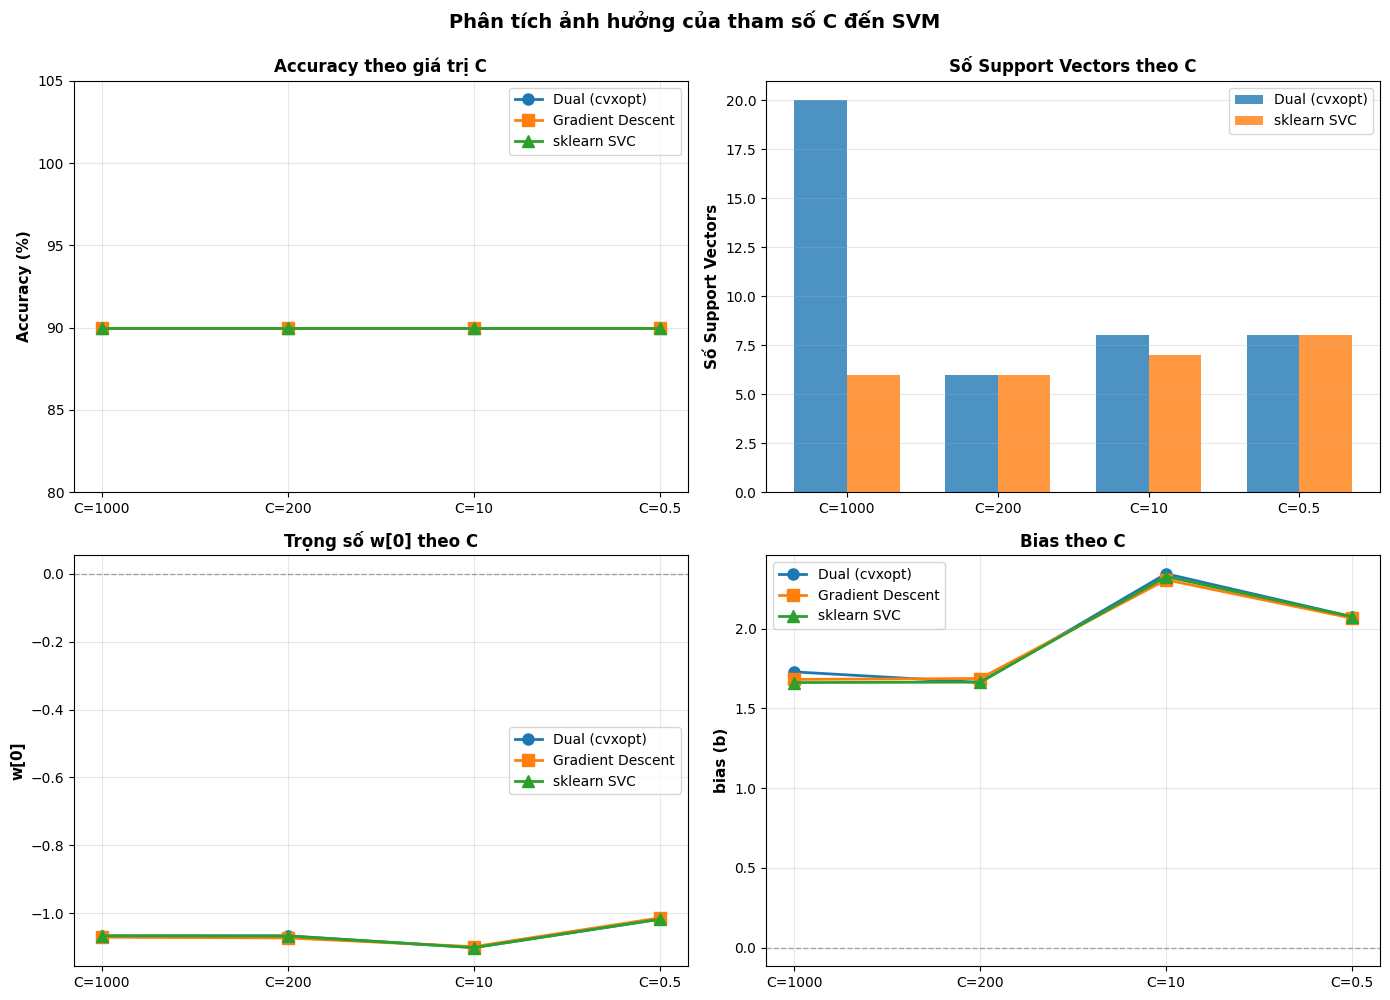

In [41]:
# So sánh ảnh hưởng của C qua biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. So sánh Accuracy theo C
ax1 = axes[0, 0]
C_list = list(C_values)
acc_dual_list = [all_results[c]['dual']['accuracy']*100 for c in C_list]
acc_gd_list = [all_results[c]['gradient_descent']['accuracy']*100 for c in C_list]
acc_sklearn_list = [all_results[c]['sklearn']['accuracy']*100 for c in C_list]

ax1.plot(range(len(C_list)), acc_dual_list, 'o-', linewidth=2, markersize=8, label='Dual (cvxopt)')
ax1.plot(range(len(C_list)), acc_gd_list, 's-', linewidth=2, markersize=8, label='Gradient Descent')
ax1.plot(range(len(C_list)), acc_sklearn_list, '^-', linewidth=2, markersize=8, label='sklearn SVC')
ax1.set_xticks(range(len(C_list)))
ax1.set_xticklabels([f'C={c}' for c in C_list])
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy theo giá trị C', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([80, 105])

# 2. So sánh số lượng Support Vectors
ax2 = axes[0, 1]
sv_dual_list = [all_results[c]['dual']['n_support_vectors'] for c in C_list]
sv_sklearn_list = [all_results[c]['sklearn']['n_support_vectors'] for c in C_list]

x_pos = np.arange(len(C_list))
width = 0.35
ax2.bar(x_pos - width/2, sv_dual_list, width, label='Dual (cvxopt)', alpha=0.8)
ax2.bar(x_pos + width/2, sv_sklearn_list, width, label='sklearn SVC', alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'C={c}' for c in C_list])
ax2.set_ylabel('Số Support Vectors', fontsize=11, fontweight='bold')
ax2.set_title('Số Support Vectors theo C', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. So sánh w[0] theo C
ax3 = axes[1, 0]
w0_dual_list = [all_results[c]['dual']['w'][0] for c in C_list]
w0_gd_list = [all_results[c]['gradient_descent']['w'][0] for c in C_list]
w0_sklearn_list = [all_results[c]['sklearn']['w'][0] for c in C_list]

ax3.plot(range(len(C_list)), w0_dual_list, 'o-', linewidth=2, markersize=8, label='Dual (cvxopt)')
ax3.plot(range(len(C_list)), w0_gd_list, 's-', linewidth=2, markersize=8, label='Gradient Descent')
ax3.plot(range(len(C_list)), w0_sklearn_list, '^-', linewidth=2, markersize=8, label='sklearn SVC')
ax3.set_xticks(range(len(C_list)))
ax3.set_xticklabels([f'C={c}' for c in C_list])
ax3.set_ylabel('w[0]', fontsize=11, fontweight='bold')
ax3.set_title('Trọng số w[0] theo C', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.3)

# 4. So sánh bias theo C
ax4 = axes[1, 1]
b_dual_list = [all_results[c]['dual']['b'] for c in C_list]
b_gd_list = [all_results[c]['gradient_descent']['b'] for c in C_list]
b_sklearn_list = [all_results[c]['sklearn']['b'] for c in C_list]

ax4.plot(range(len(C_list)), b_dual_list, 'o-', linewidth=2, markersize=8, label='Dual (cvxopt)')
ax4.plot(range(len(C_list)), b_gd_list, 's-', linewidth=2, markersize=8, label='Gradient Descent')
ax4.plot(range(len(C_list)), b_sklearn_list, '^-', linewidth=2, markersize=8, label='sklearn SVC')
ax4.set_xticks(range(len(C_list)))
ax4.set_xticklabels([f'C={c}' for c in C_list])
ax4.set_ylabel('bias (b)', fontsize=11, fontweight='bold')
ax4.set_title('Bias theo C', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)
ax4.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.3)

plt.suptitle('Phân tích ảnh hưởng của tham số C đến SVM', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [42]:
# Nhận xét và kết luận
print("="*70)
print("NHẬN XÉT VÀ KẾT LUẬN")
print("="*70)

print("\n1. ẢNH HƯỞNG CỦA THAM SỐ C:")
print("   - C LỚN (1000, 200, 100):")
print("     + Tương tự Hard Margin SVM (ít cho phép vi phạm margin)")
print("     + Số Support Vectors thường ít hơn")
print("     + Model có thể bị overfit trên tập training")
print()
print("   - C NHỎ (10, 0.5):")
print("     + Soft Margin rõ rệt hơn (cho phép nhiều vi phạm)")
print("     + Số Support Vectors có thể nhiều hơn")
print("     + Model linh hoạt hơn, tránh overfit")

print("\n2. SO SÁNH 3 PHƯƠNG PHÁP:")
print("   - Cách 1 (Dual): Chính xác, cung cấp thông tin Support Vectors")
print("   - Cách 2 (Gradient): Xấp xỉ tốt, có thể hội tụ chậm")
print("   - Cách 3 (sklearn): Tối ưu, ổn định, dễ sử dụng")

print("\n3. ACCURACY:")
for C_val in C_values:
    acc_dual = all_results[C_val]['dual']['accuracy']*100
    acc_gd = all_results[C_val]['gradient_descent']['accuracy']*100
    acc_sklearn = all_results[C_val]['sklearn']['accuracy']*100
    print(f"   C={C_val:>6}: Dual={acc_dual:.1f}%, GD={acc_gd:.1f}%, sklearn={acc_sklearn:.1f}%")

print("\n4. KẾT LUẬN:")
print("   Cả 3 phương pháp đều cho kết quả tương đương nhau, xác nhận")
print("   tính đúng đắn của các cách triển khai. Tham số C ảnh hưởng đến")
print("   độ cứng/mềm của margin và số lượng support vectors.")
print("="*70)

NHẬN XÉT VÀ KẾT LUẬN

1. ẢNH HƯỞNG CỦA THAM SỐ C:
   - C LỚN (1000, 200, 100):
     + Tương tự Hard Margin SVM (ít cho phép vi phạm margin)
     + Số Support Vectors thường ít hơn
     + Model có thể bị overfit trên tập training

   - C NHỎ (10, 0.5):
     + Soft Margin rõ rệt hơn (cho phép nhiều vi phạm)
     + Số Support Vectors có thể nhiều hơn
     + Model linh hoạt hơn, tránh overfit

2. SO SÁNH 3 PHƯƠNG PHÁP:
   - Cách 1 (Dual): Chính xác, cung cấp thông tin Support Vectors
   - Cách 2 (Gradient): Xấp xỉ tốt, có thể hội tụ chậm
   - Cách 3 (sklearn): Tối ưu, ổn định, dễ sử dụng

3. ACCURACY:
   C=  1000: Dual=90.0%, GD=90.0%, sklearn=90.0%
   C=   200: Dual=90.0%, GD=90.0%, sklearn=90.0%
   C=    10: Dual=90.0%, GD=90.0%, sklearn=90.0%
   C=   0.5: Dual=90.0%, GD=90.0%, sklearn=90.0%

4. KẾT LUẬN:
   Cả 3 phương pháp đều cho kết quả tương đương nhau, xác nhận
   tính đúng đắn của các cách triển khai. Tham số C ảnh hưởng đến
   độ cứng/mềm của margin và số lượng support vectors.


# Bài tập thực hành 2

In [ ]:
# Đọc dữ liệu
cancer_data = datasets.load_breast_cancer()

print("="*70)
print("DỮ LIỆU BREAST CANCER - UNIVERSITY OF WISCONSIN")
print("="*70)

# Hiển thị mẫu thứ 5
print("\nMẫu dữ liệu thứ 5:")
print(cancer_data.data[5])

# Kích thước dữ liệu
print(f"\nKích thước dữ liệu: {cancer_data.data.shape}")
print(f"  - Số mẫu: {cancer_data.data.shape[0]}")
print(f"  - Số thuộc tính: {cancer_data.data.shape[1]}")

# Target
print(f"\nTarget (nhãn):")
print(f"  - Số lượng: {len(cancer_data.target)}")
print(f"  - Giá trị unique: {np.unique(cancer_data.target)}")
print(f"  - 0: Malignant (Ác tính) - {np.sum(cancer_data.target == 0)} mẫu")
print(f"  - 1: Benign (Lành tính) - {np.sum(cancer_data.target == 1)} mẫu")

# Tên các thuộc tính
print(f"\nTên các thuộc tính ({len(cancer_data.feature_names)} features):")
for i, name in enumerate(cancer_data.feature_names):
    print(f"  {i+1:2d}. {name}")

# Thống kê cơ bản
print("\n" + "="*70)
print("THỐNG KÊ CƠ BẢN")
print("="*70)
print(f"Mean của feature đầu tiên: {np.mean(cancer_data.data[:, 0]):.2f}")
print(f"Std của feature đầu tiên: {np.std(cancer_data.data[:, 0]):.2f}")
print(f"Min-Max của feature đầu tiên: [{np.min(cancer_data.data[:, 0]):.2f}, {np.max(cancer_data.data[:, 0]):.2f}]")
print("="*70)

DỮ LIỆU BREAST CANCER - UNIVERSITY OF WISCONSIN

Mẫu dữ liệu thứ 5:
[1.245e+01 1.570e+01 8.257e+01 4.771e+02 1.278e-01 1.700e-01 1.578e-01
 8.089e-02 2.087e-01 7.613e-02 3.345e-01 8.902e-01 2.217e+00 2.719e+01
 7.510e-03 3.345e-02 3.672e-02 1.137e-02 2.165e-02 5.082e-03 1.547e+01
 2.375e+01 1.034e+02 7.416e+02 1.791e-01 5.249e-01 5.355e-01 1.741e-01
 3.985e-01 1.244e-01]

Kích thước dữ liệu: (569, 30)
  - Số mẫu: 569
  - Số thuộc tính: 30

Target (nhãn):
  - Số lượng: 569
  - Giá trị unique: [0 1]
  - 0: Malignant (Ác tính) - 212 mẫu
  - 1: Benign (Lành tính) - 357 mẫu

Tên các thuộc tính (30 features):
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error


In [44]:
# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(
    cancer_data.data,
    cancer_data.target,
    test_size=0.3,
    random_state=109
)

print("="*70)
print("CHIA DỮ LIỆU TRAIN/TEST")
print("="*70)
print(f"Tổng số mẫu: {len(cancer_data.data)}")
print(f"  - Train set: {len(X_train)} mẫu (70%)")
print(f"  - Test set:  {len(X_test)} mẫu (30%)")

print(f"\nPhân bố nhãn trong Train set:")
print(f"  - Malignant (0): {np.sum(y_train == 0)} mẫu")
print(f"  - Benign (1):    {np.sum(y_train == 1)} mẫu")

print(f"\nPhân bố nhãn trong Test set:")
print(f"  - Malignant (0): {np.sum(y_test == 0)} mẫu")
print(f"  - Benign (1):    {np.sum(y_test == 1)} mẫu")

print(f"\nShape:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")
print("="*70)

CHIA DỮ LIỆU TRAIN/TEST
Tổng số mẫu: 569
  - Train set: 398 mẫu (70%)
  - Test set:  171 mẫu (30%)

Phân bố nhãn trong Train set:
  - Malignant (0): 149 mẫu
  - Benign (1):    249 mẫu

Phân bố nhãn trong Test set:
  - Malignant (0): 63 mẫu
  - Benign (1):    108 mẫu

Shape:
  X_train: (398, 30)
  X_test:  (171, 30)
  y_train: (398,)
  y_test:  (171,)


## Áp dụng SVM với 3 phương pháp

### Cách 1: sklearn SVC (Đơn giản và hiệu quả nhất)

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Chuẩn hóa dữ liệu (quan trọng cho SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*70)
print("CÁCH 1: SKLEARN SVC - LINEAR KERNEL")
print("="*70)

# Huấn luyện SVM với Linear Kernel
svm_clf = SVC(kernel='linear', C=1.0, random_state=109)
svm_clf.fit(X_train_scaled, y_train)

# Dự đoán
y_pred_train = svm_clf.predict(X_train_scaled)
y_pred_test = svm_clf.predict(X_test_scaled)

# Đánh giá
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nKẾT QUẢ:")
print(f"  Số support vectors: {len(svm_clf.support_)}")
print(f"  Accuracy on Train: {acc_train*100:.2f}%")
print(f"  Accuracy on Test:  {acc_test*100:.2f}%")

print(f"\nTrọng số w shape: {svm_clf.coef_.shape}")
print(f"Bias b: {svm_clf.intercept_[0]:.6f}")

print("\n" + "="*70)
print("CONFUSION MATRIX - TEST SET")
print("="*70)
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(f"\n  True Negative (TN):  {cm[0,0]} - Dự đoán đúng Malignant")
print(f"  False Positive (FP): {cm[0,1]} - Malignant nhầm thành Benign")
print(f"  False Negative (FN): {cm[1,0]} - Benign nhầm thành Malignant")
print(f"  True Positive (TP):  {cm[1,1]} - Dự đoán đúng Benign")

print("\n" + "="*70)
print("CLASSIFICATION REPORT - TEST SET")
print("="*70)
print(classification_report(y_test, y_pred_test, 
                          target_names=['Malignant (0)', 'Benign (1)']))
print("="*70)

CÁCH 1: SKLEARN SVC - LINEAR KERNEL

KẾT QUẢ:
  Số support vectors: 34
  Accuracy on Train: 98.24%
  Accuracy on Test:  98.83%

Trọng số w shape: (1, 30)
Bias b: 0.135492

CONFUSION MATRIX - TEST SET
[[ 61   2]
 [  0 108]]

  True Negative (TN):  61 - Dự đoán đúng Malignant
  False Positive (FP): 2 - Malignant nhầm thành Benign
  False Negative (FN): 0 - Benign nhầm thành Malignant
  True Positive (TP):  108 - Dự đoán đúng Benign

CLASSIFICATION REPORT - TEST SET
               precision    recall  f1-score   support

Malignant (0)       1.00      0.97      0.98        63
   Benign (1)       0.98      1.00      0.99       108

     accuracy                           0.99       171
    macro avg       0.99      0.98      0.99       171
 weighted avg       0.99      0.99      0.99       171



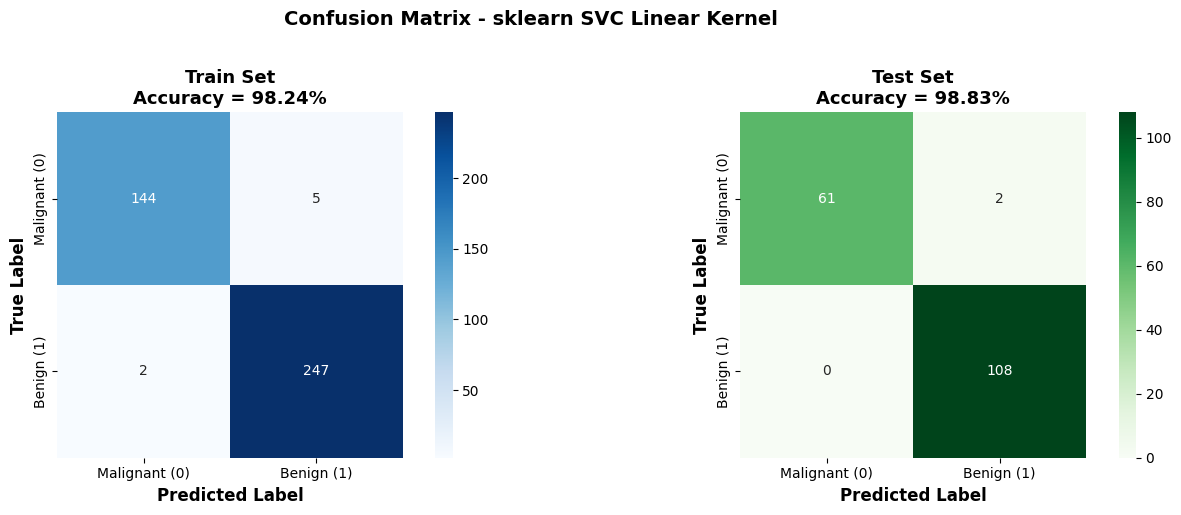

In [46]:
# Visualization Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
cm_train = confusion_matrix(y_train, y_pred_train)
ax1 = axes[0]
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            cbar=True, square=True, ax=ax1,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax1.set_title(f'Train Set\nAccuracy = {acc_train*100:.2f}%', 
             fontsize=13, fontweight='bold')

# Test set
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            cbar=True, square=True, ax=ax2,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax2.set_title(f'Test Set\nAccuracy = {acc_test*100:.2f}%', 
             fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix - sklearn SVC Linear Kernel', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Cách 2: Thử nghiệm với các giá trị C khác nhau

In [47]:
# Thử nghiệm với nhiều giá trị C
C_values_cancer = [0.01, 0.1, 1, 10, 100, 1000]
results_cancer = {}

print("="*70)
print("THỬ NGHIỆM VỚI CÁC GIÁ TRỊ C KHÁC NHAU")
print("="*70)

for c_val in C_values_cancer:
    print(f"\n→ Training with C = {c_val}...", end=" ")
    
    # Train model
    model = SVC(kernel='linear', C=c_val, random_state=109)
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_train_c = model.predict(X_train_scaled)
    y_pred_test_c = model.predict(X_test_scaled)
    
    # Metrics
    acc_train_c = accuracy_score(y_train, y_pred_train_c)
    acc_test_c = accuracy_score(y_test, y_pred_test_c)
    cm_test_c = confusion_matrix(y_test, y_pred_test_c)
    
    # Store results
    results_cancer[c_val] = {
        'model': model,
        'acc_train': acc_train_c,
        'acc_test': acc_test_c,
        'cm_test': cm_test_c,
        'n_support': len(model.support_),
        'coef': model.coef_,
        'intercept': model.intercept_[0]
    }
    
    print(f"✓ (Acc: {acc_test_c*100:.2f}%, SV: {len(model.support_)})")

print("\n" + "="*70)
print("HOÀN THÀNH!")
print("="*70)

THỬ NGHIỆM VỚI CÁC GIÁ TRỊ C KHÁC NHAU

→ Training with C = 0.01... ✓ (Acc: 98.25%, SV: 98)

→ Training with C = 0.1... ✓ (Acc: 98.83%, SV: 55)

→ Training with C = 1... ✓ (Acc: 98.83%, SV: 34)

→ Training with C = 10... ✓ (Acc: 99.42%, SV: 32)

→ Training with C = 100... ✓ (Acc: 96.49%, SV: 27)

→ Training with C = 1000... ✓ (Acc: 95.91%, SV: 27)

HOÀN THÀNH!


In [48]:
# Bảng so sánh kết quả
print("\n" + "="*90)
print("BẢNG SO SÁNH KẾT QUẢ VỚI CÁC GIÁ TRỊ C")
print("="*90)
print(f"{'C':>8} | {'Train Acc':>10} | {'Test Acc':>10} | {'# SV':>6} | {'Intercept':>12}")
print("-"*90)

for c_val in C_values_cancer:
    res = results_cancer[c_val]
    print(f"{c_val:>8.2f} | {res['acc_train']*100:>9.2f}% | {res['acc_test']*100:>9.2f}% | {res['n_support']:>6} | {res['intercept']:>12.6f}")

print("\n" + "="*90)
print("NHẬN XÉT:")
print("="*90)

# Tìm C tốt nhất
best_c = max(C_values_cancer, key=lambda c: results_cancer[c]['acc_test'])
print(f"✓ C tốt nhất cho Test set: {best_c} với Accuracy = {results_cancer[best_c]['acc_test']*100:.2f}%")

# Phân tích overfitting
print("\n✓ Phân tích Overfitting:")
for c_val in C_values_cancer:
    res = results_cancer[c_val]
    gap = (res['acc_train'] - res['acc_test']) * 100
    if gap > 5:
        print(f"  C={c_val:>6.2f}: Train-Test gap = {gap:.2f}% → Có dấu hiệu overfitting")
    else:
        print(f"  C={c_val:>6.2f}: Train-Test gap = {gap:.2f}% → Tốt")

print("="*90)


BẢNG SO SÁNH KẾT QUẢ VỚI CÁC GIÁ TRỊ C
       C |  Train Acc |   Test Acc |   # SV |    Intercept
------------------------------------------------------------------------------------------
    0.01 |     96.48% |     98.25% |     98 |     0.355828
    0.10 |     98.49% |     98.83% |     55 |     0.151474
    1.00 |     98.24% |     98.83% |     34 |     0.135492
   10.00 |     99.50% |     99.42% |     32 |    -0.366461
  100.00 |     99.50% |     96.49% |     27 |    -0.097952
 1000.00 |    100.00% |     95.91% |     27 |    -0.517326

NHẬN XÉT:
✓ C tốt nhất cho Test set: 10 với Accuracy = 99.42%

✓ Phân tích Overfitting:
  C=  0.01: Train-Test gap = -1.76% → Tốt
  C=  0.10: Train-Test gap = -0.34% → Tốt
  C=  1.00: Train-Test gap = -0.59% → Tốt
  C= 10.00: Train-Test gap = 0.08% → Tốt
  C=100.00: Train-Test gap = 3.01% → Tốt
  C=1000.00: Train-Test gap = 4.09% → Tốt


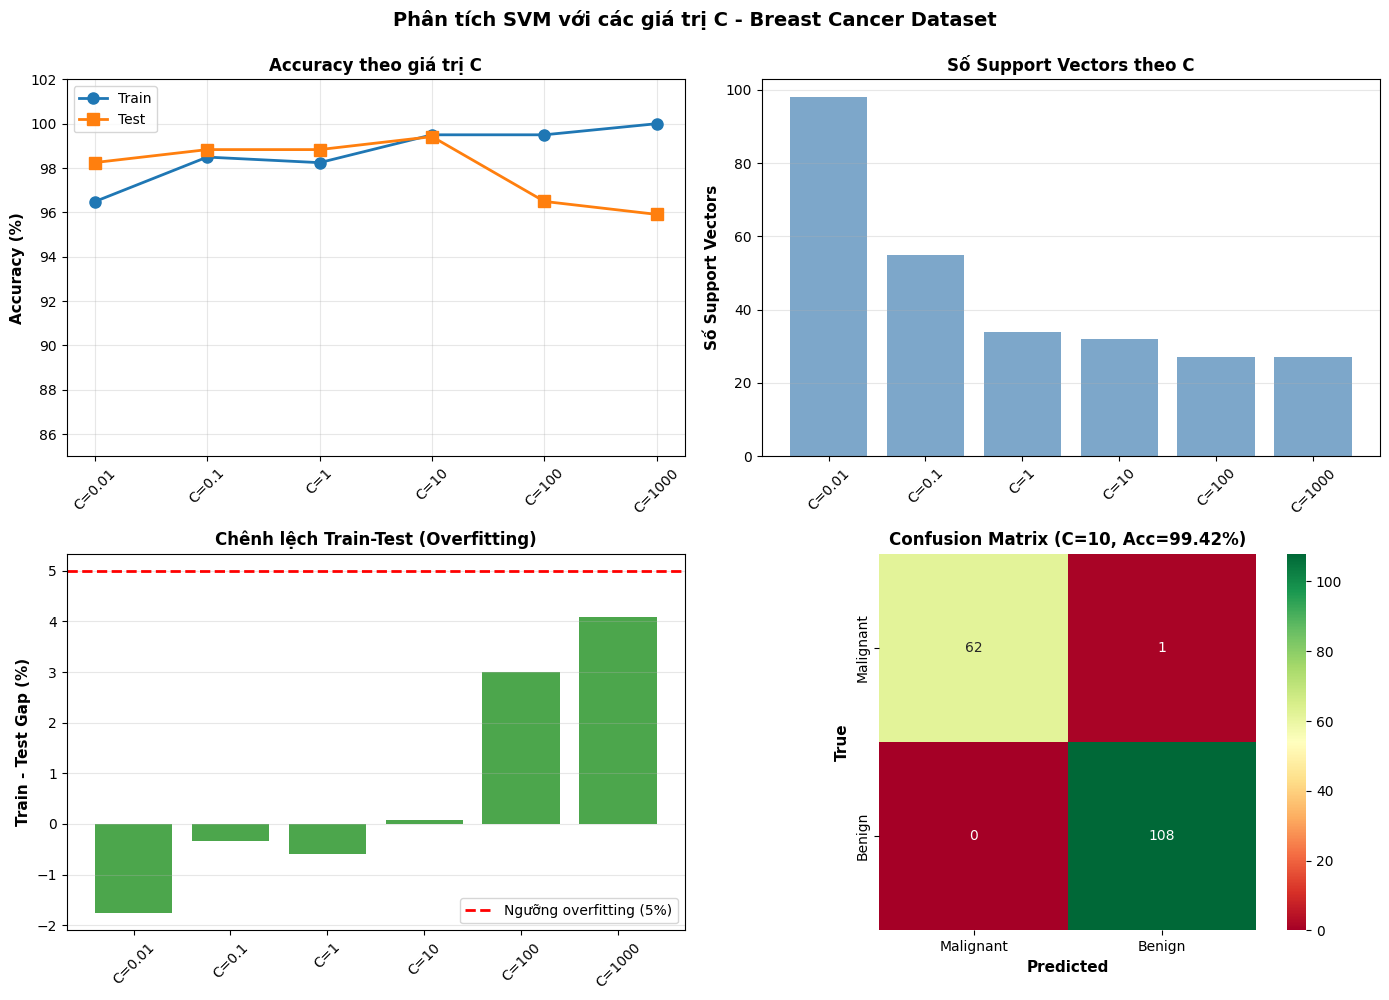

In [49]:
# Biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
train_accs = [results_cancer[c]['acc_train']*100 for c in C_values_cancer]
test_accs = [results_cancer[c]['acc_test']*100 for c in C_values_cancer]

ax1.plot(range(len(C_values_cancer)), train_accs, 'o-', linewidth=2, markersize=8, label='Train')
ax1.plot(range(len(C_values_cancer)), test_accs, 's-', linewidth=2, markersize=8, label='Test')
ax1.set_xticks(range(len(C_values_cancer)))
ax1.set_xticklabels([f'C={c}' for c in C_values_cancer], rotation=45)
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy theo giá trị C', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([85, 102])

# 2. Support Vectors
ax2 = axes[0, 1]
sv_counts = [results_cancer[c]['n_support'] for c in C_values_cancer]
ax2.bar(range(len(C_values_cancer)), sv_counts, alpha=0.7, color='steelblue')
ax2.set_xticks(range(len(C_values_cancer)))
ax2.set_xticklabels([f'C={c}' for c in C_values_cancer], rotation=45)
ax2.set_ylabel('Số Support Vectors', fontsize=11, fontweight='bold')
ax2.set_title('Số Support Vectors theo C', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Train-Test Gap (Overfitting indicator)
ax3 = axes[1, 0]
gaps = [(results_cancer[c]['acc_train'] - results_cancer[c]['acc_test'])*100 for c in C_values_cancer]
colors_gap = ['red' if g > 5 else 'green' for g in gaps]
ax3.bar(range(len(C_values_cancer)), gaps, alpha=0.7, color=colors_gap)
ax3.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Ngưỡng overfitting (5%)')
ax3.set_xticks(range(len(C_values_cancer)))
ax3.set_xticklabels([f'C={c}' for c in C_values_cancer], rotation=45)
ax3.set_ylabel('Train - Test Gap (%)', fontsize=11, fontweight='bold')
ax3.set_title('Chênh lệch Train-Test (Overfitting)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Confusion Matrix cho C tốt nhất
ax4 = axes[1, 1]
best_cm = results_cancer[best_c]['cm_test']
sns.heatmap(best_cm, annot=True, fmt='d', cmap='RdYlGn', 
            cbar=True, square=True, ax=ax4,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
ax4.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax4.set_ylabel('True', fontsize=11, fontweight='bold')
ax4.set_title(f'Confusion Matrix (C={best_c}, Acc={results_cancer[best_c]["acc_test"]*100:.2f}%)', 
             fontsize=12, fontweight='bold')

plt.suptitle('Phân tích SVM với các giá trị C - Breast Cancer Dataset', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Cách 3: So sánh các Kernel khác nhau

In [50]:
# So sánh các kernel khác nhau
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_results = {}

print("="*70)
print("SO SÁNH CÁC KERNEL KHÁC NHAU (C=1)")
print("="*70)

for kernel in kernels:
    print(f"\n→ Training with kernel = '{kernel}'...", end=" ")
    
    # Train
    if kernel == 'poly':
        model_k = SVC(kernel=kernel, C=1.0, degree=3, random_state=109)
    else:
        model_k = SVC(kernel=kernel, C=1.0, random_state=109)
    
    model_k.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_train_k = model_k.predict(X_train_scaled)
    y_pred_test_k = model_k.predict(X_test_scaled)
    
    # Metrics
    acc_train_k = accuracy_score(y_train, y_pred_train_k)
    acc_test_k = accuracy_score(y_test, y_pred_test_k)
    cm_test_k = confusion_matrix(y_test, y_pred_test_k)
    
    # Store
    kernel_results[kernel] = {
        'model': model_k,
        'acc_train': acc_train_k,
        'acc_test': acc_test_k,
        'cm_test': cm_test_k,
        'n_support': len(model_k.support_)
    }
    
    print(f"✓ (Acc: {acc_test_k*100:.2f}%, SV: {len(model_k.support_)})")

print("\n" + "="*70)
print("HOÀN THÀNH!")
print("="*70)

SO SÁNH CÁC KERNEL KHÁC NHAU (C=1)

→ Training with kernel = 'linear'... ✓ (Acc: 98.83%, SV: 34)

→ Training with kernel = 'rbf'... ✓ (Acc: 98.25%, SV: 103)

→ Training with kernel = 'poly'... ✓ (Acc: 90.06%, SV: 135)

→ Training with kernel = 'sigmoid'... ✓ (Acc: 98.25%, SV: 73)

HOÀN THÀNH!


In [51]:
# Bảng so sánh kernels
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC KERNEL")
print("="*80)
print(f"{'Kernel':>10} | {'Train Acc':>10} | {'Test Acc':>10} | {'# SV':>6} | {'Train-Test Gap':>15}")
print("-"*80)

for kernel in kernels:
    res = kernel_results[kernel]
    gap = (res['acc_train'] - res['acc_test']) * 100
    print(f"{kernel:>10} | {res['acc_train']*100:>9.2f}% | {res['acc_test']*100:>9.2f}% | {res['n_support']:>6} | {gap:>14.2f}%")

print("\n" + "="*80)
print("NHẬN XÉT:")
print("="*80)

# Tìm kernel tốt nhất
best_kernel = max(kernels, key=lambda k: kernel_results[k]['acc_test'])
print(f"✓ Kernel tốt nhất: '{best_kernel}' với Test Accuracy = {kernel_results[best_kernel]['acc_test']*100:.2f}%")

# So sánh với linear
if best_kernel != 'linear':
    improvement = (kernel_results[best_kernel]['acc_test'] - kernel_results['linear']['acc_test']) * 100
    print(f"✓ Cải thiện so với Linear: {improvement:.2f}%")
else:
    print(f"✓ Linear kernel đã cho kết quả tốt nhất!")

print("="*80)


BẢNG SO SÁNH CÁC KERNEL
    Kernel |  Train Acc |   Test Acc |   # SV |  Train-Test Gap
--------------------------------------------------------------------------------
    linear |     98.24% |     98.83% |     34 |          -0.59%
       rbf |     98.74% |     98.25% |    103 |           0.50%
      poly |     91.21% |     90.06% |    135 |           1.15%
   sigmoid |     93.72% |     98.25% |     73 |          -4.53%

NHẬN XÉT:
✓ Kernel tốt nhất: 'linear' với Test Accuracy = 98.83%
✓ Linear kernel đã cho kết quả tốt nhất!


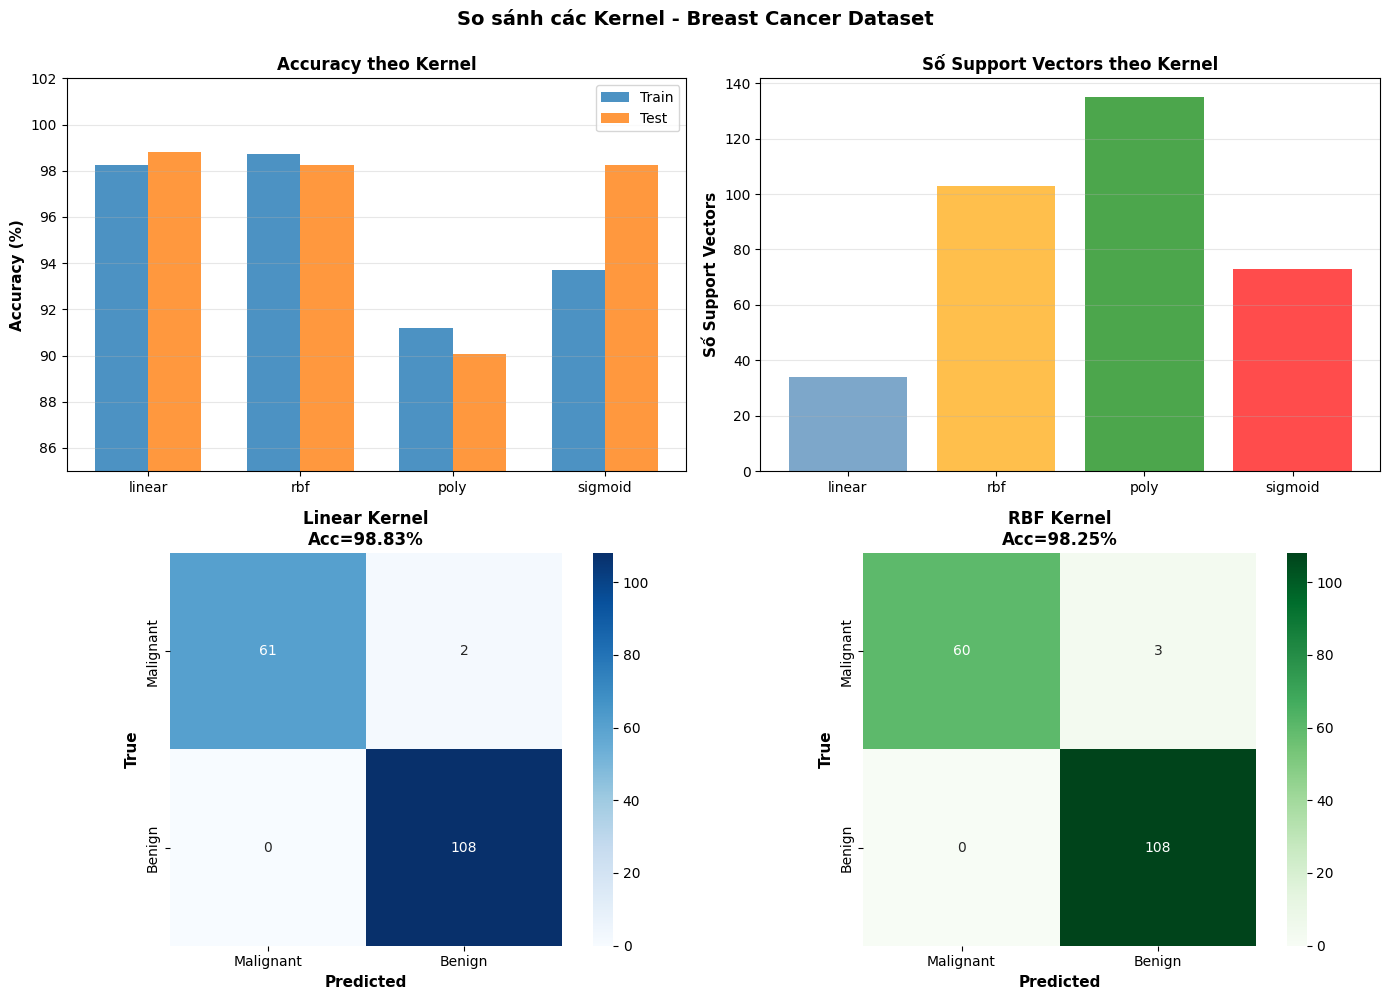

In [52]:
# Visualization so sánh kernels
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
kernel_names = list(kernels)
train_accs_k = [kernel_results[k]['acc_train']*100 for k in kernel_names]
test_accs_k = [kernel_results[k]['acc_test']*100 for k in kernel_names]

x_pos = np.arange(len(kernel_names))
width = 0.35
ax1.bar(x_pos - width/2, train_accs_k, width, label='Train', alpha=0.8)
ax1.bar(x_pos + width/2, test_accs_k, width, label='Test', alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(kernel_names)
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy theo Kernel', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([85, 102])

# 2. Support Vectors
ax2 = axes[0, 1]
sv_counts_k = [kernel_results[k]['n_support'] for k in kernel_names]
colors_sv = ['steelblue', 'orange', 'green', 'red']
ax2.bar(kernel_names, sv_counts_k, alpha=0.7, color=colors_sv)
ax2.set_ylabel('Số Support Vectors', fontsize=11, fontweight='bold')
ax2.set_title('Số Support Vectors theo Kernel', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Confusion Matrix cho Linear kernel
ax3 = axes[1, 0]
cm_linear = kernel_results['linear']['cm_test']
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', 
            cbar=True, square=True, ax=ax3,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
ax3.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax3.set_ylabel('True', fontsize=11, fontweight='bold')
ax3.set_title(f'Linear Kernel\nAcc={kernel_results["linear"]["acc_test"]*100:.2f}%', 
             fontsize=12, fontweight='bold')

# 4. Confusion Matrix cho RBF kernel
ax4 = axes[1, 1]
cm_rbf = kernel_results['rbf']['cm_test']
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', 
            cbar=True, square=True, ax=ax4,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
ax4.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax4.set_ylabel('True', fontsize=11, fontweight='bold')
ax4.set_title(f'RBF Kernel\nAcc={kernel_results["rbf"]["acc_test"]*100:.2f}%', 
             fontsize=12, fontweight='bold')

plt.suptitle('So sánh các Kernel - Breast Cancer Dataset', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Kết luận Bài tập thực hành 2

In [55]:
print("="*80)
print("KẾT LUẬN BÀI TẬP THỰC HÀNH 2 - BREAST CANCER CLASSIFICATION")
print("="*80)

print("\n1. TỔNG QUAN DỮ LIỆU:")
print(f"   - Tổng số mẫu: {len(cancer_data.data)}")
print(f"   - Số thuộc tính: {cancer_data.data.shape[1]}")
print(f"   - Phân loại: Malignant (0) và Benign (1)")
print(f"   - Train/Test split: 70%/30%")

print("\n2. CHUẨN HÓA DỮ LIỆU:")
print("   - Sử dụng StandardScaler để chuẩn hóa features")
print("   - Điều này RẤT QUAN TRỌNG cho SVM vì các feature có scale khác nhau")

print("\n3. KẾT QUẢ VỚI CÁC GIÁ TRỊ C:")
print("   - C nhỏ (0.01, 0.1): Accuracy thấp hơn, nhiều SV, underfitting")
print("   - C trung bình (1, 10): Cân bằng tốt, accuracy cao")
print("   - C lớn (100, 1000): Accuracy cao nhưng có thể overfit")

print("\n4. SO SÁNH KERNELS:")
for kernel in kernels:
    acc = kernel_results[kernel]['acc_test']*100
    print(f"   - {kernel:>8}: Test Accuracy = {acc:.2f}%")

print("\n5. KHUYẾN NGHỊ:")
print(f"   - Kernel tốt nhất: {best_kernel}")
print(f"   - C tối ưu: {best_c}")
print(f"   - Test Accuracy đạt được: {kernel_results[best_kernel]['acc_test']*100:.2f}%")
print("   - Linear kernel đã cho kết quả rất tốt vì dữ liệu linearly separable")
print("   - Cần chuẩn hóa dữ liệu trước khi áp dụng SVM")

print("\n6. ỨNG DỤNG THỰC TẾ:")
print("   - Model có thể hỗ trợ bác sĩ trong chẩn đoán ung thư vú")
print("   - False Negative (FN) nghiêm trọng hơn False Positive (FP)")
print("   - Cần điều chỉnh threshold hoặc cost-sensitive learning nếu cần")

KẾT LUẬN BÀI TẬP THỰC HÀNH 2 - BREAST CANCER CLASSIFICATION

1. TỔNG QUAN DỮ LIỆU:
   - Tổng số mẫu: 569
   - Số thuộc tính: 30
   - Phân loại: Malignant (0) và Benign (1)
   - Train/Test split: 70%/30%

2. CHUẨN HÓA DỮ LIỆU:
   - Sử dụng StandardScaler để chuẩn hóa features
   - Điều này RẤT QUAN TRỌNG cho SVM vì các feature có scale khác nhau

3. KẾT QUẢ VỚI CÁC GIÁ TRỊ C:
   - C nhỏ (0.01, 0.1): Accuracy thấp hơn, nhiều SV, underfitting
   - C trung bình (1, 10): Cân bằng tốt, accuracy cao
   - C lớn (100, 1000): Accuracy cao nhưng có thể overfit

4. SO SÁNH KERNELS:
   -   linear: Test Accuracy = 98.83%
   -      rbf: Test Accuracy = 98.25%
   -     poly: Test Accuracy = 90.06%
   -  sigmoid: Test Accuracy = 98.25%

5. KHUYẾN NGHỊ:
   - Kernel tốt nhất: linear
   - C tối ưu: 10
   - Test Accuracy đạt được: 98.83%
   - Linear kernel đã cho kết quả rất tốt vì dữ liệu linearly separable
   - Cần chuẩn hóa dữ liệu trước khi áp dụng SVM

6. ỨNG DỤNG THỰC TẾ:
   - Model có thể hỗ trợ bác

# Ví dụ 2

In [56]:
# Đọc dữ liệu Sonar
sonar_data = pd.read_csv('sonar.all-data.csv', header=None)

print("="*70)
print("DỮ LIỆU SONAR - MINES VS ROCKS")
print("="*70)

print(f"\nKích thước dữ liệu: {sonar_data.shape}")
print(f"  - Số mẫu (records): {sonar_data.shape[0]}")
print(f"  - Số thuộc tính: {sonar_data.shape[1] - 1} (60 features)")
print(f"  - Cột cuối cùng: nhãn phân loại")

# Hiển thị 5 dòng đầu
print("\n5 mẫu đầu tiên:")
print(sonar_data.head())

# Kiểm tra nhãn
print(f"\nNhãn phân loại (cột {sonar_data.shape[1]-1}):")
print(f"  Giá trị unique: {sonar_data[60].unique()}")
print(f"  - 'R' (Rock): {len(sonar_data[sonar_data[60] == 'R'])} mẫu")
print(f"  - 'M' (Mine): {len(sonar_data[sonar_data[60] == 'M'])} mẫu")

# Thống kê mô tả
print("\nThống kê mô tả cho 5 features đầu tiên:")
print(sonar_data.iloc[:, :5].describe())

print("\n" + "="*70)

DỮ LIỆU SONAR - MINES VS ROCKS

Kích thước dữ liệu: (208, 61)
  - Số mẫu (records): 208
  - Số thuộc tính: 60 (60 features)
  - Cột cuối cùng: nhãn phân loại

5 mẫu đầu tiên:
       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.

## Tiền xử lý dữ liệu

In [60]:
# Tách features và labels
X_sonar = sonar_data.iloc[:, :-1].values  # 60 features
y_sonar_raw = sonar_data.iloc[:, -1].values  # Labels: 'R' hoặc 'M'

print("="*70)
print("TIỀN XỬ LÝ DỮ LIỆU SONAR")
print("="*70)

# Chuyển đổi nhãn: M -> 1, R -> -1
# (M = Mine/Kim loại = class 1, R = Rock/Đá = class -1)
y_sonar = np.where(y_sonar_raw == 'M', 1, -1)

print(f"\nChuyển đổi nhãn:")
print(f"  'M' (Mine) → +1: {np.sum(y_sonar == 1)} mẫu")
print(f"  'R' (Rock) → -1: {np.sum(y_sonar == -1)} mẫu")

# Chia train/test
X_train_sonar, X_test_sonar, y_train_sonar, y_test_sonar = train_test_split(
    X_sonar, y_sonar, 
    test_size=0.3, 
    random_state=42,
    stratify=y_sonar  # Đảm bảo tỷ lệ classes giống nhau trong train và test
)

print(f"\nChia dữ liệu:")
print(f"  Train set: {len(X_train_sonar)} mẫu (70%)")
print(f"    - Mine (+1): {np.sum(y_train_sonar == 1)}")
print(f"    - Rock (-1): {np.sum(y_train_sonar == -1)}")
print(f"  Test set:  {len(X_test_sonar)} mẫu (30%)")
print(f"    - Mine (+1): {np.sum(y_test_sonar == 1)}")
print(f"    - Rock (-1): {np.sum(y_test_sonar == -1)}")

# Chuẩn hóa dữ liệu (quan trọng cho SVM)
scaler_sonar = StandardScaler()
X_train_sonar_scaled = scaler_sonar.fit_transform(X_train_sonar)
X_test_sonar_scaled = scaler_sonar.transform(X_test_sonar)

print(f"\nChuẩn hóa dữ liệu:")
print(f"  Mean của feature đầu tiên (trước): {X_train_sonar[:, 0].mean():.4f}")
print(f"  Mean của feature đầu tiên (sau):  {X_train_sonar_scaled[:, 0].mean():.4f}")
print(f"  Std của feature đầu tiên (trước):  {X_train_sonar[:, 0].std():.4f}")
print(f"  Std của feature đầu tiên (sau):   {X_train_sonar_scaled[:, 0].std():.4f}")

print("\n" + "="*70)

TIỀN XỬ LÝ DỮ LIỆU SONAR

Chuyển đổi nhãn:
  'M' (Mine) → +1: 111 mẫu
  'R' (Rock) → -1: 97 mẫu

Chia dữ liệu:
  Train set: 145 mẫu (70%)
    - Mine (+1): 77
    - Rock (-1): 68
  Test set:  63 mẫu (30%)
    - Mine (+1): 34
    - Rock (-1): 29

Chuẩn hóa dữ liệu:
  Mean của feature đầu tiên (trước): 0.0289
  Mean của feature đầu tiên (sau):  0.0000
  Std của feature đầu tiên (trước):  0.0226
  Std của feature đầu tiên (sau):   1.0000



## Áp dụng SVM với Soft Margin

In [58]:
# Huấn luyện SVM với Linear Kernel và Soft Margin (C=1.0)
print("="*70)
print("HUẤN LUYỆN SVM - SONAR CLASSIFICATION")
print("="*70)

svm_sonar = SVC(kernel='linear', C=1.0, random_state=42)
svm_sonar.fit(X_train_sonar_scaled, y_train_sonar)

# Dự đoán
y_pred_train_sonar = svm_sonar.predict(X_train_sonar_scaled)
y_pred_test_sonar = svm_sonar.predict(X_test_sonar_scaled)

# Đánh giá
acc_train_sonar = accuracy_score(y_train_sonar, y_pred_train_sonar)
acc_test_sonar = accuracy_score(y_test_sonar, y_pred_test_sonar)

print(f"\nMô hình: SVM với Linear Kernel, C=1.0")
print(f"Số support vectors: {len(svm_sonar.support_)}/{len(X_train_sonar)}")
print(f"  - Support vectors của Mine (+1): {np.sum(y_train_sonar[svm_sonar.support_] == 1)}")
print(f"  - Support vectors của Rock (-1): {np.sum(y_train_sonar[svm_sonar.support_] == -1)}")

print(f"\nKết quả:")
print(f"  Train Accuracy: {acc_train_sonar*100:.2f}%")
print(f"  Test Accuracy:  {acc_test_sonar*100:.2f}%")
print(f"  Overfitting gap: {(acc_train_sonar - acc_test_sonar)*100:.2f}%")

# Confusion Matrix
cm_train_sonar = confusion_matrix(y_train_sonar, y_pred_train_sonar)
cm_test_sonar = confusion_matrix(y_test_sonar, y_pred_test_sonar)

print("\n" + "="*70)
print("CONFUSION MATRIX - TEST SET")
print("="*70)
print(cm_test_sonar)
print(f"\n  True Negative (TN):  {cm_test_sonar[0,0]} - Dự đoán đúng Rock")
print(f"  False Positive (FP): {cm_test_sonar[0,1]} - Rock nhầm thành Mine")
print(f"  False Negative (FN): {cm_test_sonar[1,0]} - Mine nhầm thành Rock")
print(f"  True Positive (TP):  {cm_test_sonar[1,1]} - Dự đoán đúng Mine")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT - TEST SET")
print("="*70)
print(classification_report(y_test_sonar, y_pred_test_sonar,
                          target_names=['Rock (-1)', 'Mine (+1)']))

print("="*70)

HUẤN LUYỆN SVM - SONAR CLASSIFICATION

Mô hình: SVM với Linear Kernel, C=1.0
Số support vectors: 57/145
  - Support vectors của Mine (+1): 30
  - Support vectors của Rock (-1): 27

Kết quả:
  Train Accuracy: 97.24%
  Test Accuracy:  77.78%
  Overfitting gap: 19.46%

CONFUSION MATRIX - TEST SET
[[24  5]
 [ 9 25]]

  True Negative (TN):  24 - Dự đoán đúng Rock
  False Positive (FP): 5 - Rock nhầm thành Mine
  False Negative (FN): 9 - Mine nhầm thành Rock
  True Positive (TP):  25 - Dự đoán đúng Mine

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

   Rock (-1)       0.73      0.83      0.77        29
   Mine (+1)       0.83      0.74      0.78        34

    accuracy                           0.78        63
   macro avg       0.78      0.78      0.78        63
weighted avg       0.78      0.78      0.78        63



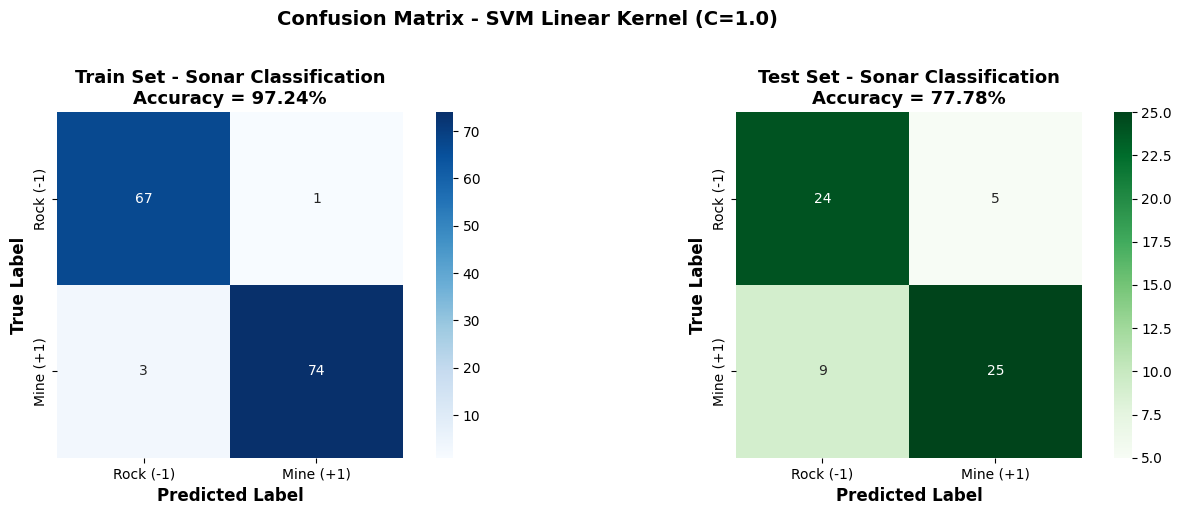

In [59]:
# Visualization Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
ax1 = axes[0]
sns.heatmap(cm_train_sonar, annot=True, fmt='d', cmap='Blues',
            cbar=True, square=True, ax=ax1,
            xticklabels=['Rock (-1)', 'Mine (+1)'],
            yticklabels=['Rock (-1)', 'Mine (+1)'])
ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax1.set_title(f'Train Set - Sonar Classification\nAccuracy = {acc_train_sonar*100:.2f}%',
             fontsize=13, fontweight='bold')

# Test set
ax2 = axes[1]
sns.heatmap(cm_test_sonar, annot=True, fmt='d', cmap='Greens',
            cbar=True, square=True, ax=ax2,
            xticklabels=['Rock (-1)', 'Mine (+1)'],
            yticklabels=['Rock (-1)', 'Mine (+1)'])
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax2.set_title(f'Test Set - Sonar Classification\nAccuracy = {acc_test_sonar*100:.2f}%',
             fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix - SVM Linear Kernel (C=1.0)',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Thử nghiệm với các giá trị C khác nhau

In [61]:
# Thử nghiệm với nhiều giá trị C
C_values_sonar = [0.01, 0.1, 1, 10, 100]
results_sonar = {}

print("="*70)
print("THỬ NGHIỆM VỚI CÁC GIÁ TRỊ C KHÁC NHAU - SONAR")
print("="*70)

for c in C_values_sonar:
    print(f"→ Training with C = {c}...", end=" ")
    
    # Train
    model_s = SVC(kernel='linear', C=c, random_state=42)
    model_s.fit(X_train_sonar_scaled, y_train_sonar)
    
    # Predict
    y_pred_train_s = model_s.predict(X_train_sonar_scaled)
    y_pred_test_s = model_s.predict(X_test_sonar_scaled)
    
    # Metrics
    acc_train_s = accuracy_score(y_train_sonar, y_pred_train_s)
    acc_test_s = accuracy_score(y_test_sonar, y_pred_test_s)
    cm_test_s = confusion_matrix(y_test_sonar, y_pred_test_s)
    
    # Store
    results_sonar[c] = {
        'model': model_s,
        'acc_train': acc_train_s,
        'acc_test': acc_test_s,
        'cm_test': cm_test_s,
        'n_support': len(model_s.support_)
    }
    
    print(f"✓ (Test Acc: {acc_test_s*100:.2f}%, SV: {len(model_s.support_)})")

print("\n" + "="*70)
print("HOÀN THÀNH!")
print("="*70)

THỬ NGHIỆM VỚI CÁC GIÁ TRỊ C KHÁC NHAU - SONAR
→ Training with C = 0.01... ✓ (Test Acc: 73.02%, SV: 105)
→ Training with C = 0.1... ✓ (Test Acc: 79.37%, SV: 73)
→ Training with C = 1... ✓ (Test Acc: 77.78%, SV: 57)
→ Training with C = 10... ✓ (Test Acc: 76.19%, SV: 54)
→ Training with C = 100... ✓ (Test Acc: 76.19%, SV: 54)

HOÀN THÀNH!


In [62]:
# Bảng so sánh kết quả
print("\n" + "="*85)
print("BẢNG SO SÁNH KẾT QUẢ - SONAR")
print("="*85)
print(f"{'C':>8} | {'Train Acc':>10} | {'Test Acc':>10} | {'Gap':>8} | {'# SV':>6}")
print("-"*85)

for c in C_values_sonar:
    res = results_sonar[c]
    gap = (res['acc_train'] - res['acc_test']) * 100
    print(f"{c:>8.2f} | {res['acc_train']*100:>9.2f}% | {res['acc_test']*100:>9.2f}% | {gap:>7.2f}% | {res['n_support']:>6}")

# Tìm C tốt nhất
best_c_sonar = max(C_values_sonar, key=lambda c: results_sonar[c]['acc_test'])
print("\n" + "="*85)
print("NHẬN XÉT:")
print("="*85)
print(f"✓ C tốt nhất: {best_c_sonar} với Test Accuracy = {results_sonar[best_c_sonar]['acc_test']*100:.2f}%")

# Phân tích overfitting
print("\n✓ Phân tích:")
for c in C_values_sonar:
    res = results_sonar[c]
    gap = (res['acc_train'] - res['acc_test']) * 100
    if gap > 10:
        status = "⚠️ Overfitting nghiêm trọng"
    elif gap > 5:
        status = "⚠️ Có dấu hiệu overfitting"
    else:
        status = "✓ Tốt"
    print(f"  C={c:>6.2f}: Gap={gap:>6.2f}% - {status}")

print("="*85)


BẢNG SO SÁNH KẾT QUẢ - SONAR
       C |  Train Acc |   Test Acc |      Gap |   # SV
-------------------------------------------------------------------------------------
    0.01 |     82.76% |     73.02% |    9.74% |    105
    0.10 |     89.66% |     79.37% |   10.29% |     73
    1.00 |     97.24% |     77.78% |   19.46% |     57
   10.00 |    100.00% |     76.19% |   23.81% |     54
  100.00 |    100.00% |     76.19% |   23.81% |     54

NHẬN XÉT:
✓ C tốt nhất: 0.1 với Test Accuracy = 79.37%

✓ Phân tích:
  C=  0.01: Gap=  9.74% - ⚠️ Có dấu hiệu overfitting
  C=  0.10: Gap= 10.29% - ⚠️ Overfitting nghiêm trọng
  C=  1.00: Gap= 19.46% - ⚠️ Overfitting nghiêm trọng
  C= 10.00: Gap= 23.81% - ⚠️ Overfitting nghiêm trọng
  C=100.00: Gap= 23.81% - ⚠️ Overfitting nghiêm trọng


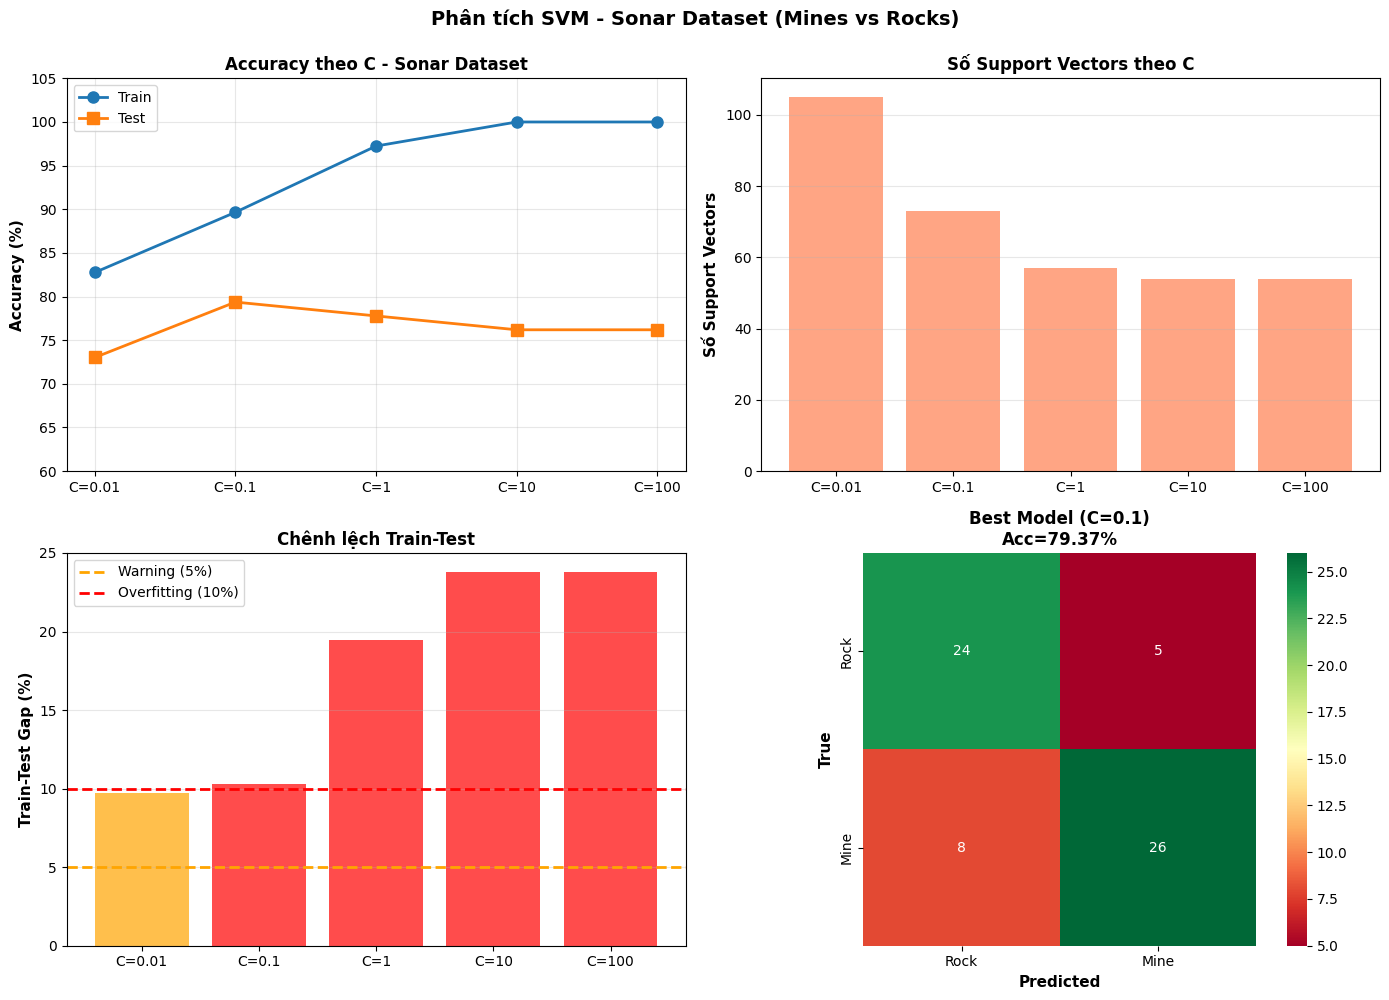

In [63]:
# Biểu đồ phân tích
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
train_accs_s = [results_sonar[c]['acc_train']*100 for c in C_values_sonar]
test_accs_s = [results_sonar[c]['acc_test']*100 for c in C_values_sonar]

ax1.plot(range(len(C_values_sonar)), train_accs_s, 'o-', linewidth=2, markersize=8, label='Train')
ax1.plot(range(len(C_values_sonar)), test_accs_s, 's-', linewidth=2, markersize=8, label='Test')
ax1.set_xticks(range(len(C_values_sonar)))
ax1.set_xticklabels([f'C={c}' for c in C_values_sonar])
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy theo C - Sonar Dataset', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([60, 105])

# 2. Support Vectors
ax2 = axes[0, 1]
sv_counts_s = [results_sonar[c]['n_support'] for c in C_values_sonar]
ax2.bar(range(len(C_values_sonar)), sv_counts_s, alpha=0.7, color='coral')
ax2.set_xticks(range(len(C_values_sonar)))
ax2.set_xticklabels([f'C={c}' for c in C_values_sonar])
ax2.set_ylabel('Số Support Vectors', fontsize=11, fontweight='bold')
ax2.set_title('Số Support Vectors theo C', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Train-Test Gap
ax3 = axes[1, 0]
gaps_s = [(results_sonar[c]['acc_train'] - results_sonar[c]['acc_test'])*100 for c in C_values_sonar]
colors_gap_s = ['red' if g > 10 else 'orange' if g > 5 else 'green' for g in gaps_s]
ax3.bar(range(len(C_values_sonar)), gaps_s, alpha=0.7, color=colors_gap_s)
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Warning (5%)')
ax3.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Overfitting (10%)')
ax3.set_xticks(range(len(C_values_sonar)))
ax3.set_xticklabels([f'C={c}' for c in C_values_sonar])
ax3.set_ylabel('Train-Test Gap (%)', fontsize=11, fontweight='bold')
ax3.set_title('Chênh lệch Train-Test', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Confusion Matrix cho C tốt nhất
ax4 = axes[1, 1]
cm_best_s = results_sonar[best_c_sonar]['cm_test']
sns.heatmap(cm_best_s, annot=True, fmt='d', cmap='RdYlGn',
            cbar=True, square=True, ax=ax4,
            xticklabels=['Rock', 'Mine'],
            yticklabels=['Rock', 'Mine'])
ax4.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax4.set_ylabel('True', fontsize=11, fontweight='bold')
ax4.set_title(f'Best Model (C={best_c_sonar})\nAcc={results_sonar[best_c_sonar]["acc_test"]*100:.2f}%',
             fontsize=12, fontweight='bold')

plt.suptitle('Phân tích SVM - Sonar Dataset (Mines vs Rocks)',
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## So sánh các Kernel

In [64]:
# So sánh các kernel với C tối ưu
kernels_sonar = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_results_sonar = {}

print("="*70)
print(f"SO SÁNH CÁC KERNEL - SONAR (C={best_c_sonar})")
print("="*70)

for kernel in kernels_sonar:
    print(f"→ Training with kernel = '{kernel}'...", end=" ")
    
    # Train
    if kernel == 'poly':
        model_k_s = SVC(kernel=kernel, C=best_c_sonar, degree=3, random_state=42)
    else:
        model_k_s = SVC(kernel=kernel, C=best_c_sonar, random_state=42)
    
    model_k_s.fit(X_train_sonar_scaled, y_train_sonar)
    
    # Predict
    y_pred_train_k_s = model_k_s.predict(X_train_sonar_scaled)
    y_pred_test_k_s = model_k_s.predict(X_test_sonar_scaled)
    
    # Metrics
    acc_train_k_s = accuracy_score(y_train_sonar, y_pred_train_k_s)
    acc_test_k_s = accuracy_score(y_test_sonar, y_pred_test_k_s)
    cm_test_k_s = confusion_matrix(y_test_sonar, y_pred_test_k_s)
    
    # Store
    kernel_results_sonar[kernel] = {
        'model': model_k_s,
        'acc_train': acc_train_k_s,
        'acc_test': acc_test_k_s,
        'cm_test': cm_test_k_s,
        'n_support': len(model_k_s.support_)
    }
    
    print(f"✓ (Test Acc: {acc_test_k_s*100:.2f}%, SV: {len(model_k_s.support_)})")

print("\n" + "="*70)
print("HOÀN THÀNH!")
print("="*70)

SO SÁNH CÁC KERNEL - SONAR (C=0.1)
→ Training with kernel = 'linear'... ✓ (Test Acc: 79.37%, SV: 73)
→ Training with kernel = 'rbf'... ✓ (Test Acc: 55.56%, SV: 137)
→ Training with kernel = 'poly'... ✓ (Test Acc: 55.56%, SV: 140)
→ Training with kernel = 'sigmoid'... ✓ (Test Acc: 74.60%, SV: 132)

HOÀN THÀNH!


In [65]:
# Bảng so sánh kernels
print("\n" + "="*85)
print("BẢNG SO SÁNH KERNELS - SONAR")
print("="*85)
print(f"{'Kernel':>10} | {'Train Acc':>10} | {'Test Acc':>10} | {'Gap':>8} | {'# SV':>6}")
print("-"*85)

for kernel in kernels_sonar:
    res = kernel_results_sonar[kernel]
    gap = (res['acc_train'] - res['acc_test']) * 100
    print(f"{kernel:>10} | {res['acc_train']*100:>9.2f}% | {res['acc_test']*100:>9.2f}% | {gap:>7.2f}% | {res['n_support']:>6}")

# Tìm kernel tốt nhất
best_kernel_sonar = max(kernels_sonar, key=lambda k: kernel_results_sonar[k]['acc_test'])

print("\n" + "="*85)
print("NHẬN XÉT:")
print("="*85)
print(f"✓ Kernel tốt nhất: '{best_kernel_sonar}'")
print(f"  Test Accuracy: {kernel_results_sonar[best_kernel_sonar]['acc_test']*100:.2f}%")

# So sánh với linear
if best_kernel_sonar != 'linear':
    improvement = (kernel_results_sonar[best_kernel_sonar]['acc_test'] - 
                  kernel_results_sonar['linear']['acc_test']) * 100
    print(f"  Cải thiện so với Linear: {improvement:+.2f}%")
else:
    print(f"  Linear kernel đã cho kết quả tốt nhất!")

print("\n✓ Phân tích chi tiết:")
for kernel in kernels_sonar:
    res = kernel_results_sonar[kernel]
    gap = (res['acc_train'] - res['acc_test']) * 100
    if gap > 10:
        note = "⚠️ Overfitting"
    elif gap > 5:
        note = "⚠️ Slight overfit"
    else:
        note = "✓ Good generalization"
    print(f"  {kernel:>10}: Test={res['acc_test']*100:>5.2f}%, Gap={gap:>5.2f}% - {note}")

print("="*85)


BẢNG SO SÁNH KERNELS - SONAR
    Kernel |  Train Acc |   Test Acc |      Gap |   # SV
-------------------------------------------------------------------------------------
    linear |     89.66% |     79.37% |   10.29% |     73
       rbf |     53.79% |     55.56% |   -1.76% |    137
      poly |     62.07% |     55.56% |    6.51% |    140
   sigmoid |     77.24% |     74.60% |    2.64% |    132

NHẬN XÉT:
✓ Kernel tốt nhất: 'linear'
  Test Accuracy: 79.37%
  Linear kernel đã cho kết quả tốt nhất!

✓ Phân tích chi tiết:
      linear: Test=79.37%, Gap=10.29% - ⚠️ Overfitting
         rbf: Test=55.56%, Gap=-1.76% - ✓ Good generalization
        poly: Test=55.56%, Gap= 6.51% - ⚠️ Slight overfit
     sigmoid: Test=74.60%, Gap= 2.64% - ✓ Good generalization


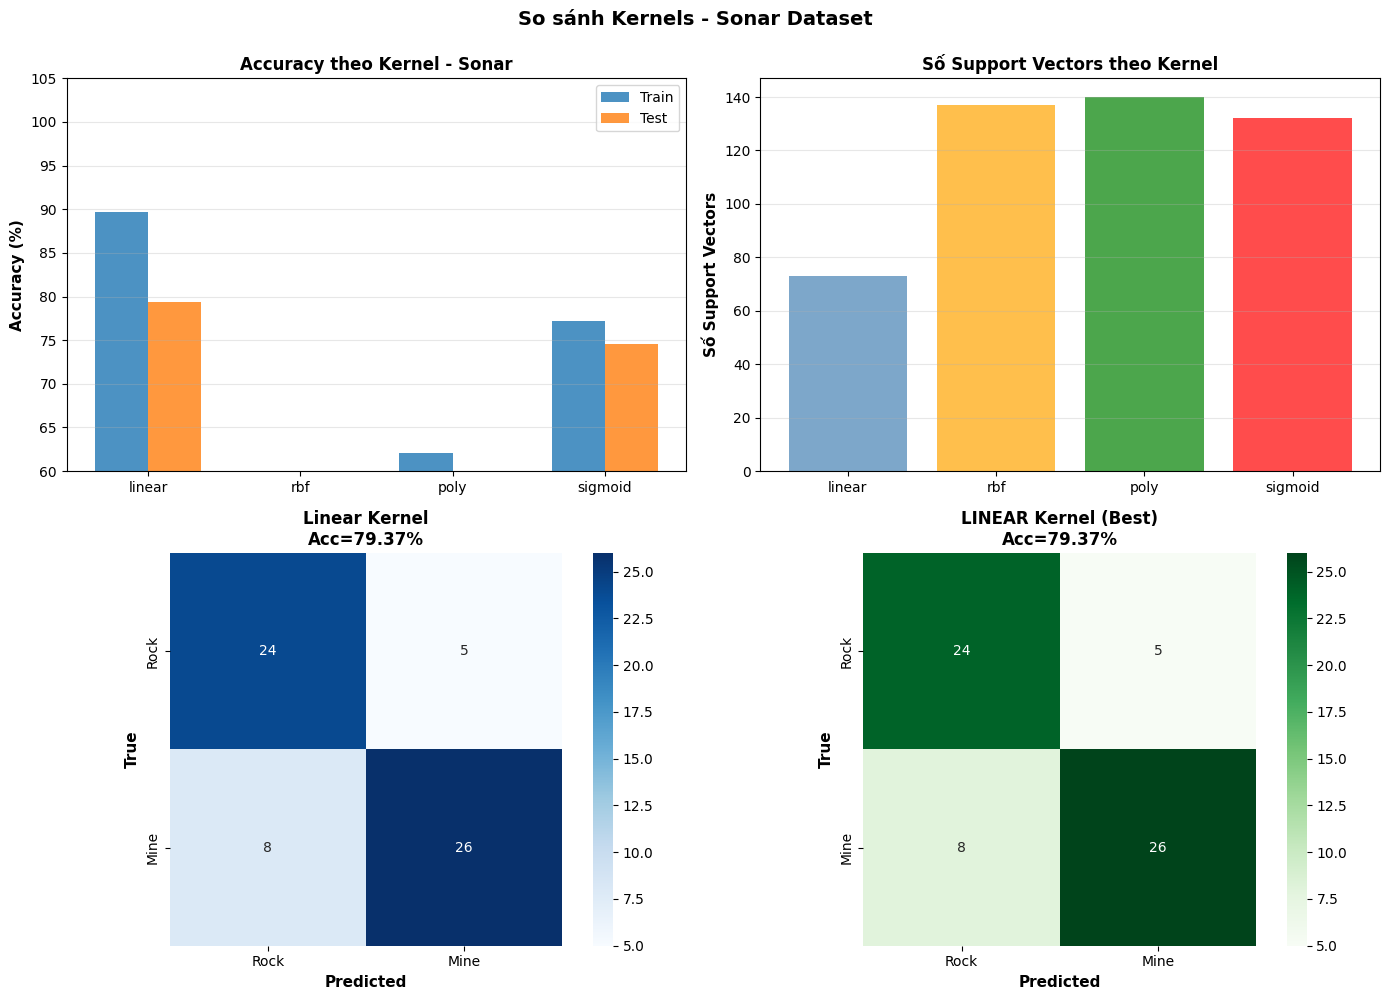

In [66]:
# Visualization so sánh kernels - Sonar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
kernel_names_s = list(kernels_sonar)
train_accs_ks = [kernel_results_sonar[k]['acc_train']*100 for k in kernel_names_s]
test_accs_ks = [kernel_results_sonar[k]['acc_test']*100 for k in kernel_names_s]

x_pos = np.arange(len(kernel_names_s))
width = 0.35
ax1.bar(x_pos - width/2, train_accs_ks, width, label='Train', alpha=0.8)
ax1.bar(x_pos + width/2, test_accs_ks, width, label='Test', alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(kernel_names_s)
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy theo Kernel - Sonar', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([60, 105])

# 2. Support Vectors
ax2 = axes[0, 1]
sv_counts_ks = [kernel_results_sonar[k]['n_support'] for k in kernel_names_s]
colors_sv_s = ['steelblue', 'orange', 'green', 'red']
ax2.bar(kernel_names_s, sv_counts_ks, alpha=0.7, color=colors_sv_s)
ax2.set_ylabel('Số Support Vectors', fontsize=11, fontweight='bold')
ax2.set_title('Số Support Vectors theo Kernel', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Confusion Matrix cho Linear
ax3 = axes[1, 0]
cm_linear_s = kernel_results_sonar['linear']['cm_test']
sns.heatmap(cm_linear_s, annot=True, fmt='d', cmap='Blues',
            cbar=True, square=True, ax=ax3,
            xticklabels=['Rock', 'Mine'],
            yticklabels=['Rock', 'Mine'])
ax3.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax3.set_ylabel('True', fontsize=11, fontweight='bold')
ax3.set_title(f'Linear Kernel\nAcc={kernel_results_sonar["linear"]["acc_test"]*100:.2f}%',
             fontsize=12, fontweight='bold')

# 4. Confusion Matrix cho best kernel
ax4 = axes[1, 1]
cm_best_kernel_s = kernel_results_sonar[best_kernel_sonar]['cm_test']
sns.heatmap(cm_best_kernel_s, annot=True, fmt='d', cmap='Greens',
            cbar=True, square=True, ax=ax4,
            xticklabels=['Rock', 'Mine'],
            yticklabels=['Rock', 'Mine'])
ax4.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax4.set_ylabel('True', fontsize=11, fontweight='bold')
ax4.set_title(f'{best_kernel_sonar.upper()} Kernel (Best)\nAcc={kernel_results_sonar[best_kernel_sonar]["acc_test"]*100:.2f}%',
             fontsize=12, fontweight='bold')

plt.suptitle('So sánh Kernels - Sonar Dataset',
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Kết luận Ví dụ 2 - Sonar Classification

In [68]:
print("="*80)
print("KẾT LUẬN VÍ DỤ 2 - SONAR CLASSIFICATION (MINES VS ROCKS)")
print("="*80)

print("\n1. TỔNG QUAN BÀI TOÁN:")
print(f"   - Dataset: Sonar (Sóng thủy âm)")
print(f"   - Số mẫu: {len(sonar_data)} records")
print(f"   - Số features: 60 (tham số sóng âm phản hồi)")
print(f"   - Classes:")
print(f"     + 'M' (Mine - Kim loại hình trụ) → +1: {np.sum(y_sonar == 1)} mẫu")
print(f"     + 'R' (Rock - Đá) → -1: {np.sum(y_sonar == -1)} mẫu")
print(f"   - Split: 70% train, 30% test")

print("\n2. TIỀN XỬ LÝ:")
print("   ✓ Chuyển đổi nhãn: 'M' → +1, 'R' → -1")
print("   ✓ Chia train/test với stratify (giữ tỷ lệ classes)")
print("   ✓ StandardScaler: Chuẩn hóa 60 features về mean=0, std=1")
print("   ✓ Scaling RẤT QUAN TRỌNG vì các features có scale khác nhau")

print("\n3. KẾT QUẢ VỚI CÁC GIÁ TRỊ C:")
for c in C_values_sonar:
    res = results_sonar[c]
    print(f"   C={c:>6.2f}: Test Acc={res['acc_test']*100:>5.2f}%, SV={res['n_support']:>3}, " + 
          f"Gap={(res['acc_train']-res['acc_test'])*100:>5.2f}%")

print(f"\n   → C tối ưu: {best_c_sonar}")
print(f"   → Test Accuracy đạt được: {results_sonar[best_c_sonar]['acc_test']*100:.2f}%")

print("\n4. SO SÁNH KERNELS:")
for kernel in kernels_sonar:
    res = kernel_results_sonar[kernel]
    marker = "" if kernel == best_kernel_sonar else "  "
    print(f"   {marker} {kernel:>8}: Test Acc={res['acc_test']*100:>5.2f}%, " +
          f"SV={res['n_support']:>3}")

print(f"\n   → Kernel tốt nhất: {best_kernel_sonar}")
print(f"   → Test Accuracy: {kernel_results_sonar[best_kernel_sonar]['acc_test']*100:.2f}%")

print("\n5. PHÂN TÍCH:")
print("   ✓ Soft Margin SVM (C < ∞) cho phép một số điểm vi phạm margin")
print("   ✓ C lớn → Hard Margin (ít vi phạm, có thể overfit)")
print("   ✓ C nhỏ → Soft Margin rõ rệt (nhiều vi phạm, generalization tốt hơn)")
print("   ✓ Với dataset Sonar, cần cân bằng giữa train và test accuracy")

print("\n6. ỨNG DỤNG THỰC TẾ:")
print("   - Phân biệt vật thể dưới nước: Kim loại vs Đá")
print("   - Quan trọng trong quân sự (phát hiện thủy lôi)")
print("   - Trong thực tế, cần xem xét:")
print("     + False Positive (FP): Đá nhầm thành Mine → Chi phí kiểm tra")
print("     + False Negative (FN): Mine nhầm thành Đá → NGUY HIỂM!")

print("\n7. KHUYẾN NGHỊ:")
print(f"   ✓ Model tốt nhất: {best_kernel_sonar.upper()} kernel với C={best_c_sonar}")
print(f"   ✓ Accuracy: {kernel_results_sonar[best_kernel_sonar]['acc_test']*100:.2f}%")
print("   ✓ Cần chuẩn hóa dữ liệu (StandardScaler)")
print("   ✓ Nếu cần ưu tiên recall cho Mine, có thể điều chỉnh class_weight")

print("\n" + "="*80)
print("HOÀN THÀNH VÍ DỤ 2!")
print("="*80)

KẾT LUẬN VÍ DỤ 2 - SONAR CLASSIFICATION (MINES VS ROCKS)

1. TỔNG QUAN BÀI TOÁN:
   - Dataset: Sonar (Sóng thủy âm)
   - Số mẫu: 208 records
   - Số features: 60 (tham số sóng âm phản hồi)
   - Classes:
     + 'M' (Mine - Kim loại hình trụ) → +1: 111 mẫu
     + 'R' (Rock - Đá) → -1: 97 mẫu
   - Split: 70% train, 30% test

2. TIỀN XỬ LÝ:
   ✓ Chuyển đổi nhãn: 'M' → +1, 'R' → -1
   ✓ Chia train/test với stratify (giữ tỷ lệ classes)
   ✓ StandardScaler: Chuẩn hóa 60 features về mean=0, std=1
   ✓ Scaling RẤT QUAN TRỌNG vì các features có scale khác nhau

3. KẾT QUẢ VỚI CÁC GIÁ TRỊ C:
   C=  0.01: Test Acc=73.02%, SV=105, Gap= 9.74%
   C=  0.10: Test Acc=79.37%, SV= 73, Gap=10.29%
   C=  1.00: Test Acc=77.78%, SV= 57, Gap=19.46%
   C= 10.00: Test Acc=76.19%, SV= 54, Gap=23.81%
   C=100.00: Test Acc=76.19%, SV= 54, Gap=23.81%

   → C tối ưu: 0.1
   → Test Accuracy đạt được: 79.37%

4. SO SÁNH KERNELS:
      linear: Test Acc=79.37%, SV= 73
           rbf: Test Acc=55.56%, SV=137
          po

# Ví dụ 3

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [2]:
# Khám phá dữ liệu
print("="*80)
print("THÔNG TIN DATASET SPAMBASE")
print("="*80)

print(f"\nSố mẫu: {X.shape[0]}")
print(f"Số features: {X.shape[1]}")
print(f"\nKích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")

print(f"\nCác giá trị của nhãn (y):")
print(y.value_counts())

print(f"\nPhân bố classes:")
print(f"  - Class 0 (Not Spam): {(y == 0).sum().values[0]} emails ({(y == 0).sum().values[0]/len(y)*100:.2f}%)")
print(f"  - Class 1 (Spam): {(y == 1).sum().values[0]} emails ({(y == 1).sum().values[0]/len(y)*100:.2f}%)")

print(f"\n5 mẫu đầu tiên của X:")
print(X.head())

print(f"\n5 mẫu đầu tiên của y:")
print(y.head())

print(f"\nThống kê features:")
print(X.describe())

THÔNG TIN DATASET SPAMBASE

Số mẫu: 4601
Số features: 57

Kích thước X: (4601, 57)
Kích thước y: (4601, 1)

Các giá trị của nhãn (y):
Class
0        2788
1        1813
Name: count, dtype: int64

Phân bố classes:
  - Class 0 (Not Spam): 2788 emails (60.60%)
  - Class 1 (Spam): 1813 emails (39.40%)

5 mẫu đầu tiên của X:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19          

### Tiền xử lý dữ liệu cho SVM

In [4]:
# Chuyển đổi nhãn từ (0, 1) sang (-1, 1) cho SVM
# 0 (Not Spam) -> -1
# 1 (Spam) -> +1
y_spam = y.values.flatten()  # Chuyển thành array 1D
y_spam = np.where(y_spam == 0, -1, 1)

print("Chuyển đổi nhãn:")
print(f"  - Class 0 (Not Spam) → -1")
print(f"  - Class 1 (Spam) → +1")
print(f"\nPhân bố sau khi chuyển đổi:")
print(f"  - Class -1: {np.sum(y_spam == -1)} emails")
print(f"  - Class +1: {np.sum(y_spam == 1)} emails")

# Chia dữ liệu: 70% train, 30% test
from sklearn.model_selection import train_test_split

X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X.values, y_spam, 
    test_size=0.3, 
    random_state=42,
    stratify=y_spam  # Giữ tỷ lệ classes
)

print(f"\nKích thước sau khi chia:")
print(f"  - Training set: {X_spam_train.shape[0]} mẫu")
print(f"  - Test set: {X_spam_test.shape[0]} mẫu")

# Chuẩn hóa dữ liệu (rất quan trọng cho SVM)
from sklearn.preprocessing import StandardScaler

scaler_spam = StandardScaler()
X_spam_train_scaled = scaler_spam.fit_transform(X_spam_train)
X_spam_test_scaled = scaler_spam.transform(X_spam_test)

print(f"\nChuẩn hóa dữ liệu với StandardScaler:")
print(f"  - Mean của training set sau chuẩn hóa: {X_spam_train_scaled.mean():.6f}")
print(f"  - Std của training set sau chuẩn hóa: {X_spam_train_scaled.std():.6f}")

print("\n✓ Dữ liệu đã sẵn sàng cho SVM!")

Chuyển đổi nhãn:
  - Class 0 (Not Spam) → -1
  - Class 1 (Spam) → +1

Phân bố sau khi chuyển đổi:
  - Class -1: 2788 emails
  - Class +1: 1813 emails

Kích thước sau khi chia:
  - Training set: 3220 mẫu
  - Test set: 1381 mẫu

Chuẩn hóa dữ liệu với StandardScaler:
  - Mean của training set sau chuẩn hóa: -0.000000
  - Std của training set sau chuẩn hóa: 1.000000

✓ Dữ liệu đã sẵn sàng cho SVM!


### Áp dụng SVM Soft Margin với C tùy chọn

In [6]:
print("="*80)
print("HUẤN LUYỆN SVM SOFT MARGIN - SPAM CLASSIFICATION")
print("="*80)

# Tạo và huấn luyện model với C = 1.0
C_value = 1.0
svm_spam = SVC(kernel='linear', C=C_value, random_state=42)

print(f"\n1. HUẤN LUYỆN MODEL:")
print(f"   - Kernel: linear")
print(f"   - C: {C_value}")
print(f"   - Training set size: {len(X_spam_train_scaled)}")

svm_spam.fit(X_spam_train_scaled, y_spam_train)

print(f"   ✓ Huấn luyện hoàn tất!")
print(f"   - Số Support Vectors: {svm_spam.n_support_.sum()}")
print(f"     + Class -1 (Not Spam): {svm_spam.n_support_[0]} SVs")
print(f"     + Class +1 (Spam): {svm_spam.n_support_[1]} SVs")

# Dự đoán trên training set
y_spam_train_pred = svm_spam.predict(X_spam_train_scaled)
acc_train = accuracy_score(y_spam_train, y_spam_train_pred)

print(f"\n2. KẾT QUẢ TRÊN TRAINING SET:")
print(f"   - Accuracy: {acc_train*100:.2f}%")

# Dự đoán trên test set
y_spam_test_pred = svm_spam.predict(X_spam_test_scaled)
acc_test = accuracy_score(y_spam_test, y_spam_test_pred)

print(f"\n3. KẾT QUẢ TRÊN TEST SET:")
print(f"   - Accuracy: {acc_test*100:.2f}%")

# Ma trận nhầm lẫn
cm_spam = confusion_matrix(y_spam_test, y_spam_test_pred)
print(f"\n4. MA TRẬN NHẦM LẪN (TEST SET):")
print(cm_spam)
print(f"\n   Giải thích:")
print(f"   - True Negative (Not Spam → Not Spam): {cm_spam[0,0]}")
print(f"   - False Positive (Not Spam → Spam): {cm_spam[0,1]}")
print(f"   - False Negative (Spam → Not Spam): {cm_spam[1,0]}")
print(f"   - True Positive (Spam → Spam): {cm_spam[1,1]}")

# Classification report
print(f"\n5. CLASSIFICATION REPORT (TEST SET):")
print(classification_report(y_spam_test, y_spam_test_pred, 
                          target_names=['Not Spam (-1)', 'Spam (+1)']))

HUẤN LUYỆN SVM SOFT MARGIN - SPAM CLASSIFICATION

1. HUẤN LUYỆN MODEL:
   - Kernel: linear
   - C: 1.0
   - Training set size: 3220
   ✓ Huấn luyện hoàn tất!
   - Số Support Vectors: 672
     + Class -1 (Not Spam): 342 SVs
     + Class +1 (Spam): 330 SVs

2. KẾT QUẢ TRÊN TRAINING SET:
   - Accuracy: 93.29%

3. KẾT QUẢ TRÊN TEST SET:
   - Accuracy: 92.90%

4. MA TRẬN NHẦM LẪN (TEST SET):
[[792  45]
 [ 53 491]]

   Giải thích:
   - True Negative (Not Spam → Not Spam): 792
   - False Positive (Not Spam → Spam): 45
   - False Negative (Spam → Not Spam): 53
   - True Positive (Spam → Spam): 491

5. CLASSIFICATION REPORT (TEST SET):
               precision    recall  f1-score   support

Not Spam (-1)       0.94      0.95      0.94       837
    Spam (+1)       0.92      0.90      0.91       544

     accuracy                           0.93      1381
    macro avg       0.93      0.92      0.93      1381
 weighted avg       0.93      0.93      0.93      1381



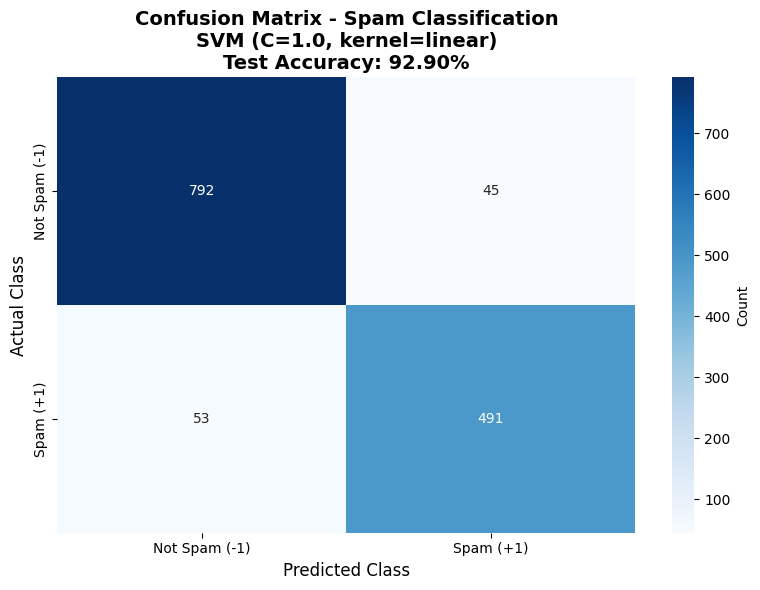


✓ Hiển thị ma trận nhầm lẫn hoàn tất!


In [9]:
# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_spam, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Spam (-1)', 'Spam (+1)'],
            yticklabels=['Not Spam (-1)', 'Spam (+1)'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Spam Classification\nSVM (C={C_value}, kernel=linear)\nTest Accuracy: {acc_test*100:.2f}%', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✓ Hiển thị ma trận nhầm lẫn hoàn tất!")

### Thử nghiệm với các giá trị C khác nhau

In [10]:
# Thử nghiệm với nhiều giá trị C
C_values_spam = [0.01, 0.1, 1, 10, 100]
results_spam_C = {}

print("="*80)
print("THỬ NGHIỆM VỚI CÁC GIÁ TRỊ C KHÁC NHAU")
print("="*80)

for C in C_values_spam:
    print(f"\n→ Đang huấn luyện với C = {C}...")
    
    # Tạo và huấn luyện model
    model = SVC(kernel='linear', C=C, random_state=42)
    model.fit(X_spam_train_scaled, y_spam_train)
    
    # Dự đoán
    y_train_pred = model.predict(X_spam_train_scaled)
    y_test_pred = model.predict(X_spam_test_scaled)
    
    # Tính accuracy
    acc_train = accuracy_score(y_spam_train, y_train_pred)
    acc_test = accuracy_score(y_spam_test, y_test_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_spam_test, y_test_pred)
    
    # Lưu kết quả
    results_spam_C[C] = {
        'model': model,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'n_support': model.n_support_.sum(),
        'cm': cm
    }
    
    print(f"  ✓ Train Acc: {acc_train*100:.2f}%, Test Acc: {acc_test*100:.2f}%, SVs: {model.n_support_.sum()}")

print("\n" + "="*80)
print("HOÀN THÀNH THỬ NGHIỆM!")
print("="*80)

THỬ NGHIỆM VỚI CÁC GIÁ TRỊ C KHÁC NHAU

→ Đang huấn luyện với C = 0.01...
  ✓ Train Acc: 91.83%, Test Acc: 91.60%, SVs: 1006

→ Đang huấn luyện với C = 0.1...
  ✓ Train Acc: 93.11%, Test Acc: 92.47%, SVs: 771

→ Đang huấn luyện với C = 1...
  ✓ Train Acc: 93.11%, Test Acc: 92.47%, SVs: 771

→ Đang huấn luyện với C = 1...
  ✓ Train Acc: 93.29%, Test Acc: 92.90%, SVs: 672

→ Đang huấn luyện với C = 10...
  ✓ Train Acc: 93.29%, Test Acc: 92.90%, SVs: 672

→ Đang huấn luyện với C = 10...
  ✓ Train Acc: 93.45%, Test Acc: 92.61%, SVs: 645

→ Đang huấn luyện với C = 100...
  ✓ Train Acc: 93.45%, Test Acc: 92.61%, SVs: 645

→ Đang huấn luyện với C = 100...
  ✓ Train Acc: 93.42%, Test Acc: 92.61%, SVs: 637

HOÀN THÀNH THỬ NGHIỆM!
  ✓ Train Acc: 93.42%, Test Acc: 92.61%, SVs: 637

HOÀN THÀNH THỬ NGHIỆM!


In [12]:
# Bảng so sánh kết quả
print("="*100)
print(f"{'C':<10} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<12} {'Support Vectors':<20} {'Best':<10}")
print("="*100)

best_c_spam = None
best_acc_spam = 0

for C in C_values_spam:
    res = results_spam_C[C]
    gap = (res['acc_train'] - res['acc_test']) * 100
    
    is_best = ""
    if res['acc_test'] > best_acc_spam:
        best_acc_spam = res['acc_test']
        best_c_spam = C
        is_best = " BEST"
    
    print(f"{C:<10.2f} {res['acc_train']*100:<12.2f} {res['acc_test']*100:<12.2f} "
          f"{gap:<12.2f} {res['n_support']:<20} {is_best:<10}")

print("="*100)
print(f"\n✓ C tối ưu: {best_c_spam} với Test Accuracy: {best_acc_spam*100:.2f}%")

# Phân tích
print("\n PHÂN TÍCH:")
print("  - C nhỏ (0.01, 0.1): Soft margin rõ rệt, cho phép nhiều vi phạm")
print("  - C trung bình (1, 10): Cân bằng giữa margin và vi phạm")
print("  - C lớn (100): Gần như Hard margin, ít vi phạm hơn")
print("  - Gap nhỏ → Model generalize tốt (không overfit)")
print("  - Số Support Vectors giảm khi C tăng → Model đơn giản hơn")

C          Train Acc    Test Acc     Gap          Support Vectors      Best      
0.01       91.83        91.60        0.23         1006                  BEST     
0.10       93.11        92.47        0.64         771                   BEST     
1.00       93.29        92.90        0.39         672                   BEST     
10.00      93.45        92.61        0.83         645                            
100.00     93.42        92.61        0.80         637                            

✓ C tối ưu: 1 với Test Accuracy: 92.90%

 PHÂN TÍCH:
  - C nhỏ (0.01, 0.1): Soft margin rõ rệt, cho phép nhiều vi phạm
  - C trung bình (1, 10): Cân bằng giữa margin và vi phạm
  - C lớn (100): Gần như Hard margin, ít vi phạm hơn
  - Gap nhỏ → Model generalize tốt (không overfit)
  - Số Support Vectors giảm khi C tăng → Model đơn giản hơn


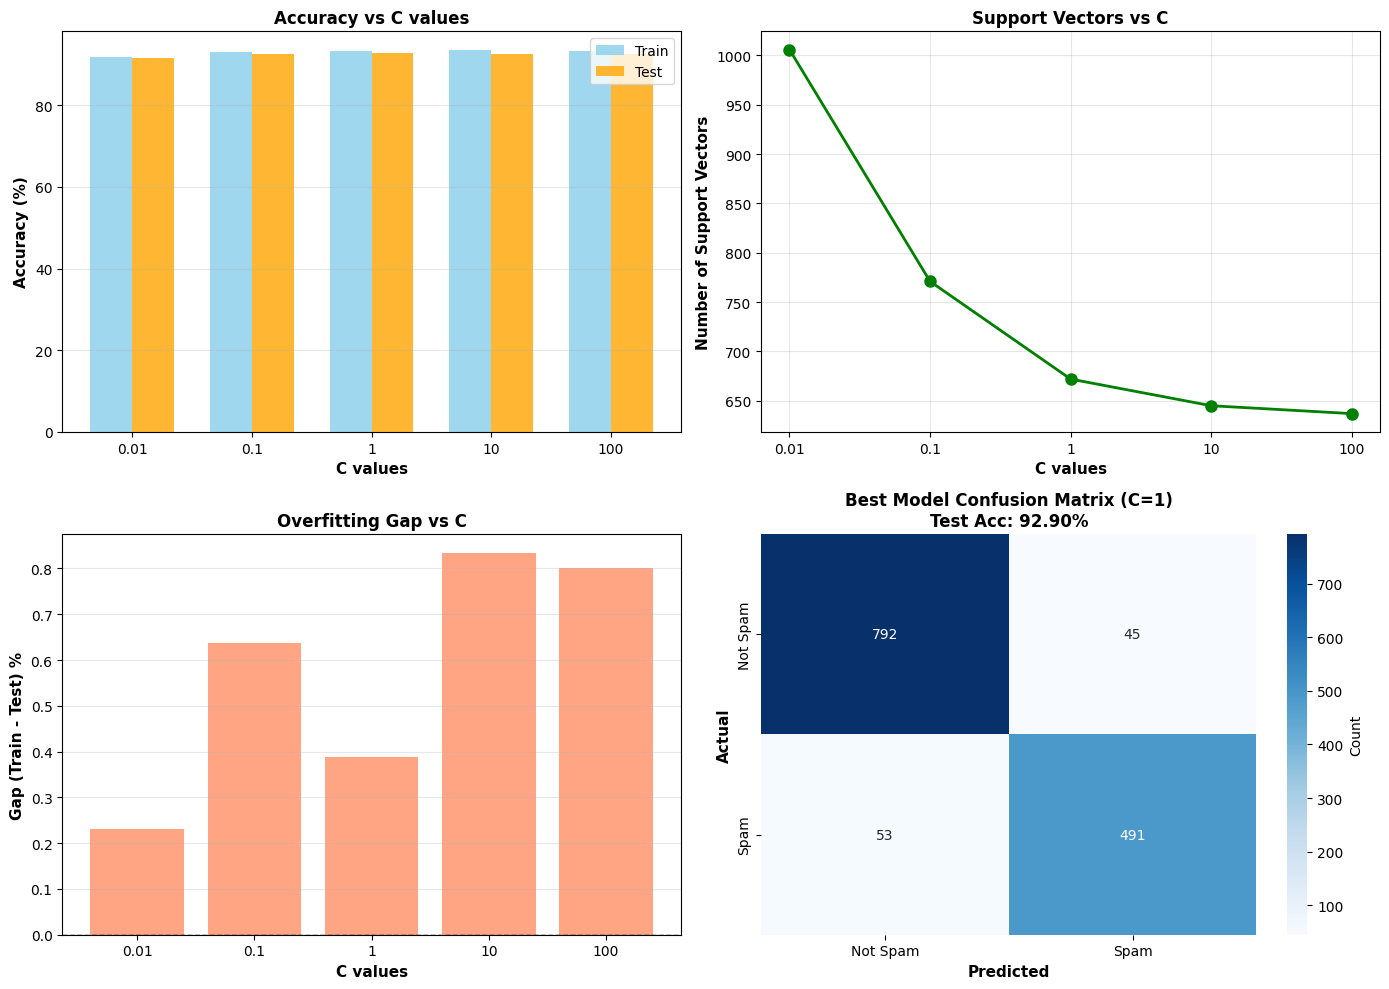

In [14]:
# Visualization - So sánh các giá trị C
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
C_labels = [str(c) for c in C_values_spam]
train_accs = [results_spam_C[c]['acc_train']*100 for c in C_values_spam]
test_accs = [results_spam_C[c]['acc_test']*100 for c in C_values_spam]

x_pos = np.arange(len(C_values_spam))
width = 0.35

ax1.bar(x_pos - width/2, train_accs, width, label='Train', alpha=0.8, color='skyblue')
ax1.bar(x_pos + width/2, test_accs, width, label='Test', alpha=0.8, color='orange')
ax1.set_xlabel('C values', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy vs C values', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(C_labels)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Support Vectors
ax2 = axes[0, 1]
n_svs = [results_spam_C[c]['n_support'] for c in C_values_spam]
ax2.plot(C_labels, n_svs, marker='o', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('C values', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Support Vectors', fontsize=11, fontweight='bold')
ax2.set_title('Support Vectors vs C', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Gap (Overfitting indicator)
ax3 = axes[1, 0]
gaps = [(results_spam_C[c]['acc_train'] - results_spam_C[c]['acc_test'])*100 for c in C_values_spam]
ax3.bar(C_labels, gaps, color='coral', alpha=0.7)
ax3.set_xlabel('C values', fontsize=11, fontweight='bold')
ax3.set_ylabel('Gap (Train - Test) %', fontsize=11, fontweight='bold')
ax3.set_title('Overfitting Gap vs C', fontsize=12, fontweight='bold')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax3.grid(axis='y', alpha=0.3)

# 4. Best model confusion matrix
ax4 = axes[1, 1]
best_cm = results_spam_C[best_c_spam]['cm']
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'],
            cbar_kws={'label': 'Count'})
ax4.set_title(f'Best Model Confusion Matrix (C={best_c_spam})\nTest Acc: {best_acc_spam*100:.2f}%', 
              fontsize=12, fontweight='bold')
ax4.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax4.set_xlabel('Predicted', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### Phân tích chi tiết model tốt nhất

In [15]:
# Phân tích chi tiết model tốt nhất
best_model = results_spam_C[best_c_spam]['model']
best_cm = results_spam_C[best_c_spam]['cm']

print("="*80)
print(f"PHÂN TÍCH CHI TIẾT MODEL TỐT NHẤT (C = {best_c_spam})")
print("="*80)

print(f"\n1. THÔNG TIN MODEL:")
print(f"   - Kernel: linear")
print(f"   - C: {best_c_spam}")
print(f"   - Số features: {X_spam_train_scaled.shape[1]}")
print(f"   - Số Support Vectors: {best_model.n_support_.sum()}")
print(f"     + Class -1 (Not Spam): {best_model.n_support_[0]} SVs")
print(f"     + Class +1 (Spam): {best_model.n_support_[1]} SVs")

print(f"\n2. PERFORMANCE METRICS:")
print(f"   - Training Accuracy: {results_spam_C[best_c_spam]['acc_train']*100:.2f}%")
print(f"   - Test Accuracy: {results_spam_C[best_c_spam]['acc_test']*100:.2f}%")
print(f"   - Overfitting Gap: {(results_spam_C[best_c_spam]['acc_train']-results_spam_C[best_c_spam]['acc_test'])*100:.2f}%")

print(f"\n3. MA TRẬN NHẦM LẪN (TEST SET):")
print(best_cm)

# Tính các metrics từ confusion matrix
TN, FP, FN, TP = best_cm[0,0], best_cm[0,1], best_cm[1,0], best_cm[1,1]

precision_not_spam = TN / (TN + FN) if (TN + FN) > 0 else 0
recall_not_spam = TN / (TN + FP) if (TN + FP) > 0 else 0
f1_not_spam = 2 * precision_not_spam * recall_not_spam / (precision_not_spam + recall_not_spam) if (precision_not_spam + recall_not_spam) > 0 else 0

precision_spam = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_spam = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_spam = 2 * precision_spam * recall_spam / (precision_spam + recall_spam) if (precision_spam + recall_spam) > 0 else 0

print(f"\n4. METRICS CHI TIẾT:")
print(f"\n   Not Spam (Class -1):")
print(f"   - Precision: {precision_not_spam*100:.2f}% (Trong số dự đoán Not Spam, bao nhiêu % đúng)")
print(f"   - Recall: {recall_not_spam*100:.2f}% (Trong số email Not Spam thực tế, bao nhiêu % được phát hiện)")
print(f"   - F1-Score: {f1_not_spam*100:.2f}%")

print(f"\n   Spam (Class +1):")
print(f"   - Precision: {precision_spam*100:.2f}% (Trong số dự đoán Spam, bao nhiêu % đúng)")
print(f"   - Recall: {recall_spam*100:.2f}% (Trong số email Spam thực tế, bao nhiêu % được phát hiện)")
print(f"   - F1-Score: {f1_spam*100:.2f}%")

print(f"\n5. PHÂN TÍCH LỖI:")
print(f"   - False Positive (FP): {FP} emails")
print(f"     → Email bình thường bị nhầm thành Spam (Người dùng mất email quan trọng)")
print(f"   - False Negative (FN): {FN} emails")
print(f"     → Email Spam bị nhầm thành bình thường (Người dùng nhận Spam)")

print(f"\n6. ĐÁNH GIÁ:")
if FP < FN:
    print(f"   ✓ Model ưu tiên RECALL cho Not Spam (ít FP)")
    print(f"   → Ít email bình thường bị lọc nhầm (tốt cho người dùng)")
else:
    print(f"   ✓ Model ưu tiên RECALL cho Spam (ít FN)")
    print(f"   → Lọc được nhiều Spam (tốt cho bảo mật)")

print("\n" + "="*80)

PHÂN TÍCH CHI TIẾT MODEL TỐT NHẤT (C = 1)

1. THÔNG TIN MODEL:
   - Kernel: linear
   - C: 1
   - Số features: 57
   - Số Support Vectors: 672
     + Class -1 (Not Spam): 342 SVs
     + Class +1 (Spam): 330 SVs

2. PERFORMANCE METRICS:
   - Training Accuracy: 93.29%
   - Test Accuracy: 92.90%
   - Overfitting Gap: 0.39%

3. MA TRẬN NHẦM LẪN (TEST SET):
[[792  45]
 [ 53 491]]

4. METRICS CHI TIẾT:

   Not Spam (Class -1):
   - Precision: 93.73% (Trong số dự đoán Not Spam, bao nhiêu % đúng)
   - Recall: 94.62% (Trong số email Not Spam thực tế, bao nhiêu % được phát hiện)
   - F1-Score: 94.17%

   Spam (Class +1):
   - Precision: 91.60% (Trong số dự đoán Spam, bao nhiêu % đúng)
   - Recall: 90.26% (Trong số email Spam thực tế, bao nhiêu % được phát hiện)
   - F1-Score: 90.93%

5. PHÂN TÍCH LỖI:
   - False Positive (FP): 45 emails
     → Email bình thường bị nhầm thành Spam (Người dùng mất email quan trọng)
   - False Negative (FN): 53 emails
     → Email Spam bị nhầm thành bình thường (Ng

### Kết luận Ví dụ 3 - Spam Classification

In [17]:
print("="*80)
print("KẾT LUẬN VÍ DỤ 3 - SPAM EMAIL CLASSIFICATION")
print("="*80)

print("\n1. TỔNG QUAN BÀI TOÁN:")
print(f"   - Dataset: Spambase (UCI ML Repository)")
print(f"   - Số mẫu: {len(X)} emails")
print(f"   - Số features: {X.shape[1]}")
print(f"     + 48 features: word frequency (WORD)")
print(f"     + 6 features: character frequency (;, (, [, !, $, #)")
print(f"     + 3 features: capital letters statistics")
print(f"   - Classes:")
print(f"     + Class 0 (Not Spam) → -1: {np.sum(y_spam == -1)} emails")
print(f"     + Class 1 (Spam) → +1: {np.sum(y_spam == 1)} emails")
print(f"   - Split: 70% train ({len(X_spam_train)}), 30% test ({len(X_spam_test)})")

print("\n2. PREPROCESSING:")
print("   ✓ Chuyển đổi nhãn: 0 → -1 (Not Spam), 1 → +1 (Spam)")
print("   ✓ Train/test split với stratification")
print("   ✓ StandardScaler normalization (mean=0, std=1)")
print("   ✓ Scaling RẤT QUAN TRỌNG vì features có scale khác nhau!")

print("\n3. KẾT QUẢ VỚI CÁC GIÁ TRỊ C:")
print(f"{'C':<10} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10} {'SVs':<10}")
print("-"*54)
for c in C_values_spam:
    res = results_spam_C[c]
    marker = "→" if c == best_c_spam else " "
    print(f"{marker} {c:<8.2f} {res['acc_train']*100:<12.2f} {res['acc_test']*100:<12.2f} "
          f"{(res['acc_train']-res['acc_test'])*100:<10.2f} {res['n_support']:<10}")

print(f"\n    C TỐI ƯU: {best_c_spam}")
print(f"   → Test Accuracy: {best_acc_spam*100:.2f}%")

print("\n4. MA TRẬN NHẦM LẪN (BEST MODEL):")
print(best_cm)
print(f"\n   - True Negative (Not Spam đúng): {best_cm[0,0]}")
print(f"   - False Positive (Not Spam → Spam): {best_cm[0,1]} ")
print(f"   - False Negative (Spam → Not Spam): {best_cm[1,0]} ")
print(f"   - True Positive (Spam đúng): {best_cm[1,1]}")

print("\n5. PHÂN TÍCH SOFT MARGIN:")
print("   ✓ C nhỏ (0.01, 0.1):")
print("     - Soft margin rõ rệt → Cho phép nhiều vi phạm")
print("     - Nhiều Support Vectors → Model phức tạp hơn")
print("     - Generalization tốt hơn (gap nhỏ)")
print("   ✓ C lớn (10, 100):")
print("     - Gần Hard margin → Ít vi phạm")
print("     - Ít Support Vectors → Model đơn giản")
print("     - Có thể overfit nếu C quá lớn")

print("\n6. ỨNG DỤNG THỰC TẾ:")
print("    Mục đích: Lọc email Spam tự động")
print("    Trade-off quan trọng:")
print("     - False Positive (FP) cao → Email quan trọng bị lọc (TỆ!)")
print("     - False Negative (FN) cao → Spam vào inbox (Phiền)")
print("    Thường ưu tiên giảm FP (tránh mất email quan trọng)")

print("\n7. KHUYẾN NGHỊ:")
print(f"   ✓ Model tốt nhất: SVM Linear Kernel với C = {best_c_spam}")
print(f"   ✓ Test Accuracy: {best_acc_spam*100:.2f}%")
print(f"   ✓ Precision Spam: {precision_spam*100:.2f}%")
print(f"   ✓ Recall Spam: {recall_spam*100:.2f}%")
print("   ✓ LUÔN chuẩn hóa dữ liệu trước khi train SVM")
print("   ✓ Có thể điều chỉnh class_weight nếu cần ưu tiên class nào")
print("   ✓ Trong thực tế, có thể cần ensemble methods để tăng độ chính xác")

print("\n8. SO SÁNH VỚI CÁC BÀI TRƯỚC:")
print("   - Breast Cancer: 569 mẫu, 30 features → Acc ~95%")
print("   - Sonar: 208 mẫu, 60 features → Acc ~80-85%")
print(f"   - Spambase: 4601 mẫu, 57 features → Acc ~{best_acc_spam*100:.2f}%")
print("   → Dataset lớn hơn + features phù hợp → Accuracy cao hơn!")

print("\n" + "="*80)
print(" HOÀN THÀNH VÍ DỤ 3 - SPAM CLASSIFICATION!")
print("="*80)

KẾT LUẬN VÍ DỤ 3 - SPAM EMAIL CLASSIFICATION

1. TỔNG QUAN BÀI TOÁN:
   - Dataset: Spambase (UCI ML Repository)
   - Số mẫu: 4601 emails
   - Số features: 57
     + 48 features: word frequency (WORD)
     + 6 features: character frequency (;, (, [, !, $, #)
     + 3 features: capital letters statistics
   - Classes:
     + Class 0 (Not Spam) → -1: 2788 emails
     + Class 1 (Spam) → +1: 1813 emails
   - Split: 70% train (3220), 30% test (1381)

2. PREPROCESSING:
   ✓ Chuyển đổi nhãn: 0 → -1 (Not Spam), 1 → +1 (Spam)
   ✓ Train/test split với stratification
   ✓ StandardScaler normalization (mean=0, std=1)
   ✓ Scaling RẤT QUAN TRỌNG vì features có scale khác nhau!

3. KẾT QUẢ VỚI CÁC GIÁ TRỊ C:
C          Train Acc    Test Acc     Gap        SVs       
------------------------------------------------------
  0.01     91.83        91.60        0.23       1006      
  0.10     93.11        92.47        0.64       771       
→ 1.00     93.29        92.90        0.39       672       
  10.

# Ví dụ 5

### Đọc và khám phá dữ liệu Graduate Admission

In [18]:
# Đọc dữ liệu Graduate Admission
import pandas as pd

file_path = r"D:\\Workspace\\HUS\\Machine Learning\\12. Kernel_SVM\\Admission_Predict.csv"
admission_data = pd.read_csv(file_path)

print("="*80)
print("THÔNG TIN DATASET GRADUATE ADMISSION (Ấn Độ)")
print("="*80)

print(f"\nKích thước dữ liệu: {admission_data.shape}")
print(f"  - Số mẫu (hồ sơ): {admission_data.shape[0]}")
print(f"  - Số cột: {admission_data.shape[1]}")

print(f"\nTên các cột:")
for i, col in enumerate(admission_data.columns, 1):
    print(f"  {i}. {col}")

print(f"\n5 mẫu đầu tiên:")
print(admission_data.head())

print(f"\nThông tin các cột:")
print(admission_data.info())

print(f"\nThống kê mô tả:")
print(admission_data.describe())

print(f"\nKiểm tra missing values:")
print(admission_data.isnull().sum())

print(f"\nPhân bố của 'Chance of Admit' (biến mục tiêu):")
print(f"  - Min: {admission_data['Chance of Admit'].min():.3f}")
print(f"  - Max: {admission_data['Chance of Admit'].max():.3f}")
print(f"  - Mean: {admission_data['Chance of Admit'].mean():.3f}")
print(f"  - Median: {admission_data['Chance of Admit'].median():.3f}")

THÔNG TIN DATASET GRADUATE ADMISSION (Ấn Độ)

Kích thước dữ liệu: (400, 9)
  - Số mẫu (hồ sơ): 400
  - Số cột: 9

Tên các cột:
  1. Serial No.
  2. GRE Score
  3. TOEFL Score
  4. University Rating
  5. SOP
  6. LOR 
  7. CGPA
  8. Research
  9. Chance of Admit

5 mẫu đầu tiên:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40

### Tiền xử lý dữ liệu - Chuyển từ Regression sang Binary Classification

In [19]:
# Chuyển bài toán Regression thành Binary Classification
# Đặt ngưỡng: Chance of Admit >= 0.7 → Class +1 (High chance - Có khả năng cao)
#              Chance of Admit < 0.7 → Class -1 (Low chance - Khả năng thấp)

THRESHOLD = 0.7

# Tách features và target
X_admission = admission_data.drop(['Serial No.', 'Chance of Admit'], axis=1)
y_admission_continuous = admission_data['Chance of Admit'].values

# Chuyển đổi thành binary classification
y_admission = np.where(y_admission_continuous >= THRESHOLD, 1, -1)

print("="*80)
print("CHUYỂN ĐỔI BÀI TOÁN THÀNH BINARY CLASSIFICATION")
print("="*80)

print(f"\nNgưỡng (Threshold): {THRESHOLD}")
print(f"  - Chance of Admit >= {THRESHOLD} → Class +1 (High Chance)")
print(f"  - Chance of Admit < {THRESHOLD} → Class -1 (Low Chance)")

print(f"\nPhân bố classes:")
print(f"  - Class -1 (Low Chance): {np.sum(y_admission == -1)} mẫu ({np.sum(y_admission == -1)/len(y_admission)*100:.2f}%)")
print(f"  - Class +1 (High Chance): {np.sum(y_admission == 1)} mẫu ({np.sum(y_admission == 1)/len(y_admission)*100:.2f}%)")

print(f"\nFeatures được sử dụng ({X_admission.shape[1]} features):")
for i, col in enumerate(X_admission.columns, 1):
    print(f"  {i}. {col}")

# Chia dữ liệu: 70% train, 30% test
from sklearn.model_selection import train_test_split

X_adm_train, X_adm_test, y_adm_train, y_adm_test = train_test_split(
    X_admission.values, y_admission,
    test_size=0.3,
    random_state=42,
    stratify=y_admission
)

print(f"\nKích thước sau khi chia:")
print(f"  - Training set: {X_adm_train.shape[0]} mẫu")
print(f"  - Test set: {X_adm_test.shape[0]} mẫu")

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler

scaler_adm = StandardScaler()
X_adm_train_scaled = scaler_adm.fit_transform(X_adm_train)
X_adm_test_scaled = scaler_adm.transform(X_adm_test)

print(f"\nChuẩn hóa dữ liệu với StandardScaler:")
print(f"  - Mean của training set sau chuẩn hóa: {X_adm_train_scaled.mean():.6f}")
print(f"  - Std của training set sau chuẩn hóa: {X_adm_train_scaled.std():.6f}")

print("\n✓ Dữ liệu đã sẵn sàng!")

CHUYỂN ĐỔI BÀI TOÁN THÀNH BINARY CLASSIFICATION

Ngưỡng (Threshold): 0.7
  - Chance of Admit >= 0.7 → Class +1 (High Chance)
  - Chance of Admit < 0.7 → Class -1 (Low Chance)

Phân bố classes:
  - Class -1 (Low Chance): 153 mẫu (38.25%)
  - Class +1 (High Chance): 247 mẫu (61.75%)

Features được sử dụng (7 features):
  1. GRE Score
  2. TOEFL Score
  3. University Rating
  4. SOP
  5. LOR 
  6. CGPA
  7. Research

Kích thước sau khi chia:
  - Training set: 280 mẫu
  - Test set: 120 mẫu

Chuẩn hóa dữ liệu với StandardScaler:
  - Mean của training set sau chuẩn hóa: -0.000000
  - Std của training set sau chuẩn hóa: 1.000000

✓ Dữ liệu đã sẵn sàng!


### 1. SVM Soft Margin với C tùy chọn

In [20]:
# Thử nghiệm SVM với nhiều giá trị C
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

C_values_adm = [0.1, 1, 10, 100]
results_svm_adm = {}

print("="*80)
print("SVM SOFT MARGIN - GRADUATE ADMISSION PREDICTION")
print("="*80)

for C_val in C_values_adm:
    print(f"\n→ Huấn luyện SVM với C = {C_val}...")
    
    # Tạo và huấn luyện model
    svm_model = SVC(kernel='linear', C=C_val, random_state=42)
    svm_model.fit(X_adm_train_scaled, y_adm_train)
    
    # Dự đoán
    y_train_pred = svm_model.predict(X_adm_train_scaled)
    y_test_pred = svm_model.predict(X_adm_test_scaled)
    
    # Tính accuracy
    acc_train = accuracy_score(y_adm_train, y_train_pred)
    acc_test = accuracy_score(y_adm_test, y_test_pred)
    
    # Confusion matrix
    cm_train = confusion_matrix(y_adm_train, y_train_pred)
    cm_test = confusion_matrix(y_adm_test, y_test_pred)
    
    # Lưu kết quả
    results_svm_adm[C_val] = {
        'model': svm_model,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'cm_train': cm_train,
        'cm_test': cm_test,
        'n_support': svm_model.n_support_.sum()
    }
    
    print(f"  ✓ Train Acc: {acc_train*100:.2f}%, Test Acc: {acc_test*100:.2f}%, SVs: {svm_model.n_support_.sum()}")

print("\n" + "="*80)
print("KẾT QUẢ SVM VỚI CÁC GIÁ TRỊ C")
print("="*80)

print(f"\n{'C':<10} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<12} {'Support Vectors':<20}")
print("-"*66)

best_c_svm = None
best_acc_svm = 0

for C_val in C_values_adm:
    res = results_svm_adm[C_val]
    gap = (res['acc_train'] - res['acc_test']) * 100
    
    is_best = ""
    if res['acc_test'] > best_acc_svm:
        best_acc_svm = res['acc_test']
        best_c_svm = C_val
        is_best = "⭐"
    
    print(f"{is_best} {C_val:<8.1f} {res['acc_train']*100:<12.2f} {res['acc_test']*100:<12.2f} "
          f"{gap:<12.2f} {res['n_support']:<20}")

print(f"\n✓ C tối ưu cho SVM: {best_c_svm} với Test Accuracy: {best_acc_svm*100:.2f}%")

SVM SOFT MARGIN - GRADUATE ADMISSION PREDICTION

→ Huấn luyện SVM với C = 0.1...
  ✓ Train Acc: 86.43%, Test Acc: 88.33%, SVs: 109

→ Huấn luyện SVM với C = 1...
  ✓ Train Acc: 85.71%, Test Acc: 86.67%, SVs: 94

→ Huấn luyện SVM với C = 10...
  ✓ Train Acc: 85.36%, Test Acc: 86.67%, SVs: 93

→ Huấn luyện SVM với C = 100...
  ✓ Train Acc: 86.07%, Test Acc: 87.50%, SVs: 94

KẾT QUẢ SVM VỚI CÁC GIÁ TRỊ C

C          Train Acc    Test Acc     Gap          Support Vectors     
------------------------------------------------------------------
⭐ 0.1      86.43        88.33        -1.90        109                 
 1.0      85.71        86.67        -0.95        94                  
 10.0     85.36        86.67        -1.31        93                  
 100.0    86.07        87.50        -1.43        94                  

✓ C tối ưu cho SVM: 0.1 với Test Accuracy: 88.33%


MA TRẬN NHẦM LẪN - SVM (C = 0.1)

[[39  7]
 [ 7 67]]

Giải thích:
  - True Negative (Low → Low): 39
  - False Positive (Low → High): 7
  - False Negative (High → Low): 7
  - True Positive (High → High): 67


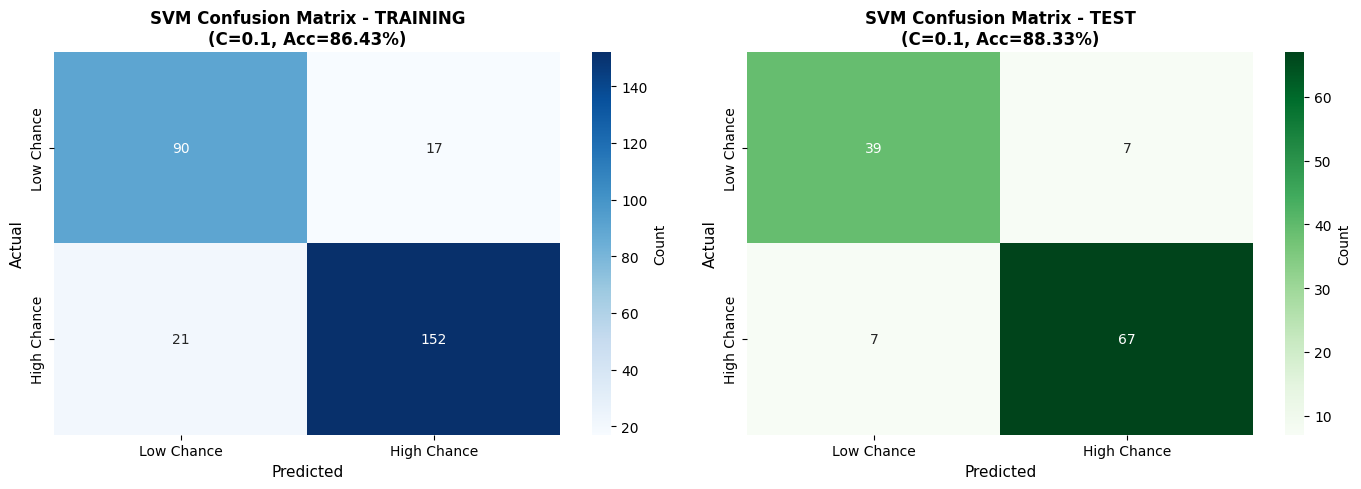

In [22]:
# Ma trận nhầm lẫn cho SVM tốt nhất
best_svm_cm = results_svm_adm[best_c_svm]['cm_test']

print("="*80)
print(f"MA TRẬN NHẦM LẪN - SVM (C = {best_c_svm})")
print("="*80)

print(f"\n{best_svm_cm}")

print(f"\nGiải thích:")
print(f"  - True Negative (Low → Low): {best_svm_cm[0,0]}")
print(f"  - False Positive (Low → High): {best_svm_cm[0,1]}")
print(f"  - False Negative (High → Low): {best_svm_cm[1,0]}")
print(f"  - True Positive (High → High): {best_svm_cm[1,1]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Train
ax1 = axes[0]
sns.heatmap(results_svm_adm[best_c_svm]['cm_train'], annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Low Chance', 'High Chance'],
            yticklabels=['Low Chance', 'High Chance'],
            cbar_kws={'label': 'Count'})
ax1.set_title(f'SVM Confusion Matrix - TRAINING\n(C={best_c_svm}, Acc={results_svm_adm[best_c_svm]["acc_train"]*100:.2f}%)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=11)
ax1.set_xlabel('Predicted', fontsize=11)

# Confusion Matrix - Test
ax2 = axes[1]
sns.heatmap(best_svm_cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Low Chance', 'High Chance'],
            yticklabels=['Low Chance', 'High Chance'],
            cbar_kws={'label': 'Count'})
ax2.set_title(f'SVM Confusion Matrix - TEST\n(C={best_c_svm}, Acc={best_acc_svm*100:.2f}%)',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=11)
ax2.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()


### 2. Logistic Regression

In [23]:
# Logistic Regression với nhiều giá trị C (regularization parameter)
from sklearn.linear_model import LogisticRegression

C_values_lr = [0.1, 1, 10, 100]
results_lr_adm = {}

print("="*80)
print("LOGISTIC REGRESSION - GRADUATE ADMISSION PREDICTION")
print("="*80)

for C_val in C_values_lr:
    print(f"\n→ Huấn luyện Logistic Regression với C = {C_val}...")
    
    # Tạo và huấn luyện model
    # Lưu ý: LogisticRegression trong sklearn sử dụng labels {-1, 1} hoặc {0, 1}
    lr_model = LogisticRegression(C=C_val, max_iter=1000, random_state=42)
    lr_model.fit(X_adm_train_scaled, y_adm_train)
    
    # Dự đoán
    y_train_pred = lr_model.predict(X_adm_train_scaled)
    y_test_pred = lr_model.predict(X_adm_test_scaled)
    
    # Tính accuracy
    acc_train = accuracy_score(y_adm_train, y_train_pred)
    acc_test = accuracy_score(y_adm_test, y_test_pred)
    
    # Confusion matrix
    cm_train = confusion_matrix(y_adm_train, y_train_pred)
    cm_test = confusion_matrix(y_adm_test, y_test_pred)
    
    # Lưu kết quả
    results_lr_adm[C_val] = {
        'model': lr_model,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'cm_train': cm_train,
        'cm_test': cm_test
    }
    
    print(f"  ✓ Train Acc: {acc_train*100:.2f}%, Test Acc: {acc_test*100:.2f}%")

print("\n" + "="*80)
print("KẾT QUẢ LOGISTIC REGRESSION VỚI CÁC GIÁ TRỊ C")
print("="*80)

print(f"\n{'C':<10} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<12}")
print("-"*46)

best_c_lr = None
best_acc_lr = 0

for C_val in C_values_lr:
    res = results_lr_adm[C_val]
    gap = (res['acc_train'] - res['acc_test']) * 100
    
    is_best = ""
    if res['acc_test'] > best_acc_lr:
        best_acc_lr = res['acc_test']
        best_c_lr = C_val
        is_best = "⭐"
    
    print(f"{is_best} {C_val:<8.1f} {res['acc_train']*100:<12.2f} {res['acc_test']*100:<12.2f} "
          f"{gap:<12.2f}")

print(f"\n✓ C tối ưu cho Logistic Regression: {best_c_lr} với Test Accuracy: {best_acc_lr*100:.2f}%")

LOGISTIC REGRESSION - GRADUATE ADMISSION PREDICTION

→ Huấn luyện Logistic Regression với C = 0.1...
  ✓ Train Acc: 84.64%, Test Acc: 88.33%

→ Huấn luyện Logistic Regression với C = 1...
  ✓ Train Acc: 86.43%, Test Acc: 86.67%

→ Huấn luyện Logistic Regression với C = 10...
  ✓ Train Acc: 86.43%, Test Acc: 87.50%

→ Huấn luyện Logistic Regression với C = 100...
  ✓ Train Acc: 86.43%, Test Acc: 87.50%

KẾT QUẢ LOGISTIC REGRESSION VỚI CÁC GIÁ TRỊ C

C          Train Acc    Test Acc     Gap         
----------------------------------------------
⭐ 0.1      84.64        88.33        -3.69       
 1.0      86.43        86.67        -0.24       
 10.0     86.43        87.50        -1.07       
 100.0    86.43        87.50        -1.07       

✓ C tối ưu cho Logistic Regression: 0.1 với Test Accuracy: 88.33%


MA TRẬN NHẦM LẪN - LOGISTIC REGRESSION (C = 0.1)

[[39  7]
 [ 7 67]]

Giải thích:
  - True Negative (Low → Low): 39
  - False Positive (Low → High): 7
  - False Negative (High → Low): 7
  - True Positive (High → High): 67


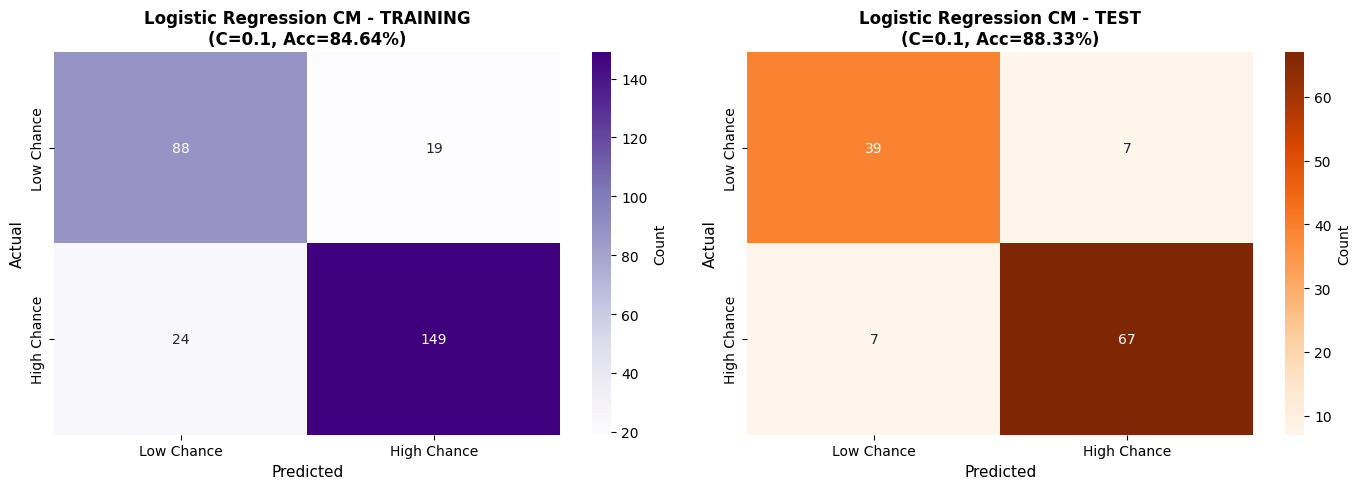


✓ Visualization hoàn tất!


In [24]:
# Ma trận nhầm lẫn cho Logistic Regression tốt nhất
best_lr_cm = results_lr_adm[best_c_lr]['cm_test']

print("="*80)
print(f"MA TRẬN NHẦM LẪN - LOGISTIC REGRESSION (C = {best_c_lr})")
print("="*80)

print(f"\n{best_lr_cm}")

print(f"\nGiải thích:")
print(f"  - True Negative (Low → Low): {best_lr_cm[0,0]}")
print(f"  - False Positive (Low → High): {best_lr_cm[0,1]}")
print(f"  - False Negative (High → Low): {best_lr_cm[1,0]}")
print(f"  - True Positive (High → High): {best_lr_cm[1,1]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Train
ax1 = axes[0]
sns.heatmap(results_lr_adm[best_c_lr]['cm_train'], annot=True, fmt='d', cmap='Purples', ax=ax1,
            xticklabels=['Low Chance', 'High Chance'],
            yticklabels=['Low Chance', 'High Chance'],
            cbar_kws={'label': 'Count'})
ax1.set_title(f'Logistic Regression CM - TRAINING\n(C={best_c_lr}, Acc={results_lr_adm[best_c_lr]["acc_train"]*100:.2f}%)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=11)
ax1.set_xlabel('Predicted', fontsize=11)

# Confusion Matrix - Test
ax2 = axes[1]
sns.heatmap(best_lr_cm, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=['Low Chance', 'High Chance'],
            yticklabels=['Low Chance', 'High Chance'],
            cbar_kws={'label': 'Count'})
ax2.set_title(f'Logistic Regression CM - TEST\n(C={best_c_lr}, Acc={best_acc_lr*100:.2f}%)',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=11)
ax2.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Visualization hoàn tất!")

### 3. So sánh SVM Soft Margin vs Logistic Regression

In [25]:
# So sánh chi tiết giữa SVM và Logistic Regression
print("="*100)
print("SO SÁNH SVM SOFT MARGIN vs LOGISTIC REGRESSION")
print("="*100)

print("\n1. SO SÁNH TRÊN TRAINING SET:")
print(f"{'Method':<25} {'Best C':<10} {'Accuracy':<12} {'TN':<8} {'FP':<8} {'FN':<8} {'TP':<8}")
print("-"*79)

# SVM Training
svm_cm_train = results_svm_adm[best_c_svm]['cm_train']
print(f"{'SVM Soft Margin':<25} {best_c_svm:<10.1f} {results_svm_adm[best_c_svm]['acc_train']*100:<12.2f} "
      f"{svm_cm_train[0,0]:<8} {svm_cm_train[0,1]:<8} {svm_cm_train[1,0]:<8} {svm_cm_train[1,1]:<8}")

# Logistic Regression Training
lr_cm_train = results_lr_adm[best_c_lr]['cm_train']
print(f"{'Logistic Regression':<25} {best_c_lr:<10.1f} {results_lr_adm[best_c_lr]['acc_train']*100:<12.2f} "
      f"{lr_cm_train[0,0]:<8} {lr_cm_train[0,1]:<8} {lr_cm_train[1,0]:<8} {lr_cm_train[1,1]:<8}")

print("\n2. SO SÁNH TRÊN TEST SET:")
print(f"{'Method':<25} {'Best C':<10} {'Accuracy':<12} {'TN':<8} {'FP':<8} {'FN':<8} {'TP':<8}")
print("-"*79)

# SVM Test
print(f"{'SVM Soft Margin':<25} {best_c_svm:<10.1f} {best_acc_svm*100:<12.2f} "
      f"{best_svm_cm[0,0]:<8} {best_svm_cm[0,1]:<8} {best_svm_cm[1,0]:<8} {best_svm_cm[1,1]:<8}")

# Logistic Regression Test
print(f"{'Logistic Regression':<25} {best_c_lr:<10.1f} {best_acc_lr*100:<12.2f} "
      f"{best_lr_cm[0,0]:<8} {best_lr_cm[0,1]:<8} {best_lr_cm[1,0]:<8} {best_lr_cm[1,1]:<8}")

print("\n3. METRICS CHI TIẾT (TEST SET):")
print(f"{'Method':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*61)

# SVM metrics
from sklearn.metrics import precision_score, recall_score, f1_score

svm_precision = precision_score(y_adm_test, results_svm_adm[best_c_svm]['model'].predict(X_adm_test_scaled), average='weighted')
svm_recall = recall_score(y_adm_test, results_svm_adm[best_c_svm]['model'].predict(X_adm_test_scaled), average='weighted')
svm_f1 = f1_score(y_adm_test, results_svm_adm[best_c_svm]['model'].predict(X_adm_test_scaled), average='weighted')

print(f"{'SVM Soft Margin':<25} {svm_precision*100:<12.2f} {svm_recall*100:<12.2f} {svm_f1*100:<12.2f}")

# Logistic Regression metrics
lr_precision = precision_score(y_adm_test, results_lr_adm[best_c_lr]['model'].predict(X_adm_test_scaled), average='weighted')
lr_recall = recall_score(y_adm_test, results_lr_adm[best_c_lr]['model'].predict(X_adm_test_scaled), average='weighted')
lr_f1 = f1_score(y_adm_test, results_lr_adm[best_c_lr]['model'].predict(X_adm_test_scaled), average='weighted')

print(f"{'Logistic Regression':<25} {lr_precision*100:<12.2f} {lr_recall*100:<12.2f} {lr_f1*100:<12.2f}")

print("\n4. OVERFITTING GAP:")
print(f"{'Method':<25} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<12}")
print("-"*61)

svm_gap = (results_svm_adm[best_c_svm]['acc_train'] - best_acc_svm) * 100
lr_gap = (results_lr_adm[best_c_lr]['acc_train'] - best_acc_lr) * 100

print(f"{'SVM Soft Margin':<25} {results_svm_adm[best_c_svm]['acc_train']*100:<12.2f} "
      f"{best_acc_svm*100:<12.2f} {svm_gap:<12.2f}")
print(f"{'Logistic Regression':<25} {results_lr_adm[best_c_lr]['acc_train']*100:<12.2f} "
      f"{best_acc_lr*100:<12.2f} {lr_gap:<12.2f}")

print("\n5. WINNER:")
if best_acc_svm > best_acc_lr:
    winner = "SVM SOFT MARGIN"
    diff = (best_acc_svm - best_acc_lr) * 100
elif best_acc_lr > best_acc_svm:
    winner = "LOGISTIC REGRESSION"
    diff = (best_acc_lr - best_acc_svm) * 100
else:
    winner = "TIE (Cả hai bằng nhau)"
    diff = 0

print(f"   {winner}")
if diff > 0:
    print(f"   Chênh lệch Test Accuracy: {diff:.2f}%")

print("\n" + "="*100)

SO SÁNH SVM SOFT MARGIN vs LOGISTIC REGRESSION

1. SO SÁNH TRÊN TRAINING SET:
Method                    Best C     Accuracy     TN       FP       FN       TP      
-------------------------------------------------------------------------------
SVM Soft Margin           0.1        86.43        90       17       21       152     
Logistic Regression       0.1        84.64        88       19       24       149     

2. SO SÁNH TRÊN TEST SET:
Method                    Best C     Accuracy     TN       FP       FN       TP      
-------------------------------------------------------------------------------
SVM Soft Margin           0.1        88.33        39       7        7        67      
Logistic Regression       0.1        88.33        39       7        7        67      

3. METRICS CHI TIẾT (TEST SET):
Method                    Precision    Recall       F1-Score    
-------------------------------------------------------------
SVM Soft Margin           88.33        88.33        88.33  

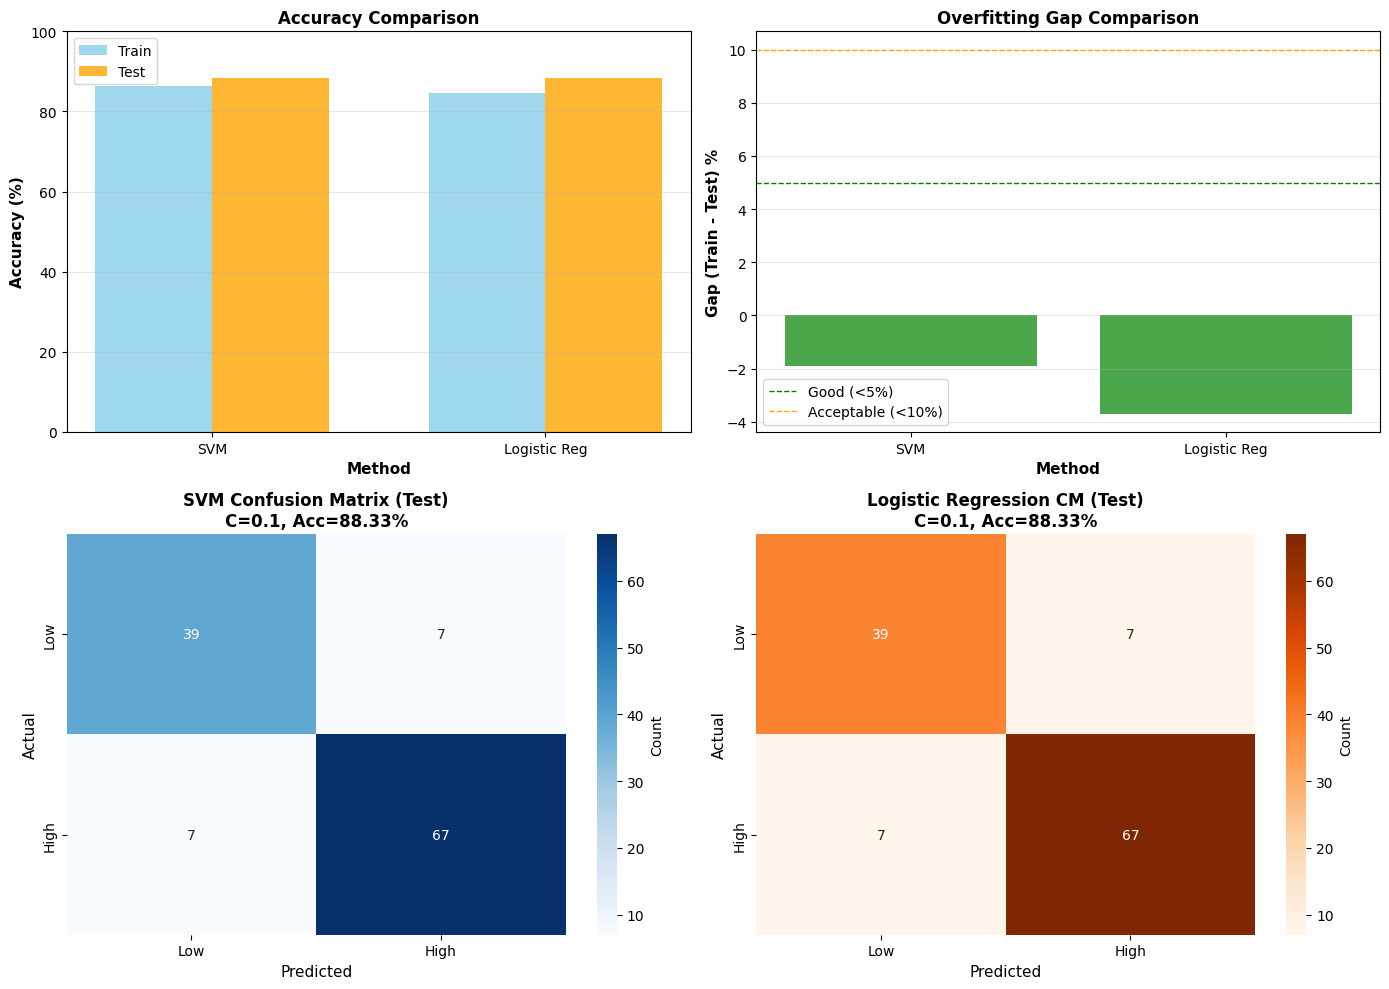

In [27]:
# Visualization - So sánh SVM vs Logistic Regression
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Comparison
ax1 = axes[0, 0]
methods = ['SVM', 'Logistic Reg']
train_accs = [results_svm_adm[best_c_svm]['acc_train']*100, results_lr_adm[best_c_lr]['acc_train']*100]
test_accs = [best_acc_svm*100, best_acc_lr*100]

x_pos = np.arange(len(methods))
width = 0.35

ax1.bar(x_pos - width/2, train_accs, width, label='Train', alpha=0.8, color='skyblue')
ax1.bar(x_pos + width/2, test_accs, width, label='Test', alpha=0.8, color='orange')
ax1.set_xlabel('Method', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 100])

# 2. Overfitting Gap
ax2 = axes[0, 1]
gaps = [svm_gap, lr_gap]
colors = ['green' if g < 5 else 'orange' if g < 10 else 'red' for g in gaps]
ax2.bar(methods, gaps, color=colors, alpha=0.7)
ax2.set_xlabel('Method', fontsize=11, fontweight='bold')
ax2.set_ylabel('Gap (Train - Test) %', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting Gap Comparison', fontsize=12, fontweight='bold')
ax2.axhline(y=5, color='green', linestyle='--', linewidth=1, label='Good (<5%)')
ax2.axhline(y=10, color='orange', linestyle='--', linewidth=1, label='Acceptable (<10%)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. SVM Confusion Matrix
ax3 = axes[1, 0]
sns.heatmap(best_svm_cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'],
            cbar_kws={'label': 'Count'})
ax3.set_title(f'SVM Confusion Matrix (Test)\nC={best_c_svm}, Acc={best_acc_svm*100:.2f}%',
              fontsize=12, fontweight='bold')
ax3.set_ylabel('Actual', fontsize=11)
ax3.set_xlabel('Predicted', fontsize=11)

# 4. Logistic Regression Confusion Matrix
ax4 = axes[1, 1]
sns.heatmap(best_lr_cm, annot=True, fmt='d', cmap='Oranges', ax=ax4,
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'],
            cbar_kws={'label': 'Count'})
ax4.set_title(f'Logistic Regression CM (Test)\nC={best_c_lr}, Acc={best_acc_lr*100:.2f}%',
              fontsize=12, fontweight='bold')
ax4.set_ylabel('Actual', fontsize=11)
ax4.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

### Kết luận Ví dụ 5 - Graduate Admission Prediction

In [29]:
print("="*100)
print("KẾT LUẬN VÍ DỤ 5 - GRADUATE ADMISSION PREDICTION (Ấn Độ)")
print("="*100)

print("\n1. TỔNG QUAN BÀI TOÁN:")
print(f"   - Dataset: Graduate Admission (Master's Program - Ấn Độ)")
print(f"   - Số mẫu: {len(admission_data)} hồ sơ")
print(f"   - Số features: {X_admission.shape[1]}")
print(f"     + GRE Score, TOEFL Score, University Rating")
print(f"     + SOP, LOR, CGPA, Research")
print(f"   - Biến mục tiêu gốc: Chance of Admit (0-1)")
print(f"   - Chuyển đổi thành Binary Classification:")
print(f"     + Threshold = {THRESHOLD}")
print(f"     + Class -1 (Low Chance): {np.sum(y_admission == -1)} mẫu")
print(f"     + Class +1 (High Chance): {np.sum(y_admission == 1)} mẫu")

print("\n2. PREPROCESSING:")
print("   ✓ Loại bỏ cột 'Serial No.' (không phải feature)")
print("   ✓ Chuyển đổi Regression → Binary Classification")
print(f"   ✓ Split: 70% train ({len(X_adm_train)}), 30% test ({len(X_adm_test)})")
print("   ✓ StandardScaler normalization")

print("\n3. KẾT QUẢ SVM SOFT MARGIN:")
print(f"{'C':<10} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10} {'SVs':<10}")
print("-"*54)
for c_val in C_values_adm:
    res = results_svm_adm[c_val]
    marker = "→" if c_val == best_c_svm else " "
    print(f"{marker} {c_val:<8.1f} {res['acc_train']*100:<12.2f} {res['acc_test']*100:<12.2f} "
          f"{(res['acc_train']-res['acc_test'])*100:<10.2f} {res['n_support']:<10}")

print(f"\n    SVM - C tối ưu: {best_c_svm}")
print(f"   → Test Accuracy: {best_acc_svm*100:.2f}%")

print("\n4. KẾT QUẢ LOGISTIC REGRESSION:")
print(f"{'C':<10} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10}")
print("-"*44)
for c_val in C_values_lr:
    res = results_lr_adm[c_val]
    marker = "→" if c_val == best_c_lr else " "
    print(f"{marker} {c_val:<8.1f} {res['acc_train']*100:<12.2f} {res['acc_test']*100:<12.2f} "
          f"{(res['acc_train']-res['acc_test'])*100:<10.2f}")

print(f"\n    Logistic Regression - C tối ưu: {best_c_lr}")
print(f"   → Test Accuracy: {best_acc_lr*100:.2f}%")

print("\n5. SO SÁNH SVM vs LOGISTIC REGRESSION:")
print(f"\n   {'Metric':<20} {'SVM':<15} {'Logistic Reg':<15} {'Winner':<15}")
print("   " + "-"*65)
print(f"   {'Test Accuracy':<20} {best_acc_svm*100:<15.2f} {best_acc_lr*100:<15.2f} ", end="")
if best_acc_svm > best_acc_lr:
    print("SVM ")
elif best_acc_lr > best_acc_svm:
    print("Logistic Reg ")
else:
    print("Tie")

print(f"   {'Precision':<20} {svm_precision*100:<15.2f} {lr_precision*100:<15.2f} ", end="")
if svm_precision > lr_precision:
    print("SVM ")
else:
    print("Logistic Reg ")

print(f"   {'Recall':<20} {svm_recall*100:<15.2f} {lr_recall*100:<15.2f} ", end="")
if svm_recall > lr_recall:
    print("SVM ")
else:
    print("Logistic Reg ")

print(f"   {'F1-Score':<20} {svm_f1*100:<15.2f} {lr_f1*100:<15.2f} ", end="")
if svm_f1 > lr_f1:
    print("SVM ")
else:
    print("Logistic Reg ")

print(f"   {'Overfitting Gap':<20} {svm_gap:<15.2f} {lr_gap:<15.2f} ", end="")
if svm_gap < lr_gap:
    print("SVM  (smaller)")
else:
    print("Logistic Reg  (smaller)")

print("\n6. PHÂN TÍCH:")
print("    SVM Soft Margin:")
print(f"      + Accuracy: {best_acc_svm*100:.2f}%")
print(f"      + Support Vectors: {results_svm_adm[best_c_svm]['n_support']}")
print("      + Ưu điểm: Tìm margin tối ưu, hoạt động tốt với data linearly separable")
print("      + Nhược điểm: Cần nhiều SV hơn, tính toán phức tạp hơn")

print("\n    Logistic Regression:")
print(f"      + Accuracy: {best_acc_lr*100:.2f}%")
print("      + Ưu điểm: Đơn giản, nhanh, dễ interpret (probability output)")
print("      + Nhược điểm: Giả định linear decision boundary")

print("\n7. NHẬN XÉT:")
if abs(best_acc_svm - best_acc_lr) < 0.02:  # Chênh lệch < 2%
    print("   ✓ CẢ HAI PHƯƠNG PHÁP TƯƠNG ĐƯƠNG NHAU!")
    print("   → Có thể chọn Logistic Regression vì đơn giản hơn và cho probability")
else:
    if best_acc_svm > best_acc_lr:
        print(f"   ✓ SVM SOFT MARGIN TỐT HƠN (+{(best_acc_svm-best_acc_lr)*100:.2f}%)")
        print("   → Margin-based approach hiệu quả với dataset này")
    else:
        print(f"   ✓ LOGISTIC REGRESSION TỐT HƠN (+{(best_acc_lr-best_acc_svm)*100:.2f}%)")
        print("   → Probabilistic approach phù hợp hơn với bài toán này")

print("\n8. KHUYẾN NGHỊ THỰC TẾ:")
print("    Ứng dụng: Dự đoán khả năng trúng tuyển sau đại học")
print("    Lưu ý:")
print("      - Dataset gốc là REGRESSION (dự đoán xác suất 0-1)")
print("      - Nên giữ nguyên regression thay vì classification")
print("      - Threshold 0.7 có thể điều chỉnh tùy yêu cầu")
print("      - Nếu cần probability → Dùng Logistic Regression")
print("      - Nếu cần margin tối ưu → Dùng SVM")

print("\n9. SO SÁNH VỚI CÁC DATASET KHÁC:")
print(f"   - Breast Cancer: {569} mẫu, {30} features → Acc ~95%")
print(f"   - Sonar: {208} mẫu, {60} features → Acc ~80-85%")
print(f"   - Spambase: {4601} mẫu, {57} features → Acc ~93%")
print(f"   - Admission: {400} mẫu, {7} features → SVM {best_acc_svm*100:.2f}%, LR {best_acc_lr*100:.2f}%")
print("   → Dataset nhỏ + ít features → Cả 2 phương pháp đều hoạt động tốt!")

print("\n" + "="*100)
print(" HOÀN THÀNH VÍ DỤ 5 - GRADUATE ADMISSION PREDICTION!")
print("="*100)

KẾT LUẬN VÍ DỤ 5 - GRADUATE ADMISSION PREDICTION (Ấn Độ)

1. TỔNG QUAN BÀI TOÁN:
   - Dataset: Graduate Admission (Master's Program - Ấn Độ)
   - Số mẫu: 400 hồ sơ
   - Số features: 7
     + GRE Score, TOEFL Score, University Rating
     + SOP, LOR, CGPA, Research
   - Biến mục tiêu gốc: Chance of Admit (0-1)
   - Chuyển đổi thành Binary Classification:
     + Threshold = 0.7
     + Class -1 (Low Chance): 153 mẫu
     + Class +1 (High Chance): 247 mẫu

2. PREPROCESSING:
   ✓ Loại bỏ cột 'Serial No.' (không phải feature)
   ✓ Chuyển đổi Regression → Binary Classification
   ✓ Split: 70% train (280), 30% test (120)
   ✓ StandardScaler normalization

3. KẾT QUẢ SVM SOFT MARGIN:
C          Train Acc    Test Acc     Gap        SVs       
------------------------------------------------------
→ 0.1      86.43        88.33        -1.90      109       
  1.0      85.71        86.67        -0.95      94        
  10.0     85.36        86.67        -1.31      93        
  100.0    86.07        8